# TFM SAF — Pipeline científico completo y reproducible · versión corregida 2.2
## Biomasa residual → MySQL → estadística → RDKit → xTB → ORCA/DFT → Machine Learning → NetworkX → optimización multiobjetivo

Este cuaderno está diseñado para ser **ejecutable de principio a fin** y, al mismo tiempo, servir como base directa para la sección de metodología/resultados del TFM. La fuente primaria de datos continúa siendo la base `saf_biomass`, cargada desde el Excel curado. Los cálculos derivados nunca sustituyen silenciosamente los datos experimentales.

### Principios científicos

1. **Trazabilidad.** Se conservan `biomass_id`, `molecule_id`, `reaction_id`, `source_id` y los identificadores de cálculo.
2. **Nada de datos inventados.** `NULL` sigue siendo ausencia de dato; una propiedad ausente no se convierte en cero.
3. **Unidades explícitas.** Solo se comparan valores cuando la unidad y la base experimental son compatibles o existe una conversión física inequívoca documentada.
4. **Validación sin fuga de información.** Los modelos de biomasa separan por `biomass_id`, de forma que mediciones de una misma biomasa no aparezcan simultáneamente en entrenamiento y validación.
5. **Química computacional jerárquica.** Conformeros RDKit → optimización GFN2-xTB → Hessiano/termoquímica xTB → optimización DFT `r2SCAN-3c` → frecuencias → refinamiento de energía `ωB97X-3c` (opcional/configurable).
6. **Control de mínimos.** Una geometría solo se considera mínimo vibracional si no presenta frecuencias imaginarias significativas.
7. **ML proporcional al tamaño muestral.** El cuaderno usa análisis avanzado cuando hay datos suficientes y marca expresamente como *exploratorio* cualquier modelo molecular de bajo `n`.
8. **Optimización multiobjetivo sin pesos ocultos.** Se utilizan dominancia de Pareto, rangos de Pareto y distancia de crowding en vez de imponer una puntuación arbitraria.

### Ejecución cuántica

Por petición del proyecto, el modo por defecto es **`full`**: procesa todas las moléculas que tengan SMILES, carga y multiplicidad válidos. Los cálculos se guardan en disco y son **reanundables**: si un resultado terminado ya existe, se reutiliza.

Si solo quieres probar una molécula antes del lote completo, antes de abrir Jupyter ejecuta en PowerShell:

```powershell
$env:TFM_QUANTUM_MODE="pilot"
python -m jupyter lab
```

Para desactivar temporalmente la ejecución cuántica:

```powershell
$env:TFM_QUANTUM_MODE="none"
```

### Referencias metodológicas principales

- Bannwarth, C.; Ehlert, S.; Grimme, S. **GFN2-xTB**. *J. Chem. Theory Comput.* (2019), DOI: 10.1021/acs.jctc.8b01176.
- Grimme, S.; Hansen, A.; Ehlert, S.; Mewes, J.-M. **r²SCAN-3c**. *J. Chem. Phys.* 154, 064103 (2021), DOI: 10.1063/5.0040021.
- Müller, M.; Hansen, A.; Grimme, S. **ωB97X-3c**. *J. Chem. Phys.* 158, 014103 (2023), DOI: 10.1063/5.0133026.
- Riniker, S.; Landrum, G. A. **ETKDG**. *J. Chem. Inf. Model.* 55, 2562–2574 (2015), DOI: 10.1021/acs.jcim.5b00654.
- Pedregosa, F. et al. **scikit-learn**. *JMLR* 12, 2825–2830 (2011).

> Nota metodológica: los orbitales Kohn–Sham (HOMO/LUMO), las energías xTB y los resultados DFT son descriptores computacionales dependientes del método. No se presentan como observables experimentales exactos.


> **Corrección 2.2.** Esta versión corrige compatibilidad de Matplotlib, captura de salida xTB en Windows, invalidación de caché cuántica, preflight ORCA, fallback serie si MPI no está disponible, hashes que incluyen geometría y etiquetado explícito del ML HHV como exploratorio cuando la base de medida no es homogénea.


In [1]:
# ============================================================
# FASE 0 — ENTORNO, CONFIGURACIÓN REPRODUCIBLE Y CONEXIÓN MYSQL
# ============================================================
from __future__ import annotations

from pathlib import Path
import os, sys, json, math, shutil, hashlib, platform, warnings, importlib.util
import subprocess, re, time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sqlalchemy import text

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

SEED = 20260916
RNG = np.random.default_rng(SEED)
HARTREE_TO_KJMOL = 2625.4996394799
HARTREE_TO_EV = 27.211386245988
AU_DIPOLE_TO_DEBYE = 2.541746473
QUANTUM_PIPELINE_VERSION = "2.2"

# Localizar raíz del proyecto subiendo directorios hasta encontrar src/ y database/schema.sql.
_here = Path.cwd().resolve()
PROJECT_ROOT = None
for p in [_here, *_here.parents]:
    if (p / "src").exists() and (p / "database" / "schema.sql").exists():
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    raise RuntimeError("No se encontró la raíz del proyecto: deben existir src/ y database/schema.sql.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_complete"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CONF_DIR = OUTPUT_DIR / "conformers"
QUANTUM_DIR = OUTPUT_DIR / "quantum"
XTB_DIR = QUANTUM_DIR / "xtb"
ORCA_DIR = QUANTUM_DIR / "orca"
REPORT_DIR = OUTPUT_DIR / "report"
for p in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, CONF_DIR, QUANTUM_DIR, XTB_DIR, ORCA_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

from src.db.connection import engine, test_connection

OPTIONAL = {
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "networkx": "networkx",
    "rdkit": "rdkit",
    "xgboost": "xgboost",
    "catboost": "catboost",
}
PACKAGE_STATUS = {m: importlib.util.find_spec(m) is not None for m in OPTIONAL}

# ---------------------------
# CONFIGURACIÓN MAESTRA
# ---------------------------
QUANTUM_MODE = os.environ.get("TFM_QUANTUM_MODE", "full").strip().lower()
if QUANTUM_MODE not in {"none", "pilot", "full"}:
    raise ValueError("TFM_QUANTUM_MODE debe ser: none, pilot o full")
QUANTUM_PILOT_N = 1
RESUME_QUANTUM = True

RUN_XTB = QUANTUM_MODE != "none"
RUN_XTB_HESSIAN = True
RUN_ORCA = QUANTUM_MODE != "none"
RUN_ORCA_FREQ = True
RUN_ORCA_REFINEMENT = True
WRITE_RDKIT_TO_MYSQL = True
WRITE_QUANTUM_TO_MYSQL = True

XTB_GFN = 2
XTB_OPT_LEVEL = "tight"
XTB_THREADS = max(1, min(4, (os.cpu_count() or 2) // 2))
ORCA_GEOM_METHOD = "R2SCAN-3C"
ORCA_REFINEMENT_METHOD = "wB97X-3c"

# ORCA paralelo en Windows requiere un runtime MPI compatible. Si no existe,
# el notebook cae automáticamente a ejecución serie en vez de fallar al arrancar.
def _find_mpi_runtime():
    candidates = [shutil.which("mpiexec"), shutil.which("mpirun")]
    if os.name == "nt":
        pf = Path(os.environ.get("ProgramFiles", r"C:\\Program Files"))
        candidates.append(str(pf / "Microsoft MPI" / "Bin" / "mpiexec.exe"))
    for cand in candidates:
        if cand and Path(cand).exists():
            parent = str(Path(cand).resolve().parent)
            if parent not in os.environ.get("PATH", ""):
                os.environ["PATH"] = parent + os.pathsep + os.environ.get("PATH", "")
            return str(Path(cand).resolve())
    return None

MPI_EXE = _find_mpi_runtime()
ORCA_REQUESTED_NPROCS = max(1, min(4, (os.cpu_count() or 2) // 2))
ORCA_NPROCS = ORCA_REQUESTED_NPROCS
if os.name == "nt" and MPI_EXE is None:
    ORCA_NPROCS = 1

ORCA_MAXCORE_MB = 1000  # memoria aproximada por proceso ORCA
THERMO_TEMPERATURE_K = 298.15
IMAG_FREQ_THRESHOLD_CM1 = -20.0

# Conformeros: el nº final se adapta a la flexibilidad de cada molécula.
MIN_CONFORMERS = 12
MAX_CONFORMERS = 60
CONFORMER_WINDOW_KCAL = 5.0
BOLTZMANN_T_K = 298.15

# ML
ML_MIN_EXPLORATORY_N = 15
ML_MIN_STANDARD_N = 30
ML_BOOTSTRAPS = 1000
ML_PERMUTATIONS = 200

if not test_connection(engine):
    raise RuntimeError("No se pudo validar la conexión MySQL.")
with engine.connect() as conn:
    db_name = conn.execute(text("SELECT DATABASE()" )).scalar_one()
    mysql_version = conn.execute(text("SELECT VERSION()" )).scalar_one()
if db_name != "saf_biomass":
    raise RuntimeError(f"Se esperaba saf_biomass y la conexión usa {db_name!r}")

CONFIG = {
    "seed": SEED,
    "quantum_pipeline_version": QUANTUM_PIPELINE_VERSION,
    "quantum_mode": QUANTUM_MODE,
    "resume_quantum": RESUME_QUANTUM,
    "run_xtb": RUN_XTB,
    "run_xtb_hessian": RUN_XTB_HESSIAN,
    "run_orca": RUN_ORCA,
    "run_orca_freq": RUN_ORCA_FREQ,
    "run_orca_refinement": RUN_ORCA_REFINEMENT,
    "xtb_gfn": XTB_GFN,
    "xtb_opt_level": XTB_OPT_LEVEL,
    "xtb_threads": XTB_THREADS,
    "orca_geom_method": ORCA_GEOM_METHOD,
    "orca_refinement_method": ORCA_REFINEMENT_METHOD,
    "orca_nprocs_requested": ORCA_REQUESTED_NPROCS,
    "orca_nprocs_effective": ORCA_NPROCS,
    "mpi_executable": MPI_EXE,
    "orca_maxcore_mb": ORCA_MAXCORE_MB,
    "thermo_temperature_k": THERMO_TEMPERATURE_K,
    "imag_freq_threshold_cm1": IMAG_FREQ_THRESHOLD_CM1,
}
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:16]
(OUTPUT_DIR / "run_config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

runtime = pd.DataFrame({
        "elemento": ["Proyecto", "Python", "MySQL", "Base", "Modo cuántico", "Config hash", "MPI", "ORCA nprocs", *OPTIONAL.values()],
    "valor": [str(PROJECT_ROOT), platform.python_version(), mysql_version, db_name, QUANTUM_MODE, CONFIG_HASH,
              MPI_EXE or "NO ENCONTRADO (ORCA se ejecutará en serie en Windows)", ORCA_NPROCS,
              *["OK" if PACKAGE_STATUS[m] else "NO INSTALADO" for m in OPTIONAL]],
})
display(Markdown("## FASE 0 · Entorno reproducible"))
display(runtime)
print(f"Salida reproducible: {OUTPUT_DIR}")
print(f"Modo cuántico: {QUANTUM_MODE} | xTB={RUN_XTB} | ORCA={RUN_ORCA} | reanudación={RESUME_QUANTUM}")


## FASE 0 · Entorno reproducible

,elemento,valor
0,Proyecto,C:\Users\angel\OneDrive\Escritorio\Master datos
1,Python,3.11.9
2,MySQL,8.0.43
3,Base,saf_biomass
4,Modo cuántico,full
5,Config hash,2cfdcecdf3323eae
6,MPI,NO ENCONTRADO (ORCA se ejecutará en serie en W...
7,ORCA nprocs,1
8,matplotlib,OK
9,scipy,OK


Salida reproducible: C:\Users\angel\OneDrive\Escritorio\Master datos\outputs\notebook_complete
Modo cuántico: full | xTB=True | ORCA=True | reanudación=True


In [2]:
# ============================================================
# FASE 1 — EXTRACCIÓN DE LAS 11 TABLAS + AUDITORÍA DE INTEGRIDAD
# ============================================================
display(Markdown("## FASE 1 · Integridad relacional y de dominio"))

TABLES = [
    "source", "biomass", "biomass_composition", "molecule", "biomass_molecule",
    "reaction", "reaction_participant", "fuel_property", "molecular_descriptor",
    "quantum_calculation", "quantum_property",
]
PK = {
    "source":"source_id", "biomass":"biomass_id", "biomass_composition":"composition_id",
    "molecule":"molecule_id", "biomass_molecule":"biomass_molecule_id", "reaction":"reaction_id",
    "reaction_participant":"participant_id", "fuel_property":"fuel_property_id",
    "molecular_descriptor":"descriptor_id", "quantum_calculation":"calculation_id",
    "quantum_property":"quantum_property_id",
}
FK = [
    ("biomass_composition","biomass_id","biomass","biomass_id"),
    ("biomass_composition","source_id","source","source_id"),
    ("biomass_molecule","biomass_id","biomass","biomass_id"),
    ("biomass_molecule","molecule_id","molecule","molecule_id"),
    ("biomass_molecule","source_id","source","source_id"),
    ("reaction","source_id","source","source_id"),
    ("reaction_participant","reaction_id","reaction","reaction_id"),
    ("reaction_participant","molecule_id","molecule","molecule_id"),
    ("fuel_property","molecule_id","molecule","molecule_id"),
    ("fuel_property","source_id","source","source_id"),
    ("molecular_descriptor","molecule_id","molecule","molecule_id"),
    ("quantum_calculation","molecule_id","molecule","molecule_id"),
    ("quantum_property","calculation_id","quantum_calculation","calculation_id"),
]

def sql_df(sql: str, params: dict | None = None) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, params=params or {})

DB = {table: sql_df(f"SELECT * FROM `{table}`") for table in TABLES}

checks=[]
for table, df in DB.items():
    pk=PK[table]
    checks += [
        {"check":f"{table}.rows", "value":len(df), "status":"OK"},
        {"check":f"{table}.{pk}.null", "value":int(df[pk].isna().sum()), "status":"OK" if df[pk].isna().sum()==0 else "FAIL"},
        {"check":f"{table}.{pk}.duplicates", "value":int(df[pk].duplicated().sum()), "status":"OK" if df[pk].duplicated().sum()==0 else "FAIL"},
    ]
for child, ck, parent, pk in FK:
    vals=DB[child][ck].dropna()
    orphans=int((~vals.isin(set(DB[parent][pk].dropna()))).sum())
    checks.append({"check":f"FK {child}.{ck}->{parent}.{pk}", "value":orphans, "status":"OK" if orphans==0 else "FAIL"})

# Reglas de dominio adicionales.
doi_dups = int(DB["source"].loc[DB["source"]["doi"].notna(), "doi"].duplicated().sum())
ik_dups = int(DB["molecule"].loc[DB["molecule"]["inchikey"].notna(), "inchikey"].duplicated().sum())
checks += [
    {"check":"source.doi.duplicates_non_null", "value":doi_dups, "status":"OK" if doi_dups==0 else "FAIL"},
    {"check":"molecule.inchikey.duplicates_non_null", "value":ik_dups, "status":"OK" if ik_dups==0 else "FAIL"},
]
for col in [c for c in DB["biomass_composition"].columns if c.endswith("_pct")]:
    s=pd.to_numeric(DB["biomass_composition"][col], errors="coerce")
    bad=int(((s<0)|(s>100)).fillna(False).sum())
    checks.append({"check":f"biomass_composition.{col}.range_0_100", "value":bad, "status":"OK" if bad==0 else "FAIL"})
for col in ["conversion_pct","selectivity_pct","yield_pct"]:
    s=pd.to_numeric(DB["reaction"][col], errors="coerce")
    bad=int(((s<0)|(s>100)).fillna(False).sum())
    checks.append({"check":f"reaction.{col}.range_0_100", "value":bad, "status":"OK" if bad==0 else "FAIL"})
trl=pd.to_numeric(DB["reaction"]["trl"], errors="coerce")
bad_trl=int(((trl<1)|(trl>9)).fillna(False).sum())
checks.append({"check":"reaction.trl.range_1_9", "value":bad_trl, "status":"OK" if bad_trl==0 else "FAIL"})

integrity=pd.DataFrame(checks)
counts=pd.DataFrame({"table":TABLES,"rows":[len(DB[t]) for t in TABLES]})
display(counts)
display(integrity[integrity["status"]!="OK"] if (integrity["status"]!="OK").any() else integrity.tail(16))

critical_failures=integrity[integrity["status"]=="FAIL"]
if not critical_failures.empty:
    raise RuntimeError("La base no supera la integridad. Corrige la base/Excel antes de continuar.")

required_nonempty={"source","biomass","biomass_composition","molecule","biomass_molecule","reaction","reaction_participant","fuel_property"}
empty=[t for t in required_nonempty if DB[t].empty]
if empty:
    raise RuntimeError(f"Tablas inesperadamente vacías: {empty}")

counts.to_csv(TABLE_DIR/"01_table_counts.csv",index=False)
integrity.to_csv(TABLE_DIR/"01_integrity_checks.csv",index=False)
print("[OK] Base íntegra. molecular_descriptor/quantum_* pueden crecer durante este notebook.")


## FASE 1 · Integridad relacional y de dominio

,table,rows
0,source,96
1,biomass,183
2,biomass_composition,306
3,molecule,173
4,biomass_molecule,13
5,reaction,82
6,reaction_participant,164
7,fuel_property,64
8,molecular_descriptor,4302
9,quantum_calculation,6


,check,value,status
61,biomass_composition.protein_pct.range_0_100,0,OK
62,biomass_composition.lipids_pct.range_0_100,0,OK
63,biomass_composition.starch_pct.range_0_100,0,OK
64,biomass_composition.pectin_pct.range_0_100,0,OK
65,biomass_composition.volatile_matter_pct.range_...,0,OK
66,biomass_composition.fixed_carbon_pct.range_0_100,0,OK
67,biomass_composition.carbon_pct.range_0_100,0,OK
68,biomass_composition.hydrogen_pct.range_0_100,0,OK
69,biomass_composition.oxygen_pct.range_0_100,0,OK
70,biomass_composition.nitrogen_pct.range_0_100,0,OK


[OK] Base íntegra. molecular_descriptor/quantum_* pueden crecer durante este notebook.


## FASE 2 · Calidad y disponibilidad analítica

,table,column,dtype,rows,non_null,null,null_pct,n_unique
16,biomass,scientific_name,object,183,0,183,100.00000,0
17,biomass,species,object,183,0,183,100.00000,0
18,biomass,genus,object,183,0,183,100.00000,0
19,biomass,family,object,183,0,183,100.00000,0
23,biomass,country,object,183,0,183,100.00000,0
24,biomass,region,object,183,0,183,100.00000,0
58,biomass_composition,chlorine_pct,object,306,0,306,100.00000,0
91,biomass_molecule,pressure_bar,object,13,0,13,100.00000,0
128,fuel_property,pressure_bar,object,64,0,64,100.00000,0
146,quantum_calculation,conformer_id,object,6,0,6,100.00000,0


,relationship,parents,children,mean_children
0,biomass -> composition,183,306,2.30075
1,biomass -> molecule evidence,183,13,3.25000
2,molecule -> fuel_property,173,64,3.04762
3,reaction -> participant,82,164,2.00000


,metric,n,pct_total_molecules
0,molecules_total,173,100.00000
1,with_smiles,18,10.40462
2,with_inchikey,20,11.56069
3,with_fuel_property,21,12.13873
4,with_descriptor_db,18,10.40462
5,with_quantum_calc_db,4,2.31214


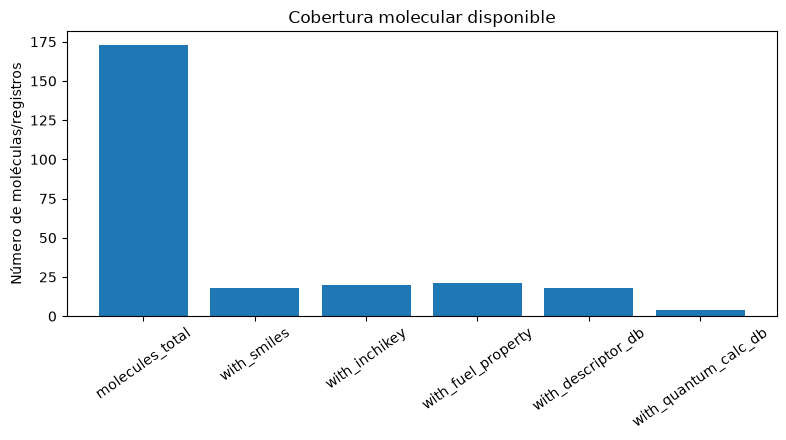

In [3]:
# ============================================================
# FASE 2 — CALIDAD, COBERTURA, CARDINALIDAD Y COMPLETITUD
# ============================================================
display(Markdown("## FASE 2 · Calidad y disponibilidad analítica"))

quality=[]
for table,df in DB.items():
    for c in df.columns:
        quality.append({
            "table":table,"column":c,"dtype":str(df[c].dtype),"rows":len(df),
            "non_null":int(df[c].notna().sum()),"null":int(df[c].isna().sum()),
            "null_pct":100*float(df[c].isna().mean()) if len(df) else np.nan,
            "n_unique":int(df[c].nunique(dropna=True)),
        })
quality=pd.DataFrame(quality)
quality.to_csv(TABLE_DIR/"02_column_quality.csv",index=False)

cardinality=pd.DataFrame([
    {"relationship":"biomass -> composition","parents":len(DB["biomass"]),"children":len(DB["biomass_composition"]),"mean_children":DB["biomass_composition"].groupby("biomass_id").size().mean()},
    {"relationship":"biomass -> molecule evidence","parents":len(DB["biomass"]),"children":len(DB["biomass_molecule"]),"mean_children":DB["biomass_molecule"].groupby("biomass_id").size().mean()},
    {"relationship":"molecule -> fuel_property","parents":len(DB["molecule"]),"children":len(DB["fuel_property"]),"mean_children":DB["fuel_property"].groupby("molecule_id").size().mean()},
    {"relationship":"reaction -> participant","parents":len(DB["reaction"]),"children":len(DB["reaction_participant"]),"mean_children":DB["reaction_participant"].groupby("reaction_id").size().mean()},
])
cardinality.to_csv(TABLE_DIR/"02_cardinality.csv",index=False)

display(quality.sort_values(["null_pct","table"],ascending=[False,True]).head(35))
display(cardinality)

molecule_coverage=pd.DataFrame({
    "metric":["molecules_total","with_smiles","with_inchikey","with_fuel_property","with_descriptor_db","with_quantum_calc_db"],
    "n":[
        len(DB["molecule"]),
        int(DB["molecule"]["canonical_smiles"].notna().sum()),
        int(DB["molecule"]["inchikey"].notna().sum()),
        DB["fuel_property"]["molecule_id"].nunique(),
        DB["molecular_descriptor"]["molecule_id"].nunique(),
        DB["quantum_calculation"]["molecule_id"].nunique(),
    ]
})
molecule_coverage["pct_total_molecules"]=100*molecule_coverage["n"]/max(len(DB["molecule"]),1)
display(molecule_coverage)
molecule_coverage.to_csv(TABLE_DIR/"02_molecule_coverage.csv",index=False)

if PACKAGE_STATUS["matplotlib"]:
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(figsize=(8,4.5))
    ax.bar(molecule_coverage["metric"],molecule_coverage["n"])
    ax.set_ylabel("Número de moléculas/registros")
    ax.set_title("Cobertura molecular disponible")
    ax.tick_params(axis="x",rotation=35)
    fig.tight_layout(); fig.savefig(FIG_DIR/"02_molecule_coverage.png",dpi=180,bbox_inches="tight"); plt.show()


## FASE 3 · Composición de biomasa residual: estadística descriptiva e inferencial

,variable,n,mean,sd,median,q1,q3,iqr,min,max,skew
0,cellulose_pct,48,34.45104,15.32252,36.08000,26.38000,42.51750,16.13750,4.40000,71.00000,0.06762
1,hemicellulose_pct,50,20.37220,9.34014,22.17500,12.55000,26.95000,14.40000,4.33000,40.00000,-0.12057
2,lignin_total_pct,53,14.89019,10.06025,14.12000,7.52000,19.80000,12.28000,0.70000,50.62000,0.95633
3,extractives_pct,11,13.97727,12.33035,13.20000,4.00000,18.75000,14.75000,2.20000,40.00000,1.00900
4,ash_pct,38,4.09026,3.51886,2.65000,1.42500,5.82750,4.40250,0.04000,12.25000,1.02158
5,moisture_pct,6,8.55333,2.26703,9.05000,7.58250,10.00000,2.41750,4.81000,11.00000,-0.85845
6,carbon_pct,12,46.48417,3.17361,46.53000,44.88750,48.21000,3.32250,41.68000,52.80000,0.21367
7,hydrogen_pct,12,5.99333,0.77655,5.95500,5.72000,6.15250,0.43250,4.83000,7.44000,0.53950
8,oxygen_pct,9,44.29000,4.48894,44.38000,42.46000,47.67000,5.21000,34.60000,50.06000,-1.14531
9,hhv_value,8,18.53250,1.25603,18.78000,18.18500,19.35000,1.16500,16.04000,20.02000,-1.15837


,biomass_id,common_name,biomass_category,residue_type,n_measurements,n_sources,cellulose_median,hemicellulose_median,lignin_median,ash_median,moisture_median,hhv_median,structural_carbohydrates_median
17,40,flax fiber,herbaceous_biomass,fiber,4,1,64.55000,16.40000,2.35000,NaN,10.00000,NaN,80.90000
16,39,flax straw,agricultural_residue,straw,1,1,51.34000,25.20000,14.12000,4.13000,11.00000,NaN,76.54000
41,162,hardwood stem,woody_biomass,stem,1,1,45.00000,30.00000,20.00000,0.60000,NaN,NaN,75.00000
39,151,orchard grass,herbaceous_biomass,grass,1,1,32.00000,40.00000,4.70000,NaN,NaN,NaN,72.00000
0,1,wheat straw,agricultural_residue,straw,8,4,41.90000,32.28000,10.23000,2.80000,NaN,17.51000,71.15000
40,161,softwood stem,woody_biomass,stem,1,1,42.00000,27.00000,28.00000,0.50000,NaN,NaN,69.00000
1,2,rice straw,agricultural_residue,straw,6,6,38.45500,25.35000,17.80000,12.10000,7.41000,16.04000,65.05000
2,3,rice husk,agroindustrial_residue,husk,2,1,39.95000,23.40000,18.85000,NaN,NaN,NaN,63.35000
46,182,spelt straw,agricultural_residue,straw,1,1,38.30000,24.30000,14.80000,5.70000,NaN,NaN,62.60000
15,38,rice bran,food_industry_residue,bran,1,1,34.00000,28.20000,24.80000,NaN,NaN,NaN,62.20000


Outliers robustos marcados (no eliminados): 1


,var_a,var_b,n,spearman_rho,p_value,q_fdr_bh
12,carbon_pct,hhv_value,8,0.97619,0.00003,0.00053
0,cellulose_pct,hemicellulose_pct,48,0.44960,0.00135,0.01077
3,hemicellulose_pct,lignin_total_pct,50,0.33304,0.01811,0.09661
5,lignin_total_pct,ash_pct,24,-0.39791,0.05414,0.17326
9,ash_pct,hhv_value,8,-0.71429,0.04653,0.17326
6,ash_pct,carbon_pct,11,-0.55455,0.07665,0.20441
4,hemicellulose_pct,ash_pct,22,-0.28805,0.19360,0.43369
2,cellulose_pct,ash_pct,20,-0.27980,0.23216,0.43369
11,carbon_pct,oxygen_pct,9,-0.43333,0.24395,0.43369
15,oxygen_pct,hhv_value,8,-0.33333,0.41975,0.67160


,variable,n,groups,H,p_value,epsilon_squared,group_labels,q_fdr_bh
0,cellulose_pct,46,4,21.83547,0.00007,0.44846,agricultural_residue | agroindustrial_residue ...,0.00009
1,hemicellulose_pct,48,4,22.11615,0.00006,0.43446,agricultural_residue | agroindustrial_residue ...,0.00009
2,lignin_total_pct,50,4,26.34489,0.00001,0.50750,agricultural_residue | agroindustrial_residue ...,0.00003
3,ash_pct,36,5,20.04988,0.00049,0.51774,agricultural_residue | agroindustrial_residue ...,0.00049


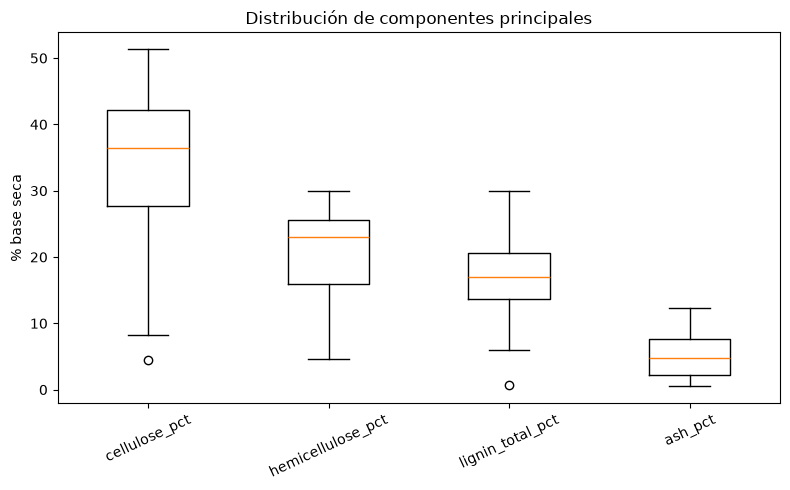

In [4]:
# ============================================================
# FASE 3 — EDA AVANZADO DE BIOMASA + ESTADÍSTICA ROBUSTA
# ============================================================
display(Markdown("## FASE 3 · Composición de biomasa residual: estadística descriptiva e inferencial"))

biomass=DB["biomass"].copy()
composition=DB["biomass_composition"].copy()
sources=DB["source"].copy()

comp=(composition
      .merge(biomass[["biomass_id","common_name","scientific_name","biomass_category","residue_type"]],on="biomass_id",how="left",validate="many_to_one")
      .merge(sources[["source_id","title","year","doi","evidence_quality"]],on="source_id",how="left",validate="many_to_one"))
comp["structural_carbohydrates_pct"]=comp[["cellulose_pct","hemicellulose_pct"]].sum(axis=1,min_count=2)
comp["lignocellulosic_total_pct"]=comp[["cellulose_pct","hemicellulose_pct","lignin_total_pct"]].sum(axis=1,min_count=3)
comp_dry=comp[comp["measurement_basis"].eq("dry_basis")].copy()

core_vars=["cellulose_pct","hemicellulose_pct","lignin_total_pct","extractives_pct","ash_pct","moisture_pct","carbon_pct","hydrogen_pct","oxygen_pct","hhv_value"]
rows=[]
for c in core_vars:
    s=pd.to_numeric(comp_dry[c],errors="coerce").dropna()
    if len(s):
        q1,q3=s.quantile([.25,.75])
        rows.append({"variable":c,"n":len(s),"mean":s.mean(),"sd":s.std(ddof=1),"median":s.median(),"q1":q1,"q3":q3,"iqr":q3-q1,"min":s.min(),"max":s.max(),"skew":s.skew()})
descriptive=pd.DataFrame(rows)
descriptive.to_csv(TABLE_DIR/"03_biomass_descriptive_stats.csv",index=False)
display(descriptive)

summary=(comp_dry.groupby(["biomass_id","common_name","biomass_category","residue_type"],dropna=False)
    .agg(n_measurements=("composition_id","count"),n_sources=("source_id","nunique"),
         cellulose_median=("cellulose_pct","median"),hemicellulose_median=("hemicellulose_pct","median"),
         lignin_median=("lignin_total_pct","median"),ash_median=("ash_pct","median"),
         moisture_median=("moisture_pct","median"),hhv_median=("hhv_value","median"),
         structural_carbohydrates_median=("structural_carbohydrates_pct","median"))
    .reset_index())
summary.to_csv(TABLE_DIR/"03_biomass_summary_dry_basis.csv",index=False)
display(summary.sort_values("structural_carbohydrates_median",ascending=False).head(20))

# Outliers robustos por MAD: se marcan, no se eliminan.
def robust_z(s):
    s=pd.to_numeric(s,errors="coerce")
    med=s.median(); mad=np.median(np.abs(s.dropna()-med)) if s.notna().any() else np.nan
    if not np.isfinite(mad) or mad==0: return pd.Series(np.nan,index=s.index)
    return 0.67448975*(s-med)/mad
outlier_rows=[]
for c in ["cellulose_pct","hemicellulose_pct","lignin_total_pct","ash_pct","hhv_value"]:
    rz=robust_z(comp_dry[c])
    idx=rz.abs()>3.5
    for i in comp_dry.index[idx.fillna(False)]:
        outlier_rows.append({"composition_id":int(comp_dry.loc[i,"composition_id"]),"biomass_id":int(comp_dry.loc[i,"biomass_id"]),"common_name":comp_dry.loc[i,"common_name"],"variable":c,"value":comp_dry.loc[i,c],"robust_z":rz.loc[i]})
outliers=pd.DataFrame(outlier_rows)
outliers.to_csv(TABLE_DIR/"03_robust_outliers_flagged.csv",index=False)
print("Outliers robustos marcados (no eliminados):",len(outliers))

# Correlaciones Spearman + corrección Benjamini-Hochberg.
if PACKAGE_STATUS["scipy"]:
    from scipy.stats import spearmanr, kruskal
    def bh_fdr(pvals):
        p=np.asarray(pvals,float); order=np.argsort(p); q=np.empty_like(p); prev=1.0; n=len(p)
        for rank,idx in reversed(list(enumerate(order,start=1))):
            prev=min(prev,p[idx]*n/rank); q[idx]=prev
        return q
    corr_vars=[c for c in ["cellulose_pct","hemicellulose_pct","lignin_total_pct","ash_pct","carbon_pct","hydrogen_pct","oxygen_pct","hhv_value"] if c in comp_dry]
    corr_rows=[]
    for i,a in enumerate(corr_vars):
        for b in corr_vars[i+1:]:
            pair=comp_dry[[a,b]].dropna()
            if len(pair)>=8:
                rho,p=spearmanr(pair[a],pair[b])
                corr_rows.append({"var_a":a,"var_b":b,"n":len(pair),"spearman_rho":rho,"p_value":p})
    spearman_table=pd.DataFrame(corr_rows)
    if not spearman_table.empty:
        spearman_table["q_fdr_bh"]=bh_fdr(spearman_table["p_value"].to_numpy())
        spearman_table.to_csv(TABLE_DIR/"03_spearman_correlations_fdr.csv",index=False)
        display(spearman_table.sort_values("q_fdr_bh").head(20))

    # Kruskal-Wallis por categoría para variables con grupos suficientes.
    kw=[]
    for variable in ["cellulose_pct","hemicellulose_pct","lignin_total_pct","ash_pct","hhv_value"]:
        groups=[]; labels=[]
        for label,g in comp_dry.groupby("biomass_category"):
            vals=pd.to_numeric(g[variable],errors="coerce").dropna()
            if len(vals)>=3:
                groups.append(vals.to_numpy()); labels.append(label)
        if len(groups)>=2:
            H,p=kruskal(*groups); n=sum(map(len,groups)); k=len(groups)
            eps2=max(0.0,(H-k+1)/(n-k)) if n>k else np.nan
            kw.append({"variable":variable,"n":n,"groups":k,"H":H,"p_value":p,"epsilon_squared":eps2,"group_labels":" | ".join(map(str,labels))})
    kruskal_table=pd.DataFrame(kw)
    if not kruskal_table.empty:
        kruskal_table["q_fdr_bh"]=bh_fdr(kruskal_table["p_value"].to_numpy())
        kruskal_table.to_csv(TABLE_DIR/"03_kruskal_by_biomass_category.csv",index=False)
        display(kruskal_table)

if PACKAGE_STATUS["matplotlib"]:
    import matplotlib.pyplot as plt
    plot=comp_dry[["cellulose_pct","hemicellulose_pct","lignin_total_pct","ash_pct"]].dropna()
    if len(plot):
        fig,ax=plt.subplots(figsize=(8,5))
        ax.boxplot([plot[c] for c in plot.columns],tick_labels=plot.columns,showfliers=True)
        ax.set_ylabel("% base seca")
        ax.set_title("Distribución de componentes principales")
        ax.tick_params(axis="x",rotation=25)
        fig.tight_layout(); fig.savefig(FIG_DIR/"03_composition_boxplots.png",dpi=180,bbox_inches="tight"); plt.show()


In [5]:
# ============================================================
# FASE 4 — PCA COMPOSICIONAL + CRIBADO PARETO DE BIOMASA
# ============================================================
display(Markdown("## FASE 4 · Espacio composicional y cribado multiobjetivo"))

bio_features=["cellulose_pct","hemicellulose_pct","lignin_total_pct","ash_pct","extractives_pct"]
bio_pca_scores=pd.DataFrame()
if PACKAGE_STATUS["sklearn"]:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    pca_df=comp_dry[["composition_id","biomass_id","common_name",*bio_features]].dropna().copy()
    if len(pca_df)>=10:
        Xs=StandardScaler().fit_transform(pca_df[bio_features])
        pca=PCA(n_components=min(3,len(bio_features),len(pca_df)-1),random_state=SEED)
        Z=pca.fit_transform(Xs)
        bio_pca_scores=pca_df[["composition_id","biomass_id","common_name"]].copy()
        for j in range(Z.shape[1]): bio_pca_scores[f"PC{j+1}"]=Z[:,j]
        bio_pca_scores.to_csv(TABLE_DIR/"04_biomass_pca_scores.csv",index=False)
        pd.DataFrame({"PC":[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],"explained_variance_ratio":pca.explained_variance_ratio_}).to_csv(TABLE_DIR/"04_biomass_pca_variance.csv",index=False)
        if PACKAGE_STATUS["matplotlib"] and Z.shape[1]>=2:
            import matplotlib.pyplot as plt
            fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(Z[:,0],Z[:,1],alpha=.7)
            ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
            ax.set_title("PCA de composición lignocelulósica"); fig.tight_layout(); fig.savefig(FIG_DIR/"04_biomass_pca.png",dpi=180,bbox_inches="tight"); plt.show()

def pareto_front(df: pd.DataFrame, maximize: list[str], minimize: list[str]) -> pd.Series:
    cols=maximize+minimize
    if df[cols].isna().any().any(): raise ValueError("Pareto requiere objetivos completos")
    X=np.column_stack([*(-df[c].to_numpy(float) for c in maximize),*(df[c].to_numpy(float) for c in minimize)])
    eff=np.ones(len(df),dtype=bool)
    for i in range(len(df)):
        eff[i]=not np.any(np.all(X<=X[i],axis=1)&np.any(X<X[i],axis=1))
    return pd.Series(eff,index=df.index)

bio_pool=summary.dropna(subset=["structural_carbohydrates_median","lignin_median","ash_median"]).copy()
bio_front=pd.DataFrame()
if len(bio_pool):
    bio_pool["pareto_biochemical"]=pareto_front(bio_pool,["structural_carbohydrates_median","n_sources"],["lignin_median","ash_median"])
    bio_front=bio_pool[bio_pool["pareto_biochemical"]].copy()
    bio_pool.to_csv(TABLE_DIR/"04_biomass_pareto_all.csv",index=False); bio_front.to_csv(TABLE_DIR/"04_biomass_pareto_front.csv",index=False)
    display(bio_front.sort_values(["structural_carbohydrates_median","lignin_median"],ascending=[False,True]))

# Cribado termoquímico: no mezcla unidades de HHV.
thermo_rows=comp_dry.loc[comp_dry["hhv_unit"].eq("MJ/kg")].dropna(subset=["hhv_value","ash_pct","moisture_pct"]).copy()
thermo_front=pd.DataFrame()
if len(thermo_rows):
    thermo_rows["pareto_thermochemical"]=pareto_front(thermo_rows,["hhv_value"],["ash_pct","moisture_pct"])
    thermo_front=thermo_rows[thermo_rows["pareto_thermochemical"]].copy()
    thermo_front.to_csv(TABLE_DIR/"04_biomass_thermochemical_pareto.csv",index=False)
print("Pareto bioquímico:",len(bio_front),"de",len(bio_pool),"| Pareto termoquímico:",len(thermo_front),"de",len(thermo_rows))


## FASE 4 · Espacio composicional y cribado multiobjetivo

,biomass_id,common_name,biomass_category,residue_type,n_measurements,n_sources,cellulose_median,hemicellulose_median,lignin_median,ash_median,moisture_median,hhv_median,structural_carbohydrates_median,pareto_biochemical
16,39,flax straw,agricultural_residue,straw,1,1,51.34000,25.20000,14.12000,4.13000,11.00000,NaN,76.54000,True
41,162,hardwood stem,woody_biomass,stem,1,1,45.00000,30.00000,20.00000,0.60000,NaN,NaN,75.00000,True
0,1,wheat straw,agricultural_residue,straw,8,4,41.90000,32.28000,10.23000,2.80000,NaN,17.51000,71.15000,True
40,161,softwood stem,woody_biomass,stem,1,1,42.00000,27.00000,28.00000,0.50000,NaN,NaN,69.00000,True
1,2,rice straw,agricultural_residue,straw,6,6,38.45500,25.35000,17.80000,12.10000,7.41000,16.04000,65.05000,True
9,20,oat straw,agricultural_residue,straw,1,1,37.60000,23.34000,12.85000,2.19000,NaN,NaN,60.94000,True
14,35,canola straw,agricultural_residue,straw,1,1,42.39000,16.41000,14.15000,2.10000,NaN,NaN,58.80000,True
18,42,flax oil cake,food_industry_residue,oil_cake,1,1,8.20000,4.60000,6.00000,5.30000,NaN,NaN,12.80000,True
20,46,hull-less pumpkin oil cake,food_industry_residue,oil_cake,1,1,4.40000,6.70000,0.70000,7.80000,NaN,NaN,11.10000,True


Pareto bioquímico: 9 de 16 | Pareto termoquímico: 1 de 1


In [6]:
# ============================================================
# FASE 5 — PROPIEDADES DE COMBUSTIBLE: UNIDADES, REPETIBILIDAD Y COBERTURA
# ============================================================
display(Markdown("## FASE 5 · Propiedades de candidatos e incertidumbre entre fuentes"))

molecules=DB["molecule"].copy()
fuel=(DB["fuel_property"]
      .merge(molecules[["molecule_id","preferred_name","molecule_role","canonical_smiles"]],on="molecule_id",how="left",validate="many_to_one")
      .merge(sources[["source_id","title","year","doi"]],on="source_id",how="left",validate="many_to_one",suffixes=("","_source")))

def standardize_property(row):
    prop,value,unit=row["property_name"],row["value"],row["unit"]
    if pd.isna(value): return pd.Series([np.nan,unit,"missing"])
    if prop=="density" and unit=="g/cm3": return pd.Series([float(value)*1000.0,"kg/m3","g/cm3_to_kg/m3_x1000"])
    if prop=="density" and unit=="kg/m3": return pd.Series([float(value),"kg/m3","identity"])
    return pd.Series([float(value),unit,"identity"])
fuel[["value_std","unit_std","conversion"]]=fuel.apply(standardize_property,axis=1)
fuel.to_csv(TABLE_DIR/"05_fuel_properties_harmonized.csv",index=False)

fuel_summary=(fuel.groupby(["property_name","unit_std"],dropna=False)
              .agg(n_measurements=("fuel_property_id","count"),n_molecules=("molecule_id","nunique"),n_sources=("source_id","nunique"),median=("value_std","median"),mean=("value_std","mean"),sd=("value_std","std"))
              .reset_index())
display(fuel_summary.sort_values("n_molecules",ascending=False))
fuel_summary.to_csv(TABLE_DIR/"05_fuel_property_summary.csv",index=False)

# Variabilidad entre fuentes para una misma molécula/propiedad/unidad.
rep=(fuel.groupby(["molecule_id","preferred_name","property_name","unit_std"],dropna=False)
     .agg(n=("value_std","count"),mean=("value_std","mean"),sd=("value_std","std"),min=("value_std","min"),max=("value_std","max"),n_sources=("source_id","nunique"))
     .reset_index())
rep["cv_pct"]=100*rep["sd"].abs()/rep["mean"].abs()
rep.to_csv(TABLE_DIR/"05_between_source_variability.csv",index=False)
display(rep[rep["n"]>=2].sort_values("cv_pct",ascending=False).head(20))

# Matriz de medianas SOLO para exploración; conserva por separado las mediciones originales.
fuel_matrix=(fuel.groupby(["molecule_id","preferred_name","property_name","unit_std"],dropna=False)["value_std"].median().reset_index())
fuel_matrix["feature"]=fuel_matrix["property_name"].astype(str)+" ["+fuel_matrix["unit_std"].fillna("unitless").astype(str)+"]"
fuel_wide=fuel_matrix.pivot_table(index=["molecule_id","preferred_name"],columns="feature",values="value_std",aggfunc="first").reset_index()
fuel_wide.to_csv(TABLE_DIR/"05_fuel_property_matrix_medians.csv",index=False)
display(fuel_wide.head(20))


## FASE 5 · Propiedades de candidatos e incertidumbre entre fuentes

,property_name,unit_std,n_measurements,n_molecules,n_sources,median,mean,sd
7,specific_energy,MJ/kg,11,11,2,43.56000,43.55364,0.56132
0,boiling_point,°C,14,10,4,92.92500,118.94500,55.95310
1,density,kg/m3,11,10,3,854.00000,857.77455,38.77630
2,energy_density,MJ/L,10,9,3,34.91500,34.11100,2.78653
3,flash_point,°C,4,4,1,45.85000,45.42500,4.60679
4,lower_heating_value,MJ/kg,5,4,2,33.30000,33.14000,1.27201
5,melting_point,°C,4,4,1,-64.70000,-61.55000,18.44081
6,octane_number,NaN,5,3,3,119.00000,109.20000,14.70374


,molecule_id,preferred_name,property_name,unit_std,n,mean,sd,min,max,n_sources,cv_pct
11,15,"2,5-dimethylfuran",lower_heating_value,MJ/kg,2,33.55000,0.35355,33.30000,33.80000,2,1.05381
8,15,"2,5-dimethylfuran",boiling_point,°C,4,92.67500,0.55453,91.85000,93.00000,4,0.59836
2,8,2-methylfuran,boiling_point,°C,2,62.92500,0.10607,62.85000,63.00000,2,0.16856
9,15,"2,5-dimethylfuran",density,kg/m3,2,889.85000,0.21213,889.70000,890.00000,2,0.02384
10,15,"2,5-dimethylfuran",energy_density,MJ/L,2,30.00000,0.00000,30.00000,30.00000,2,0.00000
12,15,"2,5-dimethylfuran",octane_number,NaN,3,119.00000,0.00000,119.00000,119.00000,3,0.00000


feature,molecule_id,preferred_name,boiling_point [°C],density [kg/m3],energy_density [MJ/L],flash_point [°C],lower_heating_value [MJ/kg],melting_point [°C],octane_number [unitless],specific_energy [MJ/kg]
0,6,furfural,161.55000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,furfuryl alcohol,171.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,2-methylfuran,62.92500,910.00000,NaN,NaN,31.20000,NaN,103.00000,NaN
3,13,cyclohexane,80.78000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,14,gamma-valerolactone,207.55000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,15,"2,5-dimethylfuran",92.92500,889.85000,30.00000,NaN,33.55000,NaN,119.00000,NaN
6,16,methyl levulinate,196.05000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,17,ethyl levulinate,205.85000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,18,tetrahydrofuran,65.85000,889.20000,NaN,NaN,34.60000,NaN,NaN,NaN
9,19,2-methyltetrahydrofuran,80.05000,854.00000,NaN,NaN,32.80000,NaN,86.00000,NaN


In [7]:
# ============================================================
# FASE 6A — RDKIT AVANZADO: VALIDACIÓN + CATÁLOGO COMPLETO 2D + MORGAN
# ============================================================
display(Markdown("## FASE 6A · RDKit: estructura, descriptores 2D y fingerprints"))

rdkit_input=molecules.loc[molecules["canonical_smiles"].notna() & molecules["canonical_smiles"].astype(str).str.strip().ne(""),
                           ["molecule_id","preferred_name","canonical_smiles","charge","multiplicity","molecule_role"]].copy()
print(f"Moléculas: {len(molecules)} | con SMILES: {len(rdkit_input)} | sin SMILES: {len(molecules)-len(rdkit_input)}")

rdkit_2d_long=pd.DataFrame(); rdkit_2d_wide=pd.DataFrame(); smiles_qc=pd.DataFrame(); fingerprint_matrix=None; fingerprint_ids=[]
if not PACKAGE_STATUS["rdkit"]:
    raise RuntimeError("RDKit no está instalado. Instala requirements_science_COMPLETO.txt")
else:
    from rdkit import Chem, rdBase, DataStructs
    from rdkit.Chem import Descriptors, AllChem, Lipinski, rdMolDescriptors
    from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

    desc_list=list(Descriptors.descList)
    rdkit_config_hash=hashlib.sha256((rdBase.rdkitVersion+"|"+"|".join(n for n,_ in desc_list)).encode()).hexdigest()[:16]
    rows=[]; qc=[]; fp=[]; fingerprint_ids=[]
    morgan=GetMorganGenerator(radius=2,fpSize=2048,includeChirality=True)
    for r in rdkit_input.itertuples(index=False):
        mol=Chem.MolFromSmiles(str(r.canonical_smiles))
        if mol is None:
            qc.append({"molecule_id":r.molecule_id,"preferred_name":r.preferred_name,"status":"invalid_smiles","canonicalized_smiles":None,"formula":None})
            continue
        can=Chem.MolToSmiles(mol,canonical=True,isomericSmiles=True)
        formula=rdMolDescriptors.CalcMolFormula(mol)
        qc.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"status":"ok","canonicalized_smiles":can,"formula":formula})
        vals={}
        for name,func in desc_list:
            try:
                v=float(func(mol)); vals[name]=v if np.isfinite(v) else np.nan
            except Exception:
                vals[name]=np.nan
        for name,v in vals.items():
            if np.isfinite(v):
                rows.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"descriptor_name":name,"descriptor_value":v,"unit":None,"software":"RDKit","software_version":rdBase.rdkitVersion,"calculation_date":pd.Timestamp.today().date(),"config_hash":rdkit_config_hash,"notes":"RDKit Descriptors.descList; 2D"})
        bv=morgan.GetFingerprint(mol)
        arr=np.zeros((2048,),dtype=np.uint8); DataStructs.ConvertToNumpyArray(bv,arr)
        fp.append(arr); fingerprint_ids.append(int(r.molecule_id))

    smiles_qc=pd.DataFrame(qc); rdkit_2d_long=pd.DataFrame(rows)
    rdkit_2d_wide=rdkit_2d_long.pivot(index="molecule_id",columns="descriptor_name",values="descriptor_value").reset_index() if not rdkit_2d_long.empty else pd.DataFrame()
    fingerprint_matrix=np.vstack(fp) if fp else np.empty((0,2048),dtype=np.uint8)
    smiles_qc.to_csv(TABLE_DIR/"06a_smiles_qc.csv",index=False)
    rdkit_2d_long.to_csv(TABLE_DIR/"06a_rdkit_2d_long.csv",index=False)
    rdkit_2d_wide.to_csv(TABLE_DIR/"06a_rdkit_2d_wide.csv",index=False)
    np.savez_compressed(TABLE_DIR/"06a_morgan_r2_2048.npz",molecule_id=np.asarray(fingerprint_ids),X=fingerprint_matrix)
    print("SMILES válidos:",int((smiles_qc.status=="ok").sum()),"| descriptores 2D calculados:",rdkit_2d_long.descriptor_name.nunique(),"| valores:",len(rdkit_2d_long))
    display(smiles_qc)

    # Persistencia idempotente: solo inserta combinaciones no existentes.
    if WRITE_RDKIT_TO_MYSQL and not rdkit_2d_long.empty:
        existing=sql_df("SELECT molecule_id, descriptor_name, software, config_hash FROM molecular_descriptor")
        keys=set(zip(existing.molecule_id.astype(int),existing.descriptor_name.astype(str),existing.software.fillna("").astype(str),existing.config_hash.fillna("").astype(str))) if len(existing) else set()
        ins=rdkit_2d_long[["molecule_id","descriptor_name","descriptor_value","unit","software","software_version","calculation_date","config_hash","notes"]].copy()
        keep=[(int(r.molecule_id),str(r.descriptor_name),str(r.software),str(r.config_hash)) not in keys for r in ins.itertuples(index=False)]
        ins=ins.loc[keep]
        if len(ins):
            with engine.begin() as conn: ins.to_sql("molecular_descriptor",conn,if_exists="append",index=False,method="multi",chunksize=500)
        print(f"RDKit 2D persistidos nuevos en MySQL: {len(ins)}")


## FASE 6A · RDKit: estructura, descriptores 2D y fingerprints

Moléculas: 173 | con SMILES: 18 | sin SMILES: 155
SMILES válidos: 18 | descriptores 2D calculados: 217 | valores: 3906


,molecule_id,preferred_name,status,canonicalized_smiles,formula
0,1,D-glucose,ok,OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O,C6H12O6
1,2,D-xylose,ok,OC1OC[C@@H](O)[C@H](O)[C@H]1O,C5H10O5
2,3,5-hydroxymethylfurfural,ok,O=Cc1ccc(CO)o1,C6H6O3
3,4,levulinic acid,ok,CC(=O)CCC(=O)O,C5H8O3
4,5,sorbitol,ok,OC[C@@H](O)[C@@H](O)[C@H](O)[C@@H](O)CO,C6H14O6
5,6,furfural,ok,O=Cc1ccco1,C5H4O2
6,7,furfuryl alcohol,ok,OCc1ccco1,C5H6O2
7,8,2-methylfuran,ok,Cc1ccco1,C5H6O
8,9,phenol,ok,Oc1ccccc1,C6H6O
9,10,guaiacol,ok,COc1ccccc1O,C7H8O2


RDKit 2D persistidos nuevos en MySQL: 0


In [8]:
# ============================================================
# FASE 6B — CONFORMER ENSEMBLE ETKDGv3 + MMFF/UFF + DESCRIPTORES 3D
# ============================================================
display(Markdown("## FASE 6B · Ensemble conformacional y geometría 3D"))

from rdkit.Chem import rdMolDescriptors
conformer_rows=[]; descriptor3d_rows=[]; conformer_summary=[]
R_KCAL=0.00198720425864083

for r in rdkit_input.itertuples(index=False):
    mol0=Chem.MolFromSmiles(str(r.canonical_smiles))
    if mol0 is None: continue
    mol=Chem.AddHs(mol0)
    n_rot=int(Lipinski.NumRotatableBonds(mol0))
    nconf=int(min(MAX_CONFORMERS,max(MIN_CONFORMERS,12+4*n_rot)))
    params=AllChem.ETKDGv3(); params.randomSeed=SEED+int(r.molecule_id); params.pruneRmsThresh=0.35; params.useRandomCoords=False
    conf_ids=list(AllChem.EmbedMultipleConfs(mol,numConfs=nconf,params=params))
    if not conf_ids:
        conformer_summary.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"status":"embed_failed","best_xyz_path":None,"n_embedded":0,"n_kept_5kcal":0})
        continue
    energies=[]; ff_name=None
    for cid in conf_ids:
        try:
            if AllChem.MMFFHasAllMoleculeParams(mol):
                props=AllChem.MMFFGetMoleculeProperties(mol,mmffVariant="MMFF94")
                ff=AllChem.MMFFGetMoleculeForceField(mol,props,confId=int(cid)); ff.Minimize(maxIts=2500); e=float(ff.CalcEnergy()); ff_name="MMFF94"
            else:
                ff=AllChem.UFFGetMoleculeForceField(mol,confId=int(cid)); ff.Minimize(maxIts=2500); e=float(ff.CalcEnergy()); ff_name="UFF"
        except Exception:
            e=np.nan
        energies.append((int(cid),e))
    finite=[x for x in energies if np.isfinite(x[1])]
    if not finite:
        conformer_summary.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"status":"ff_failed","best_xyz_path":None,"n_embedded":len(conf_ids),"n_kept_5kcal":0})
        continue
    best_cid,best_e=min(finite,key=lambda x:x[1])
    denom=sum(np.exp(-(e-best_e)/(R_KCAL*BOLTZMANN_T_K)) for _,e in finite)
    for cid,e in finite:
        de=e-best_e; w=np.exp(-de/(R_KCAL*BOLTZMANN_T_K))/denom
        conformer_rows.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"conf_id":cid,"force_field":ff_name,"energy_kcal_mol":e,"delta_e_kcal_mol":de,"boltzmann_weight_298K":w,"within_5kcal":de<=CONFORMER_WINDOW_KCAL})
    xyz=CONF_DIR/f"molecule_{int(r.molecule_id):04d}_best.xyz"
    Chem.MolToXYZFile(mol,str(xyz),confId=best_cid)
    sdf=CONF_DIR/f"molecule_{int(r.molecule_id):04d}_ensemble.sdf"
    writer=Chem.SDWriter(str(sdf))
    for cid,e in finite:
        if e-best_e<=CONFORMER_WINDOW_KCAL:
            mol.SetProp("molecule_id",str(int(r.molecule_id))); mol.SetProp("conformer_id",str(cid)); mol.SetProp("energy_kcal_mol",f"{e:.8f}")
            writer.write(mol,confId=cid)
    writer.close()
    conf=mol.GetConformer(best_cid)
    funcs={
        "RadiusOfGyration":rdMolDescriptors.CalcRadiusOfGyration,
        "Asphericity":rdMolDescriptors.CalcAsphericity,
        "Eccentricity":rdMolDescriptors.CalcEccentricity,
        "InertialShapeFactor":rdMolDescriptors.CalcInertialShapeFactor,
        "SpherocityIndex":rdMolDescriptors.CalcSpherocityIndex,
        "PMI1":rdMolDescriptors.CalcPMI1,"PMI2":rdMolDescriptors.CalcPMI2,"PMI3":rdMolDescriptors.CalcPMI3,
        "NPR1":rdMolDescriptors.CalcNPR1,"NPR2":rdMolDescriptors.CalcNPR2,
    }
    cfg3=hashlib.sha256(f"RDKit3D|{rdBase.rdkitVersion}|ETKDGv3|{ff_name}|seed={SEED}".encode()).hexdigest()[:16]
    for name,func in funcs.items():
        try:
            descriptor3d_rows.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"descriptor_name":name,"descriptor_value":float(func(mol,confId=best_cid)),"unit":None,"software":"RDKit","software_version":rdBase.rdkitVersion,"calculation_date":pd.Timestamp.today().date(),"config_hash":cfg3,"notes":"3D on minimum-energy ETKDGv3 conformer after FF optimization"})
        except Exception: pass
    conformer_summary.append({"molecule_id":int(r.molecule_id),"preferred_name":r.preferred_name,"status":"ok","force_field":ff_name,"best_energy_kcal_mol":best_e,"best_conf_id":best_cid,"n_embedded":len(conf_ids),"n_kept_5kcal":sum(e-best_e<=CONFORMER_WINDOW_KCAL for _,e in finite),"best_xyz_path":str(xyz.relative_to(PROJECT_ROOT)),"ensemble_sdf_path":str(sdf.relative_to(PROJECT_ROOT))})

conformer_ensemble=pd.DataFrame(conformer_rows); rdkit_3d_long=pd.DataFrame(descriptor3d_rows); conformer_summary=pd.DataFrame(conformer_summary)
conformer_ensemble.to_csv(TABLE_DIR/"06b_conformer_ensemble.csv",index=False); rdkit_3d_long.to_csv(TABLE_DIR/"06b_rdkit_3d_long.csv",index=False); conformer_summary.to_csv(TABLE_DIR/"06b_conformer_summary.csv",index=False)
display(conformer_summary)
print("Conformeros totales optimizados:",len(conformer_ensemble),"| moléculas 3D OK:",int((conformer_summary.status=="ok").sum()))

if WRITE_RDKIT_TO_MYSQL and not rdkit_3d_long.empty:
    existing=sql_df("SELECT molecule_id, descriptor_name, software, config_hash FROM molecular_descriptor")
    keys=set(zip(existing.molecule_id.astype(int),existing.descriptor_name.astype(str),existing.software.fillna("").astype(str),existing.config_hash.fillna("").astype(str))) if len(existing) else set()
    ins=rdkit_3d_long[["molecule_id","descriptor_name","descriptor_value","unit","software","software_version","calculation_date","config_hash","notes"]].copy()
    keep=[(int(r.molecule_id),str(r.descriptor_name),str(r.software),str(r.config_hash)) not in keys for r in ins.itertuples(index=False)]
    ins=ins.loc[keep]
    if len(ins):
        with engine.begin() as conn: ins.to_sql("molecular_descriptor",conn,if_exists="append",index=False,method="multi",chunksize=500)
    print("RDKit 3D persistidos nuevos:",len(ins))


## FASE 6B · Ensemble conformacional y geometría 3D

,molecule_id,preferred_name,status,force_field,best_energy_kcal_mol,best_conf_id,n_embedded,n_kept_5kcal,best_xyz_path,ensemble_sdf_path
0,1,D-glucose,ok,MMFF94,78.58415,0,14,3,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
1,2,D-xylose,ok,MMFF94,62.55956,0,8,1,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
2,3,5-hydroxymethylfurfural,ok,MMFF94,22.85219,0,4,3,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
3,4,levulinic acid,ok,MMFF94,-37.00389,1,12,12,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
4,5,sorbitol,ok,MMFF94,90.34677,22,29,8,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
5,6,furfural,ok,MMFF94,18.18282,1,2,2,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
6,7,furfuryl alcohol,ok,MMFF94,5.42087,1,2,2,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
7,8,2-methylfuran,ok,MMFF94,1.80622,0,1,1,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
8,9,phenol,ok,MMFF94,5.71326,0,1,1,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...
9,10,guaiacol,ok,MMFF94,19.32352,0,1,1,outputs\notebook_complete\conformers\molecule_...,outputs\notebook_complete\conformers\molecule_...


Conformeros totales optimizados: 119 | moléculas 3D OK: 18
RDKit 3D persistidos nuevos: 0


## FASE 6C · Diversidad química y dominio estructural

Descriptores usados tras filtros: 91 | silhouette clustering: 0.5905065299670892


,molecule_id,nearest_neighbor_tanimoto,mean_tanimoto,preferred_name
3,4,0.09091,0.05885,levulinic acid
4,5,0.10000,0.04023,sorbitol
13,14,0.14286,0.07171,gamma-valerolactone
15,171,0.15385,0.04077,2-methylheptane
12,13,0.21429,0.02984,cyclohexane
1,2,0.30769,0.06036,D-xylose
0,1,0.30769,0.06806,D-glucose
2,3,0.33333,0.11669,5-hydroxymethylfurfural
14,15,0.36842,0.11007,"2,5-dimethylfuran"
7,8,0.37500,0.13416,2-methylfuran


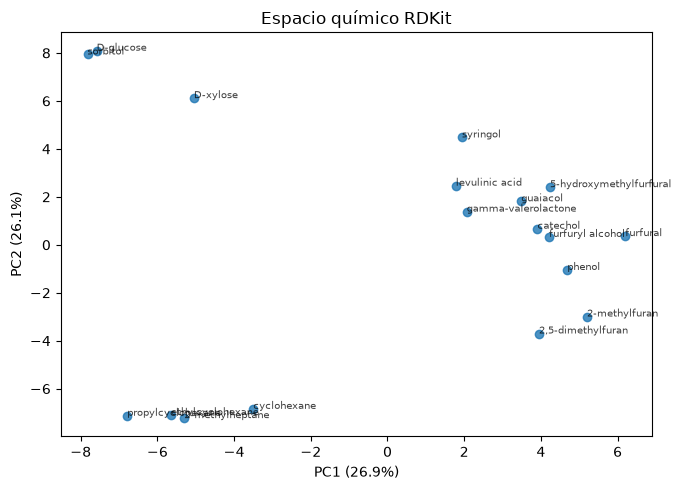

In [9]:
# ============================================================
# FASE 6C — ESPACIO QUÍMICO: PCA, CLUSTERING Y SIMILITUD TANIMOTO
# ============================================================
display(Markdown("## FASE 6C · Diversidad química y dominio estructural"))

chemical_space=pd.DataFrame(); similarity_summary=pd.DataFrame()
if PACKAGE_STATUS["sklearn"] and not rdkit_2d_wide.empty:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.cluster import AgglomerativeClustering
    from sklearn.metrics import silhouette_score
    X=rdkit_2d_wide.set_index("molecule_id").replace([np.inf,-np.inf],np.nan)
    # Solo descriptores completos y no constantes: evita imputar descriptores fallidos.
    X=X.loc[:,X.notna().all(axis=0)]
    X=X.loc[:,X.nunique()>1]
    # Reducir redundancia extrema antes de PCA.
    corr=X.corr().abs(); upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)); drop=[c for c in upper.columns if (upper[c]>0.98).any()]
    Xred=X.drop(columns=drop)
    scaler=StandardScaler(); Xs=scaler.fit_transform(Xred)
    pca=PCA(n_components=min(5,len(Xred.columns),len(Xred)-1),random_state=SEED); Z=pca.fit_transform(Xs)
    chemical_space=pd.DataFrame({"molecule_id":Xred.index.astype(int)})
    for j in range(Z.shape[1]): chemical_space[f"PC{j+1}"]=Z[:,j]
    k=max(2,min(5,int(round(np.sqrt(len(Xred)/2))))) if len(Xred)>=4 else 2
    if len(Xred)>k:
        labels=AgglomerativeClustering(n_clusters=k).fit_predict(Z[:,:min(3,Z.shape[1])]); chemical_space["cluster"]=labels
        sil=silhouette_score(Z[:,:min(3,Z.shape[1])],labels) if len(set(labels))>1 else np.nan
    else:
        chemical_space["cluster"]=0; sil=np.nan
    chemical_space=chemical_space.merge(molecules[["molecule_id","preferred_name","molecule_role"]],on="molecule_id",how="left")
    chemical_space.to_csv(TABLE_DIR/"06c_chemical_space_pca.csv",index=False)
    pd.DataFrame({"PC":[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],"variance_ratio":pca.explained_variance_ratio_}).to_csv(TABLE_DIR/"06c_pca_variance.csv",index=False)
    print("Descriptores usados tras filtros:",Xred.shape[1],"| silhouette clustering:",sil)

    # Similitud de Tanimoto sobre Morgan 2048.
    if fingerprint_matrix is not None and len(fingerprint_matrix):
        from rdkit import DataStructs
        bitvectors=[]
        for arr in fingerprint_matrix:
            bv=DataStructs.ExplicitBitVect(2048)
            on=np.flatnonzero(arr)
            for idx in on: bv.SetBit(int(idx))
            bitvectors.append(bv)
        S=np.eye(len(bitvectors))
        for i in range(len(bitvectors)):
            for j in range(i+1,len(bitvectors)):
                S[i,j]=S[j,i]=DataStructs.TanimotoSimilarity(bitvectors[i],bitvectors[j])
        sim_rows=[]
        for i,mid in enumerate(fingerprint_ids):
            others=np.delete(S[i],i)
            sim_rows.append({"molecule_id":mid,"nearest_neighbor_tanimoto":float(np.max(others)) if len(others) else np.nan,"mean_tanimoto":float(np.mean(others)) if len(others) else np.nan})
        similarity_summary=pd.DataFrame(sim_rows).merge(molecules[["molecule_id","preferred_name"]],on="molecule_id",how="left")
        similarity_summary.to_csv(TABLE_DIR/"06c_tanimoto_summary.csv",index=False)
        np.save(TABLE_DIR/"06c_tanimoto_matrix.npy",S)
        display(similarity_summary.sort_values("nearest_neighbor_tanimoto"))

    if PACKAGE_STATUS["matplotlib"] and Z.shape[1]>=2:
        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(Z[:,0],Z[:,1],alpha=.8)
        for row in chemical_space.itertuples(index=False):
            ax.annotate(str(row.preferred_name), (row.PC1,row.PC2), fontsize=7, alpha=.75)
        ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"); ax.set_title("Espacio químico RDKit")
        fig.tight_layout(); fig.savefig(FIG_DIR/"06c_rdkit_pca.png",dpi=180,bbox_inches="tight"); plt.show()


## FASE 7 — Química cuántica reproducible

La estrategia es deliberadamente escalonada:

1. **GFN2-xTB / optimización tight.** Reduce el coste y lleva cada conformero RDKit a una geometría semiempírica consistente.
2. **GFN2-xTB / Hessiano.** Comprueba frecuencias imaginarias y obtiene termoquímica aproximada a 298.15 K.
3. **ORCA `r2SCAN-3c` / optimización.** Método compuesto DFT robusto para geometrías y termoquímica.
4. **ORCA `r2SCAN-3c` / frecuencia.** Confirma mínimo y obtiene ZPE, entalpía y Gibbs.
5. **ORCA `ωB97X-3c` / single point.** Refinamiento electrónico adicional sobre la geometría optimizada, sin reinterpretar estas energías como datos experimentales.

La documentación oficial de xTB recomienda calcular Hessianos sobre geometrías optimizadas; ORCA genera la termoquímica a partir del cálculo de frecuencias. Los resultados se guardan en disco y, si pasan los controles, se incorporan a `quantum_calculation` y `quantum_property`.


In [10]:
# ============================================================
# FASE 7A — DETECCIÓN xTB/ORCA + PREFLIGHT + MANIFIESTO CUÁNTICO
# ============================================================
display(Markdown("## FASE 7A · Ejecutables, preflight y manifiesto cuántico"))

def _decode_output(raw):
    """Decodifica stdout/stderr de binarios científicos sin depender de cp1252."""
    if raw is None:
        return ""
    if isinstance(raw, str):
        return raw
    for enc in ("utf-8", "cp1252", "latin-1"):
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")

def find_xtb():
    p=shutil.which("xtb")
    if p: return str(Path(p).resolve())
    env=os.environ.get("XTBEXE")
    if env and Path(env).exists(): return str(Path(env).resolve())
    op=shutil.which("orca")
    if op:
        candidates=list(Path(op).resolve().parent.rglob("xtb.exe"))
        if candidates: return str(candidates[0])
    return None

def find_orca():
    p=shutil.which("orca")
    return str(Path(p).resolve()) if p else None

def exe_version(exe, args=("--version",)):
    if not exe: return None
    try:
        p=subprocess.run([exe,*args],capture_output=True,text=False,timeout=30,check=False)
        txt=(_decode_output(p.stdout)+"\n"+_decode_output(p.stderr)).strip()
        lines=[x.strip() for x in txt.splitlines() if x.strip() and set(x.strip()) != {"-"}]
        for line in lines:
            low=line.lower()
            if "version" in low or "xtb" in low or "orca" in low:
                return line[:200]
        return lines[0][:200] if lines else "detected"
    except Exception as e:
        return f"detected; version read failed: {e}"

xtb_exe=find_xtb(); orca_exe=find_orca()
print("xTB :",xtb_exe or "NO ENCONTRADO")
print("ORCA:",orca_exe or "NO ENCONTRADO")
print("xTB version:",exe_version(xtb_exe))
print("MPI :",MPI_EXE or "NO ENCONTRADO")
print("ORCA procesos efectivos:",ORCA_NPROCS)

if RUN_XTB and not xtb_exe:
    raise RuntimeError("Modo cuántico activo pero xTB no fue encontrado.")
if RUN_ORCA and not orca_exe:
    raise RuntimeError("Modo cuántico activo pero ORCA no fue encontrado.")

# Smoke test ORCA en serie: distingue un fallo de instalación de un fallo químico del cálculo real.
def orca_smoke_test(exe):
    if not exe:
        return {"ok":False,"returncode":None,"tail":"ORCA no encontrado"}
    work=QUANTUM_DIR/"_orca_smoke_test"
    work.mkdir(parents=True,exist_ok=True)
    inp=work/"water.inp"
    inp.write_text(
        "! HF DEF2-SVP SP TightSCF\n"
        "* xyz 0 1\n"
        "O  0.000000  0.000000  0.062600\n"
        "H -0.792000  0.000000 -0.497300\n"
        "H  0.792000  0.000000 -0.497300\n"
        "*\n",
        encoding="utf-8",
    )
    try:
        p=subprocess.run([exe,inp.name],cwd=work,capture_output=True,text=False,timeout=180,check=False)
        stdout=_decode_output(p.stdout); stderr=_decode_output(p.stderr)
        (work/"water.out").write_text(stdout,encoding="utf-8",errors="replace")
        (work/"water.stderr.txt").write_text(stderr,encoding="utf-8",errors="replace")
        ok=(p.returncode==0 and "ORCA TERMINATED NORMALLY" in stdout)
        tail="\n".join((stdout+"\n"+stderr).splitlines()[-25:])
        return {"ok":ok,"returncode":p.returncode,"tail":tail}
    except Exception as e:
        return {"ok":False,"returncode":None,"tail":repr(e)}

ORCA_SMOKE={"ok":True,"returncode":0,"tail":"skipped"}
if RUN_ORCA:
    ORCA_SMOKE=orca_smoke_test(orca_exe)
    print("ORCA smoke test:", "OK" if ORCA_SMOKE["ok"] else "FALLÓ")
    if not ORCA_SMOKE["ok"]:
        raise RuntimeError(
            "ORCA está en PATH pero no supera un cálculo HF/def2-SVP de agua en serie. "
            "Revisa la instalación antes del lote. Últimas líneas:\n"+ORCA_SMOKE["tail"]
        )

# Manifiesto a partir de mejores conformeros RDKit.
qman=(conformer_summary[conformer_summary["status"].eq("ok")]
      .merge(molecules[["molecule_id","preferred_name","canonical_smiles","charge","multiplicity","molecule_role"]],
             on=["molecule_id","preferred_name"],how="left",validate="one_to_one"))

# Carga y multiplicidad efectivas:
# - la carga formal ausente puede derivarse inequívocamente del SMILES;
# - si RDKit no detecta electrones radicalarios, una estructura cerrada se trata como singlete.
# Estos valores derivados se usan SOLO como input computacional y su origen queda registrado.
def derive_quantum_state(row):
    charge=row.charge
    mult=row.multiplicity
    charge_origin="database" if pd.notna(charge) else "missing"
    mult_origin="database" if pd.notna(mult) else "missing"
    mol=Chem.MolFromSmiles(str(row.canonical_smiles)) if pd.notna(row.canonical_smiles) else None
    radicals=np.nan
    if mol is not None:
        if pd.isna(charge):
            charge=int(Chem.GetFormalCharge(mol)); charge_origin="rdkit_formal_charge"
        radicals=int(sum(a.GetNumRadicalElectrons() for a in mol.GetAtoms()))
        if pd.isna(mult):
            if radicals==0:
                mult=1; mult_origin="rdkit_closed_shell"
            elif radicals==1:
                mult=2; mult_origin="rdkit_single_radical"
    return pd.Series({
        "charge_effective":charge,
        "multiplicity_effective":mult,
        "charge_origin":charge_origin,
        "multiplicity_origin":mult_origin,
        "rdkit_radical_electrons":radicals,
    })

state=qman.apply(derive_quantum_state,axis=1)
qman=pd.concat([qman,state],axis=1)
qman["charge"]=qman["charge_effective"]
qman["multiplicity"]=qman["multiplicity_effective"]
qman["eligible"]=qman["charge"].notna() & qman["multiplicity"].notna()
qman["exclusion_reason"]=np.where(qman["charge"].isna(),"missing_charge",
                          np.where(qman["multiplicity"].isna(),"missing_multiplicity",""))

# Comprobación de paridad electrónica incluyendo hidrógenos explícitos.
def parity_ok(row):
    if not row.eligible: return False
    mol=Chem.MolFromSmiles(str(row.canonical_smiles))
    if mol is None: return False
    molH=Chem.AddHs(mol)
    n_e=sum(a.GetAtomicNum() for a in molH.GetAtoms())-int(row.charge)
    n_unpaired=int(row.multiplicity)-1
    return n_unpaired>=0 and (n_e-n_unpaired)%2==0

qman["electron_spin_parity_ok"]=qman.apply(parity_ok,axis=1)
qman.loc[qman["eligible"] & ~qman["electron_spin_parity_ok"],"eligible"]=False
qman.loc[(qman["exclusion_reason"]=="") & ~qman["electron_spin_parity_ok"],"exclusion_reason"]="charge_multiplicity_parity"
qman["input_sha256"]=qman["best_xyz_path"].apply(lambda p: hashlib.sha256((PROJECT_ROOT/p).read_bytes()).hexdigest())

eligible=qman[qman["eligible"]].copy()
if QUANTUM_MODE=="pilot":
    eligible=eligible.head(QUANTUM_PILOT_N).copy()

qman.to_csv(TABLE_DIR/"07a_quantum_manifest_all.csv",index=False)
eligible.to_csv(TABLE_DIR/"07a_quantum_manifest_selected.csv",index=False)
display(qman[["molecule_id","preferred_name","molecule_role","charge","charge_origin",
              "multiplicity","multiplicity_origin","rdkit_radical_electrons",
              "eligible","exclusion_reason"]])
print("Elegibles:",len(qman[qman.eligible]),"| seleccionadas esta ejecución:",len(eligible),"| modo:",QUANTUM_MODE)


## FASE 7A · Ejecutables, preflight y manifiesto cuántico

xTB : C:\ORCA_6.1.1\xtb-6.7.1pre\xtb.exe
ORCA: C:\ORCA_6.1.1\orca.exe
xTB version: * xtb version 6.7.1pre (5071a88) compiled by 'Marcel@Raven' on 2024-07-23
MPI : NO ENCONTRADO
ORCA procesos efectivos: 1
ORCA smoke test: OK


,molecule_id,preferred_name,molecule_role,charge,charge_origin,multiplicity,multiplicity_origin,rdkit_radical_electrons,eligible,exclusion_reason
0,1,D-glucose,platform_molecule,0.00000,database,1.00000,rdkit_closed_shell,0,True,
1,2,D-xylose,platform_molecule,0.00000,database,1.00000,rdkit_closed_shell,0,True,
2,3,5-hydroxymethylfurfural,platform_molecule,0.00000,database,1.00000,rdkit_closed_shell,0,True,
3,4,levulinic acid,platform_molecule,0.00000,database,1.00000,rdkit_closed_shell,0,True,
4,5,sorbitol,platform_molecule,0.00000,database,1.00000,rdkit_closed_shell,0,True,
5,6,furfural,platform_molecule,0.00000,database,1.00000,rdkit_closed_shell,0,True,
6,7,furfuryl alcohol,intermediate,0.00000,database,1.00000,rdkit_closed_shell,0,True,
7,8,2-methylfuran,fuel_candidate,0.00000,database,1.00000,rdkit_closed_shell,0,True,
8,9,phenol,intermediate,0.00000,database,1.00000,rdkit_closed_shell,0,True,
9,10,guaiacol,intermediate,0.00000,database,1.00000,rdkit_closed_shell,0,True,


Elegibles: 18 | seleccionadas esta ejecución: 18 | modo: full


In [11]:
# ============================================================
# FASE 7B — MOTOR xTB: GFN2-xTB, OPTIMIZACIÓN, HESSIANO Y PROPIEDADES
# ============================================================
display(Markdown("## FASE 7B · GFN2-xTB: optimización, frecuencias y propiedades electrónicas"))

# El flujo usa GFN2-xTB porque ofrece una preoptimización barata y propiedades electrónicas
# útiles antes de DFT. El Hessiano se calcula SOLO sobre la geometría ya optimizada.

def run_cmd(cmd, cwd:Path, stdout_file:Path, env=None, timeout=None):
    """Ejecuta binarios externos de forma robusta en Windows.
    Se capturan bytes y se decodifican explícitamente para evitar fallos cp1252
    como UnicodeDecodeError en los threads internos de subprocess.
    """
    cwd.mkdir(parents=True,exist_ok=True)
    t0=time.perf_counter(); started=datetime.now(timezone.utc)
    p=subprocess.run(cmd,cwd=cwd,capture_output=True,text=False,check=False,env=env,timeout=timeout)
    elapsed=time.perf_counter()-t0; finished=datetime.now(timezone.utc)
    p.stdout=_decode_output(p.stdout)
    p.stderr=_decode_output(p.stderr)
    stdout_file.write_text(p.stdout or "",encoding="utf-8",errors="replace")
    stdout_file.with_suffix(".stderr.txt").write_text(p.stderr or "",encoding="utf-8",errors="replace")
    return p,elapsed,started,finished

def combined_sha256(*paths):
    h=hashlib.sha256()
    for path in paths:
        p=Path(path)
        h.update(str(p.name).encode("utf-8"))
        h.update(p.read_bytes())
    return h.hexdigest()

def diagnostic_tail(stdout, stderr, n=30):
    lines=((stdout or "")+"\n"+(stderr or "")).splitlines()
    return "\n".join(lines[-n:])

def _last_float(pattern, txt, flags=re.I|re.M):
    m=list(re.finditer(pattern,txt,flags))
    return float(m[-1].group(1)) if m else np.nan

def conceptual_dft_from_frontier(out:dict):
    """Descriptores conceptuales aproximados derivados de HOMO/LUMO (eV).
    Son proxies dependientes del método, NO observables experimentales.
    """
    h=out.get("homo_eV",np.nan); l=out.get("lumo_eV",np.nan)
    if np.isfinite(h) and np.isfinite(l) and l>h:
        gap=l-h; eta=gap/2.0; mu=(h+l)/2.0
        out["homo_lumo_gap_eV"]=gap
        out["chemical_hardness_eV"]=eta
        out["chemical_potential_eV"]=mu
        out["electronegativity_eV"]=-mu
        out["electrophilicity_eV"]=(mu**2)/(2*eta) if eta>0 else np.nan
    return out

def parse_xtb_json(path:Path):
    out={}
    if not path.exists(): return out
    try: data=json.loads(path.read_text(encoding="utf-8",errors="ignore"))
    except Exception: return out
    norm={str(k).strip().lower():v for k,v in data.items()}
    def val(*keys):
        for key in keys:
            if key.lower() in norm: return norm[key.lower()]
        return None
    for key,outkey in [("total energy","electronic_energy_Eh"),("homo-lumo gap / ev","homo_lumo_gap_eV")]:
        v=val(key)
        try: out[outkey]=float(v)
        except Exception: pass
    dip=val("dipole / a.u.","dipole")
    if isinstance(dip,(list,tuple)) and len(dip)>=3:
        try: out["dipole_debye"]=float(np.linalg.norm(np.asarray(dip[:3],float))*AU_DIPOLE_TO_DEBYE)
        except Exception: pass
    charges=val("partial charges","charges")
    if isinstance(charges,(list,tuple)) and len(charges):
        try:
            q=np.asarray(charges,float)
            out["max_abs_partial_charge_e"]=float(np.max(np.abs(q)))
            out["mean_abs_partial_charge_e"]=float(np.mean(np.abs(q)))
            out["partial_charge_sd_e"]=float(np.std(q,ddof=1)) if len(q)>1 else 0.0
        except Exception: pass
    # Algunas versiones incluyen explícitamente orbitales/ocupaciones en JSON.
    ekeys=[k for k in norm if "orbital" in k and "energ" in k]
    okeys=[k for k in norm if "occupation" in k]
    if ekeys and okeys:
        try:
            energies=np.asarray(norm[ekeys[0]],float); occ=np.asarray(norm[okeys[0]],float)
            if energies.shape==occ.shape and energies.size:
                occupied=energies[occ>1e-8]; virtual=energies[occ<=1e-8]
                # Si parecen Hartree se convierten a eV; si ya son eV se conservan.
                scale=HARTREE_TO_EV if np.nanmax(np.abs(energies))<5 else 1.0
                if len(occupied): out["homo_eV"]=float(np.max(occupied)*scale)
                if len(virtual): out["lumo_eV"]=float(np.min(virtual)*scale)
        except Exception: pass
    return conceptual_dft_from_frontier(out)

def parse_xtb_text(txt):
    out={}
    out["electronic_energy_Eh"]=_last_float(r"(?:TOTAL ENERGY|::\s*total energy)\s+(-?\d+\.\d+)\s+Eh",txt)
    # El resumen de xTB suele imprimir los orbitales directamente.
    out["homo_eV"]=_last_float(r"HOMO orbital eigv\.\s+(-?\d+\.\d+)\s+eV",txt)
    out["lumo_eV"]=_last_float(r"LUMO orbital eigv\.\s+(-?\d+\.\d+)\s+eV",txt)
    if not np.isfinite(out["homo_eV"]):
        out["homo_eV"]=_last_float(r"^\s*\d+\s+[0-9.]+\s+-?\d+\.\d+\s+(-?\d+\.\d+)\s+\(HOMO\)",txt)
    if not np.isfinite(out["lumo_eV"]):
        out["lumo_eV"]=_last_float(r"^\s*\d+\s*(?:[0-9.]+)?\s+-?\d+\.\d+\s+(-?\d+\.\d+)\s+\(LUMO\)",txt)
    gap=_last_float(r"(?:HOMO-LUMO GAP|HL-Gap)\s+(?:-?\d+\.\d+\s+Eh\s+)?(-?\d+\.\d+)\s+eV",txt)
    if np.isfinite(gap): out["homo_lumo_gap_eV"]=gap
    # GFN2-xTB: 'full: x y z total(Debye)'.
    dip=list(re.finditer(r"^\s*full:\s+[-+0-9.Ee]+\s+[-+0-9.Ee]+\s+[-+0-9.Ee]+\s+(-?\d+\.\d+)",txt,re.I|re.M))
    if dip: out["dipole_debye"]=float(dip[-1].group(1))
    else:
        d2=_last_float(r"total \(Debye\):\s+(-?\d+\.\d+)",txt)
        if np.isfinite(d2): out["dipole_debye"]=d2
    pol=_last_float(r"Mol\.\s*α\(0\)\s*/au\s*:\s*(-?\d+\.\d+)",txt)
    if np.isfinite(pol): out["isotropic_polarizability_au"]=pol
    c6=_last_float(r"Mol\.\s*C6AA\s*/au[^:]*:\s*(-?\d+\.\d+)",txt)
    if np.isfinite(c6): out["molecular_c6_au"]=c6
    out["zero_point_energy_Eh"]=_last_float(r"::\s*zero point energy\s+(-?\d+\.\d+)\s+Eh",txt)
    out["total_free_energy_Eh"]=_last_float(r"::\s*total free energy\s+(-?\d+\.\d+)\s+Eh",txt)
    # Termoquímica: H(T), T*S y G(T), si la versión la imprime en tabla.
    mt=re.search(r"T/K\s+H\(0\)-H\(T\)\+PV\s+H\(T\)/Eh\s+T\*S/Eh\s+G\(T\)/Eh\s*[-\s]+\n\s*([0-9.]+)\s+[-+0-9.Ee]+\s+([-+0-9.Ee]+)\s+([-+0-9.Ee]+)\s+([-+0-9.Ee]+)",txt,re.I)
    if mt:
        out["temperature_K"]=float(mt.group(1)); out["enthalpy_Eh"]=float(mt.group(2)); out["entropy_term_Eh"]=float(mt.group(3)); out["gibbs_free_energy_Eh"]=float(mt.group(4))
    # Frecuencias proyectadas: xTB imprime bloques 'eigval :'.
    freqs=[]
    for line in txt.splitlines():
        if "eigval" in line.lower() and ":" in line:
            for tok in line.split(":",1)[1].split():
                try: freqs.append(float(tok))
                except Exception: pass
    if freqs:
        significant=[f for f in freqs if f < IMAG_FREQ_THRESHOLD_CM1]
        out["imaginary_frequencies"]=len(significant)
        out["min_frequency_cm1"]=float(min(freqs))
    else:
        im=re.search(r"found\s+(\d+)\s+significant imaginary frequencies",txt,re.I)
        out["imaginary_frequencies"]=int(im.group(1)) if im else np.nan
        out["min_frequency_cm1"]=np.nan
    out["normal_termination"]=("finished run" in txt.lower()) and ("runtime exception" not in txt.lower())
    out["optimization_converged"]=("geometry optimization converged" in txt.lower())
    return conceptual_dft_from_frontier(out)

def merge_props(*dicts):
    merged={}
    for d in dicts:
        for k,v in d.items():
            if v is None: continue
            if isinstance(v,float) and np.isnan(v):
                merged.setdefault(k,v)
            else: merged[k]=v
    return conceptual_dft_from_frontier(merged)

def run_xtb_one(row):
    mid=int(row.molecule_id); root=XTB_DIR/f"molecule_{mid:04d}"; optdir=root/"opt"; hdir=root/"hess"
    result_json=root/"result.json"
    if RESUME_QUANTUM and result_json.exists():
        try:
            old=json.loads(result_json.read_text(encoding="utf-8"))
            same_version=old.get("pipeline_version")==QUANTUM_PIPELINE_VERSION
            same_input=old.get("input_sha256")==str(row.input_sha256)
            if same_version and same_input and old.get("status") in {"completed","completed_nonminimum"}:
                return old
        except Exception:
            pass
    input_xyz=(PROJECT_ROOT/row.best_xyz_path).resolve(); optdir.mkdir(parents=True,exist_ok=True)
    local=optdir/"input.xyz"; shutil.copy2(input_xyz,local)
    env=os.environ.copy(); env["OMP_NUM_THREADS"]=str(XTB_THREADS); env["MKL_NUM_THREADS"]=str(XTB_THREADS)
    uhf=int(row.multiplicity)-1
    cmd=[xtb_exe,local.name,"--gfn",str(XTB_GFN),"--chrg",str(int(row.charge)),"--uhf",str(uhf),"--opt",XTB_OPT_LEVEL,"--json"]
    p,elapsed,started,finished=run_cmd(cmd,optdir,optdir/"xtb_opt.out",env=env)
    props=merge_props(parse_xtb_text(p.stdout or ""),parse_xtb_json(optdir/"xtbout.json"))
    optgeom=optdir/"xtbopt.xyz"
    opt_ok=(p.returncode==0 and optgeom.exists() and not (optdir/"NOT_CONVERGED").exists())
    hprops={}; h_elapsed=0.0; h_rc=None
    if opt_ok and RUN_XTB_HESSIAN:
        hdir.mkdir(parents=True,exist_ok=True); hxyz=hdir/"optimized.xyz"; shutil.copy2(optgeom,hxyz)
        hcmd=[xtb_exe,hxyz.name,"--gfn",str(XTB_GFN),"--chrg",str(int(row.charge)),"--uhf",str(uhf),"--hess","--json"]
        hp,h_elapsed,_,finished=run_cmd(hcmd,hdir,hdir/"xtb_hess.out",env=env)
        h_rc=hp.returncode
        hprops=merge_props(parse_xtb_text(hp.stdout or ""),parse_xtb_json(hdir/"xtbout.json"))
    merged=merge_props(props,hprops)
    imag=merged.get("imaginary_frequencies",np.nan)
    try:
        energy_ok=np.isfinite(float(merged.get("electronic_energy_Eh",np.nan)))
    except Exception:
        energy_ok=False
    if not opt_ok: status="failed"
    elif RUN_XTB_HESSIAN and h_rc!=0: status="failed_hessian"
    elif not energy_ok: status="completed_unparsed"
    elif pd.notna(imag) and float(imag)>0: status="completed_nonminimum"
    else: status="completed"
    result={
        "pipeline_version":QUANTUM_PIPELINE_VERSION,"input_sha256":str(row.input_sha256),
        "molecule_id":mid,"preferred_name":row.preferred_name,"software":"xTB",
        "software_version":exe_version(xtb_exe),"method":f"GFN{XTB_GFN}-xTB",
        "charge":int(row.charge),"multiplicity":int(row.multiplicity),"status":status,
        "returncode":p.returncode,"hessian_returncode":h_rc,"runtime_seconds":elapsed+h_elapsed,
        "started_at":started.isoformat(),"finished_at":finished.isoformat(),
        "input_path":str(local.relative_to(PROJECT_ROOT)),"output_path":str((optdir/"xtb_opt.out").relative_to(PROJECT_ROOT)),
        "geometry_path":str(optgeom.relative_to(PROJECT_ROOT)) if optgeom.exists() else None,
        "file_hash":hashlib.sha256(local.read_bytes()).hexdigest(),
        "stderr_tail":diagnostic_tail(p.stdout,p.stderr),**merged,
    }
    result_json.write_text(json.dumps(result,indent=2,default=str),encoding="utf-8")
    return result

xtb_results=[]
if RUN_XTB:
    for row in eligible.itertuples(index=False):
        print(f"xTB molecule_id={int(row.molecule_id)} {row.preferred_name}")
        try: xtb_results.append(run_xtb_one(row))
        except Exception as e:
            xtb_results.append({"molecule_id":int(row.molecule_id),"preferred_name":row.preferred_name,"software":"xTB","method":f"GFN{XTB_GFN}-xTB","status":"exception","error":repr(e)})
xtb_results=pd.DataFrame(xtb_results)
if len(xtb_results):
    xtb_results.to_csv(TABLE_DIR/"07b_xtb_results.csv",index=False); display(xtb_results)
    print("xTB terminados:",int(xtb_results.status.isin(["completed","completed_nonminimum"]).sum()),"| mínimos:",int((xtb_results.status=="completed").sum()))
else:
    print("xTB no ejecutado en este modo.")


## FASE 7B · GFN2-xTB: optimización, frecuencias y propiedades electrónicas

xTB molecule_id=1 D-glucose
xTB molecule_id=2 D-xylose
xTB molecule_id=3 5-hydroxymethylfurfural
xTB molecule_id=4 levulinic acid
xTB molecule_id=5 sorbitol
xTB molecule_id=6 furfural
xTB molecule_id=7 furfuryl alcohol
xTB molecule_id=8 2-methylfuran
xTB molecule_id=9 phenol
xTB molecule_id=10 guaiacol
xTB molecule_id=11 syringol
xTB molecule_id=12 catechol
xTB molecule_id=13 cyclohexane
xTB molecule_id=14 gamma-valerolactone
xTB molecule_id=15 2,5-dimethylfuran
xTB molecule_id=171 2-methylheptane
xTB molecule_id=172 ethylcyclohexane
xTB molecule_id=173 propylcyclohexane


,pipeline_version,input_sha256,molecule_id,preferred_name,software,software_version,method,charge,multiplicity,status,returncode,hessian_returncode,runtime_seconds,started_at,finished_at,input_path,output_path,geometry_path,file_hash,stderr_tail,electronic_energy_Eh,homo_eV,lumo_eV,homo_lumo_gap_eV,dipole_debye,isotropic_polarizability_au,molecular_c6_au,zero_point_energy_Eh,total_free_energy_Eh,imaginary_frequencies,min_frequency_cm1,normal_termination,optimization_converged,chemical_hardness_eV,chemical_potential_eV,electronegativity_eV,electrophilicity_eV,temperature_K,enthalpy_Eh,entropy_term_Eh,gibbs_free_energy_Eh
0,2.2,54d08833ea245bf40c57634c131e7cdb5c6083966b8527...,1,D-glucose,xTB,* xtb version 6.7.1pre (5071a88) compiled by '...,GFN2-xTB,0,1,completed,0,0,0.91215,2026-09-16T22:11:27.296251+00:00,2026-09-16T22:11:28.232976+00:00,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,54d08833ea245bf40c57634c131e7cdb5c6083966b8527...,6 C 8 O 7 1.4029242 1....,-43.36294,-11.34450,-0.87570,10.46880,4.04200,98.32457,"4,718.29546",0.18813,-43.21306,0,-0.00000,True,False,5.23440,-6.11010,6.11010,3.56615,298.15000,0.20199,0.05211,0.14988
1,2.2,88fa5a26f92a1d0e634a307020ea9abc0646da18f2084c...,2,D-xylose,xTB,* xtb version 6.7.1pre (5071a88) compiled by '...,GFN2-xTB,0,1,completed,0,0,0.63188,2026-09-16T22:40:19.580055+00:00,2026-09-16T22:40:20.238688+00:00,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,88fa5a26f92a1d0e634a307020ea9abc0646da18f2084c...,6 C 8 O 6 1.4022815 1....,-36.13648,-11.22300,-0.55920,10.66380,-1.57600,81.98470,"3,279.44187",0.15655,-36.01489,0,-0.00000,True,False,5.33190,-5.89110,5.89110,3.25447,298.15000,0.16787,0.04629,0.12159
2,2.2,933f8df867e272d984eabd6d105386cd46e32dec259b70...,3,5-hydroxymethylfurfural,xTB,* xtb version 6.7.1pre (5071a88) compiled by '...,GFN2-xTB,0,1,completed,0,0,0.67477,2026-09-16T22:40:20.366915+00:00,2026-09-16T22:40:21.059265+00:00,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,933f8df867e272d984eabd6d105386cd46e32dec259b70...,6 C 8 O 4 1.3284407 1....,-28.06463,-11.19610,-8.16850,3.02760,7.45100,79.64946,"2,676.45769",0.10812,-27.99029,0,-0.00000,True,False,1.51380,-9.68230,9.68230,30.96411,298.15000,0.11760,0.04326,0.07434
3,2.2,475b901a31fd18775b6ec521037356a988516db9f1fab0...,4,levulinic acid,xTB,* xtb version 6.7.1pre (5071a88) compiled by '...,GFN2-xTB,0,1,completed,0,0,0.61791,2026-09-16T22:40:21.165679+00:00,2026-09-16T22:40:21.803186+00:00,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,475b901a31fd18775b6ec521037356a988516db9f1fab0...,6 C 8 O 3 1.2477060 1....,-26.98693,-10.80020,-6.70810,4.09210,-5.31500,70.97492,"2,304.10377",0.12440,-26.89680,0,-0.00000,True,False,2.04605,-8.75415,8.75415,18.72758,298.15000,0.13439,0.04427,0.09013
4,2.2,58add8cbe88faaf620e7be623bda1d4aa1a07c6b770ad1...,5,sorbitol,xTB,* xtb version 6.7.1pre (5071a88) compiled by '...,GFN2-xTB,0,1,completed,0,0,1.11261,2026-09-16T22:40:21.957853+00:00,2026-09-16T22:40:23.093419+00:00,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,outputs\notebook_complete\quantum\xtb\molecule...,58add8cbe88faaf620e7be623bda1d4aa1a07c6b770ad1...,6 C 8 O 6 1.4095996 1....,-44.36305,-10.94690,-0.34290,10.60400,-0.42000,102.93422,"5,141.29270",0.20879,-44.19494,0,-0.00000,True,False,5.30200,-5.64490,5.64490,3.00499,298.15000,0.22431,0.05621,0.16811
5,2.2,e20fa29eb9a85157d9530dd3e3605dc1a1f7b5181fed5a...,6,furfural,xTB,* xtb version 6.7.1pre (5071a88) compiled by '...,GFN2-xTB,0,1,completed,0,0,0.49388,2026-09-16T22:40:23.190619+00:00,2026-09-16T22:40:23.744036+00:00,outp

xTB terminados: 18 | mínimos: 18


In [12]:
# ============================================================
# FASE 7C — ORCA: r2SCAN-3c OPT/FREQ + ωB97X-3c SP + POLARIZABILIDAD
# ============================================================
display(Markdown("## FASE 7C · ORCA/DFT: geometría, frecuencias, termoquímica y propiedades electrónicas"))

def last_orca_xyz_from_output(txt, out_xyz:Path):
    matches=list(re.finditer(r"CARTESIAN COORDINATES \(ANGSTROEM\)\s*\n-+\s*\n((?:.*\n)+?)(?=\n\s*\n|CARTESIAN COORDINATES|INTERNAL COORDINATES)",txt,re.I))
    if not matches: return None
    lines=[]
    for line in matches[-1].group(1).splitlines():
        parts=line.split()
        if len(parts)>=4 and re.match(r"^[A-Za-z]{1,3}$",parts[0]):
            try: float(parts[1]); float(parts[2]); float(parts[3]); lines.append(f"{parts[0]} {parts[1]} {parts[2]} {parts[3]}")
            except Exception: pass
    if not lines: return None
    out_xyz.write_text(f"{len(lines)}\nORCA optimized geometry\n"+"\n".join(lines)+"\n",encoding="utf-8")
    return out_xyz

def parse_orca(txt):
    out={"normal_termination":"ORCA TERMINATED NORMALLY" in txt}
    energies=re.findall(r"FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)",txt); out["electronic_energy_Eh"]=float(energies[-1]) if energies else np.nan
    dips=re.findall(r"Magnitude \(Debye\)\s*:\s*(-?\d+\.\d+)",txt); out["dipole_debye"]=float(dips[-1]) if dips else np.nan
    pols=re.findall(r"Isotropic polarizability\s*:\s*(-?\d+\.\d+)",txt,re.I); out["isotropic_polarizability_au"]=float(pols[-1]) if pols else np.nan
    zpe=re.findall(r"Zero point energy\s+\.\.\.\s+(-?\d+\.\d+)\s+Eh",txt,re.I); out["zero_point_energy_Eh"]=float(zpe[-1]) if zpe else np.nan
    ent=re.findall(r"Total enthalpy\s+\.\.\.\s+(-?\d+\.\d+)\s+Eh",txt,re.I); out["enthalpy_Eh"]=float(ent[-1]) if ent else np.nan
    gib=re.findall(r"Final Gibbs free energy\s+\.\.\.\s+(-?\d+\.\d+)\s+Eh",txt,re.I); out["gibbs_free_energy_Eh"]=float(gib[-1]) if gib else np.nan
    # Orbitales: se analiza el ÚLTIMO bloque ORBITAL ENERGIES para evitar ciclos SCF intermedios.
    orbital=[]
    parts=re.split(r"ORBITAL ENERGIES",txt,flags=re.I)
    orbtxt=parts[-1] if len(parts)>1 else txt
    for m in re.finditer(r"^\s*\d+\s+([0-9.]+)\s+(-?\d+\.\d+)\s+(-?\d+\.\d+)(?:\s|$)",orbtxt,re.M):
        try: orbital.append((float(m.group(1)),float(m.group(3))))
        except Exception: pass
    occ=[ev for o,ev in orbital if o>1e-6]; virt=[ev for o,ev in orbital if o<=1e-6]
    out["homo_eV"]=max(occ) if occ else np.nan; out["lumo_eV"]=min(virt) if virt else np.nan
    # Frecuencias ORCA: se ignoran los modos tras/rot ~0; solo < umbral se consideran imaginarias significativas.
    freqs=[float(x) for x in re.findall(r"^\s*\d+:\s+(-?\d+\.\d+)\s+cm\*\*-1",txt,re.M)]
    out["imaginary_frequencies"]=sum(f<IMAG_FREQ_THRESHOLD_CM1 for f in freqs) if freqs else np.nan
    out["min_frequency_cm1"]=min(freqs) if freqs else np.nan
    return conceptual_dft_from_frontier(out)

def _pal_block(nprocs):
    return f"%pal nprocs {int(nprocs)} end\n" if int(nprocs)>1 else ""

def build_orca_optfreq_input(method, xyz_name, charge, mult, freq=True, nprocs=1):
    # qRRHO mejora el tratamiento de modos de baja frecuencia en moléculas flexibles.
    keywords=f"! {method} Opt TightSCF PrintGap"
    if freq:
        keywords += " Freq"
    freq_block=(f"%freq\n  Temp {THERMO_TEMPERATURE_K}\n  QuasiRRHO true\n  QRRHORefFreq 100\nend\n" if freq else "")
    return f"""{keywords}
{_pal_block(nprocs)}%maxcore {ORCA_MAXCORE_MB}
{freq_block}%elprop
  Dipole true
  Polar 1
end
* xyzfile {charge} {mult} {xyz_name}
"""

def build_orca_sp_input(method, xyz_name, charge, mult, nprocs=1):
    return f"""! {method} TightSCF PrintGap
{_pal_block(nprocs)}%maxcore {ORCA_MAXCORE_MB}
%elprop
  Dipole true
  Polar 1
end
* xyzfile {charge} {mult} {xyz_name}
"""

def run_orca_one(row, xtb_row):
    mid=int(row.molecule_id); root=ORCA_DIR/f"molecule_{mid:04d}"; root.mkdir(parents=True,exist_ok=True); result_json=root/"result.json"
    input_sha=str(row.input_sha256)
    if RESUME_QUANTUM and result_json.exists():
        try:
            old=json.loads(result_json.read_text(encoding="utf-8"))
            same_version=old.get("pipeline_version")==QUANTUM_PIPELINE_VERSION
            same_input=old.get("input_sha256")==input_sha
            if same_version and same_input and old.get("status") in {"completed","completed_nonminimum"}:
                return old
        except Exception:
            pass
    if not xtb_row or xtb_row.get("status") not in {"completed","completed_nonminimum"} or not xtb_row.get("geometry_path"):
        return {"molecule_id":mid,"preferred_name":row.preferred_name,"software":"ORCA","method":ORCA_GEOM_METHOD,"status":"skipped_no_xtb_geometry"}
    src=(PROJECT_ROOT/xtb_row["geometry_path"]).resolve(); inp_xyz=root/"xtb_optimized.xyz"; shutil.copy2(src,inp_xyz)
    inp=root/"optfreq.inp"
    used_nprocs=ORCA_NPROCS
    inp.write_text(build_orca_optfreq_input(ORCA_GEOM_METHOD,inp_xyz.name,int(row.charge),int(row.multiplicity),freq=RUN_ORCA_FREQ,nprocs=used_nprocs),encoding="utf-8")
    p,elapsed,started,finished=run_cmd([orca_exe,inp.name],root,root/"optfreq.out")
    # Si la instalación paralela falla, se realiza un único reintento serie.
    if p.returncode!=0 and used_nprocs>1:
        first_error=diagnostic_tail(p.stdout,p.stderr)
        used_nprocs=1
        inp.write_text(build_orca_optfreq_input(ORCA_GEOM_METHOD,inp_xyz.name,int(row.charge),int(row.multiplicity),freq=RUN_ORCA_FREQ,nprocs=1),encoding="utf-8")
        p,elapsed2,started2,finished=run_cmd([orca_exe,inp.name],root,root/"optfreq.out")
        elapsed += elapsed2
        started=min(started,started2)
        if p.returncode==0:
            print(f"  [WARN] ORCA molecule_id={mid}: paralelo falló; cálculo repetido en serie.")
        else:
            print(f"  [WARN] ORCA molecule_id={mid}: también falló en serie. Primer fallo:\n{first_error[-1200:]}")
    txt=p.stdout or ""; props=parse_orca(txt)
    geom=root/"optfreq.xyz"
    if not geom.exists():
        alt=[x for x in root.glob("*.xyz") if x.name!=inp_xyz.name]
        if alt: geom=alt[0]
        else: geom=last_orca_xyz_from_output(txt,root/"orca_optimized.xyz") or inp_xyz

    refinement={}; ref_elapsed=0.0; ref_meta={}
    if p.returncode==0 and props.get("normal_termination") and RUN_ORCA_REFINEMENT:
        refdir=root/"refinement"; refdir.mkdir(exist_ok=True); refxyz=refdir/"geometry.xyz"; shutil.copy2(geom,refxyz)
        rinp=refdir/"sp.inp"; rinp.write_text(build_orca_sp_input(ORCA_REFINEMENT_METHOD,refxyz.name,int(row.charge),int(row.multiplicity),nprocs=used_nprocs),encoding="utf-8")
        rp,ref_elapsed,ref_started,ref_finished=run_cmd([orca_exe,rinp.name],refdir,refdir/"sp.out")
        refinement=parse_orca(rp.stdout or "")
        ref_meta={
            "refinement_status":"completed" if rp.returncode==0 and refinement.get("normal_termination") else "failed",
            "refinement_returncode":rp.returncode,
            "refinement_runtime_seconds":ref_elapsed,
            "refinement_started_at":ref_started.isoformat(),"refinement_finished_at":ref_finished.isoformat(),
            "refinement_input_path":str(rinp.relative_to(PROJECT_ROOT)),"refinement_output_path":str((refdir/"sp.out").relative_to(PROJECT_ROOT)),
            "refinement_geometry_path":str(refxyz.relative_to(PROJECT_ROOT)),"refinement_file_hash":combined_sha256(rinp,refxyz),
            "refinement_nprocs":used_nprocs,
        }
    status="completed" if p.returncode==0 and props.get("normal_termination") else "failed"
    if status=="completed" and pd.notna(props.get("imaginary_frequencies",np.nan)) and float(props["imaginary_frequencies"])>0: status="completed_nonminimum"
    result={
        "pipeline_version":QUANTUM_PIPELINE_VERSION,"input_sha256":input_sha,
        "molecule_id":mid,"preferred_name":row.preferred_name,"software":"ORCA",
        "software_version":Path(orca_exe).resolve().parent.name,"method":ORCA_GEOM_METHOD,
        "refinement_method":ORCA_REFINEMENT_METHOD if RUN_ORCA_REFINEMENT else None,
        "charge":int(row.charge),"multiplicity":int(row.multiplicity),"status":status,"returncode":p.returncode,"nprocs":used_nprocs,
        "runtime_seconds":elapsed,"started_at":started.isoformat(),"finished_at":finished.isoformat(),
        "input_path":str(inp.relative_to(PROJECT_ROOT)),"output_path":str((root/"optfreq.out").relative_to(PROJECT_ROOT)),
        "geometry_path":str(Path(geom).relative_to(PROJECT_ROOT)),"file_hash":combined_sha256(inp,inp_xyz),
        "error_summary":diagnostic_tail(p.stdout,p.stderr) if p.returncode!=0 else "",**props,**ref_meta,
    }
    for k,v in refinement.items(): result[f"refinement_{k}"]=v
    result_json.write_text(json.dumps(result,indent=2,default=str),encoding="utf-8")
    return result

# ============================================================
# FASE 7C-PAR — ORCA EN PARALELO POR MOLÉCULA
# Conserva exactamente run_orca_one() y los métodos anteriores.
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import os
import time
import pandas as pd

display(Markdown(
    "### FASE 7C-PAR · Ejecución paralela ORCA "
    "(r2SCAN-3c Opt/Freq + ωB97X-3c)"
))

orca_results_list = []

if RUN_ORCA:

    # --------------------------------------------------------
    # 1. Resultados xTB disponibles para cada molécula
    # --------------------------------------------------------
    xtb_map = (
        {
            int(r["molecule_id"]): r
            for r in xtb_results.to_dict("records")
        }
        if len(xtb_results)
        else {}
    )

    # --------------------------------------------------------
    # 2. Número de trabajos ORCA simultáneos
    #
    # Puede configurarse antes de abrir Jupyter:
    # $env:TFM_ORCA_WORKERS="3"
    # --------------------------------------------------------
    cpu_total = os.cpu_count() or 4

    env_workers = os.environ.get("TFM_ORCA_WORKERS", "").strip()

    if env_workers:
        MAX_WORKERS = max(1, int(env_workers))
    else:
        # Si cada ORCA usa varios procesos, evitamos sobrecargar CPU.
        # Si ORCA trabaja en serie, lanzamos varias moléculas simultáneas.
        if ORCA_NPROCS > 1:
            MAX_WORKERS = max(
                1,
                min(4, cpu_total // ORCA_NPROCS)
            )
        else:
            MAX_WORKERS = max(
                1,
                min(3, cpu_total // 2)
            )

    MAX_WORKERS = min(MAX_WORKERS, len(eligible))

    print("=" * 65)
    print("ORCA PARALELO")
    print("=" * 65)
    print(f"CPU lógicas detectadas : {cpu_total}")
    print(f"Procesos por ORCA       : {ORCA_NPROCS}")
    print(f"Moléculas simultáneas   : {MAX_WORKERS}")
    print(f"Moléculas a procesar    : {len(eligible)}")
    print(f"Reanudación/caché       : {RESUME_QUANTUM}")
    print("=" * 65)

    checkpoint_path = TABLE_DIR / "07c_orca_results_partial.csv"

    # --------------------------------------------------------
    # 3. Wrapper seguro
    # --------------------------------------------------------
    def _orca_worker(row):
        mid = int(row.molecule_id)

        t0 = time.perf_counter()

        try:
            result = run_orca_one(
                row,
                xtb_map.get(mid)
            )

            result["parallel_worker_runtime_s"] = (
                time.perf_counter() - t0
            )

            return result

        except Exception as exc:
            return {
                "molecule_id": mid,
                "preferred_name": row.preferred_name,
                "software": "ORCA",
                "method": ORCA_GEOM_METHOD,
                "status": "exception",
                "error": repr(exc),
                "parallel_worker_runtime_s":
                    time.perf_counter() - t0,
            }

    # --------------------------------------------------------
    # 4. Ejecución concurrente
    # --------------------------------------------------------
    rows = list(eligible.itertuples(index=False))

    future_to_molecule = {}

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        for row in rows:

            mid = int(row.molecule_id)

            print(
                f"[SUBMIT] molecule_id={mid} "
                f"{row.preferred_name}"
            )

            future = executor.submit(
                _orca_worker,
                row
            )

            future_to_molecule[future] = (
                mid,
                row.preferred_name
            )

        total = len(future_to_molecule)

        for completed_n, future in enumerate(
            as_completed(future_to_molecule),
            start=1
        ):

            mid, name = future_to_molecule[future]

            try:
                result = future.result()

            except Exception as exc:
                result = {
                    "molecule_id": mid,
                    "preferred_name": name,
                    "software": "ORCA",
                    "method": ORCA_GEOM_METHOD,
                    "status": "exception",
                    "error": repr(exc),
                }

            orca_results_list.append(result)

            status = result.get("status", "unknown")

            runtime_s = result.get(
                "runtime_seconds",
                result.get(
                    "parallel_worker_runtime_s",
                    float("nan")
                )
            )

            if pd.notna(runtime_s):
                runtime_min = float(runtime_s) / 60
                runtime_txt = f"{runtime_min:.1f} min"
            else:
                runtime_txt = "?"

            print(
                f"[{completed_n:02d}/{total:02d}] "
                f"molecule_id={mid} "
                f"{name} "
                f"→ {status} "
                f"({runtime_txt})"
            )

            # -----------------------------------------------
            # CHECKPOINT tras CADA molécula terminada.
            # Si Windows/Jupyter se cierra no perdemos
            # la tabla acumulada.
            # -----------------------------------------------
            pd.DataFrame(
                orca_results_list
            ).sort_values(
                "molecule_id"
            ).to_csv(
                checkpoint_path,
                index=False
            )

    # --------------------------------------------------------
    # 5. DataFrame final compatible con las fases siguientes
    # --------------------------------------------------------
    orca_results = pd.DataFrame(
        orca_results_list
    )

    if len(orca_results):

        orca_results = (
            orca_results
            .sort_values("molecule_id")
            .reset_index(drop=True)
        )

        orca_results.to_csv(
            TABLE_DIR / "07c_orca_results.csv",
            index=False
        )

        display(orca_results)

        completed = int(
            orca_results.status
            .isin([
                "completed",
                "completed_nonminimum"
            ])
            .sum()
        )

        minima = int(
            (orca_results.status == "completed")
            .sum()
        )

        failed = int(
            orca_results.status
            .isin([
                "failed",
                "exception"
            ])
            .sum()
        )

        print()
        print("=" * 65)
        print("RESUMEN ORCA")
        print("=" * 65)
        print(f"Terminados        : {completed}")
        print(f"Mínimos DFT       : {minima}")
        print(f"Fallidos          : {failed}")
        print(f"Total             : {len(orca_results)}")
        print(f"Checkpoint        : {checkpoint_path}")
        print("=" * 65)

    else:
        print("ORCA no produjo resultados.")

else:

    orca_results = pd.DataFrame()

    print(
        "ORCA no ejecutado porque "
        "RUN_ORCA=False."
    )


## FASE 7C · ORCA/DFT: geometría, frecuencias, termoquímica y propiedades electrónicas

### FASE 7C-PAR · Ejecución paralela ORCA (r2SCAN-3c Opt/Freq + ωB97X-3c)

ORCA PARALELO
CPU lógicas detectadas : 8
Procesos por ORCA       : 1
Moléculas simultáneas   : 3
Moléculas a procesar    : 18
Reanudación/caché       : True
[SUBMIT] molecule_id=1 D-glucose
[SUBMIT] molecule_id=2 D-xylose
[SUBMIT] molecule_id=3 5-hydroxymethylfurfural
[SUBMIT] molecule_id=4 levulinic acid
[SUBMIT] molecule_id=5 sorbitol
[SUBMIT] molecule_id=6 furfural
[SUBMIT] molecule_id=7 furfuryl alcohol
[SUBMIT] molecule_id=8 2-methylfuran
[SUBMIT] molecule_id=9 phenol
[SUBMIT] molecule_id=10 guaiacol
[SUBMIT] molecule_id=11 syringol
[SUBMIT] molecule_id=12 catechol
[SUBMIT] molecule_id=13 cyclohexane
[SUBMIT] molecule_id=14 gamma-valerolactone
[SUBMIT] molecule_id=15 2,5-dimethylfuran
[SUBMIT] molecule_id=171 2-methylheptane
[SUBMIT] molecule_id=172 ethylcyclohexane
[SUBMIT] molecule_id=173 propylcyclohexane
[01/18] molecule_id=1 D-glucose → completed (56.6 min)
[02/18] molecule_id=2 D-xylose → completed (38.2 min)
[03/18] molecule_id=3 5-hydroxymethylfurfural → completed (18.9 mi

,pipeline_version,input_sha256,molecule_id,preferred_name,software,software_version,method,refinement_method,charge,multiplicity,status,returncode,nprocs,runtime_seconds,started_at,finished_at,input_path,output_path,geometry_path,file_hash,error_summary,normal_termination,electronic_energy_Eh,dipole_debye,isotropic_polarizability_au,zero_point_energy_Eh,enthalpy_Eh,gibbs_free_energy_Eh,homo_eV,lumo_eV,imaginary_frequencies,min_frequency_cm1,refinement_status,refinement_returncode,refinement_runtime_seconds,refinement_started_at,refinement_finished_at,refinement_input_path,refinement_output_path,refinement_geometry_path,refinement_file_hash,refinement_nprocs,refinement_normal_termination,refinement_electronic_energy_Eh,refinement_dipole_debye,refinement_isotropic_polarizability_au,refinement_zero_point_energy_Eh,refinement_enthalpy_Eh,refinement_gibbs_free_energy_Eh,refinement_homo_eV,refinement_lumo_eV,refinement_imaginary_frequencies,refinement_min_frequency_cm1,refinement_homo_lumo_gap_eV,refinement_chemical_hardness_eV,refinement_chemical_potential_eV,refinement_electronegativity_eV,refinement_electrophilicity_eV,parallel_worker_runtime_s
0,2.2,54d08833ea245bf40c57634c131e7cdb5c6083966b8527...,1,D-glucose,ORCA,ORCA_6.1.1,R2SCAN-3C,wB97X-3c,0,1,completed,0,1,"3,397.77618",2026-09-16T23:01:31.060921+00:00,2026-09-16T23:58:08.837032+00:00,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,4194fb9b4063915d3180fd2134b820b79c01ee17d393dd...,,True,-687.09658,2.88842,95.02893,0.19602,-686.88719,-686.93762,0.42550,-0.00069,0,0.00000,completed,0,618.15893,2026-09-16T23:58:08.890554+00:00,2026-09-17T00:08:27.050325+00:00,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,e0f7faea3c07cfa41f0f966e9c722fce980d96b4524016...,1,True,-137.77232,3.04310,87.65294,NaN,NaN,NaN,-10.57340,1.69460,NaN,NaN,12.26800,6.13400,-4.43940,4.43940,1.60648,0.00198
1,2.2,88fa5a26f92a1d0e634a307020ea9abc0646da18f2084c...,2,D-xylose,ORCA,ORCA_6.1.1,R2SCAN-3C,wB97X-3c,0,1,completed,0,1,"2,289.19838",2026-09-17T00:08:27.069396+00:00,2026-09-17T00:46:36.267239+00:00,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,4ccc2457759d69c684b5b4ab37d05c260ed2de8b95ab96...,,True,-572.57730,1.90729,78.44952,0.16321,-572.40322,-572.44823,0.85939,0.00000,0,0.00000,completed,0,393.76633,2026-09-17T00:46:36.323985+00:00,2026-09-17T00:53:10.089926+00:00,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,e324f3471b8024f5c9f99083f5a0ae1df9827500707081...,1,True,-114.80754,2.01564,72.67657,NaN,NaN,NaN,-10.39020,1.94190,NaN,NaN,12.33210,6.16605,-4.22415,4.22415,1.44691,0.00141
2,2.2,933f8df867e272d984eabd6d105386cd46e32dec259b70...,3,5-hydroxymethylfurfural,ORCA,ORCA_6.1.1,R2SCAN-3C,wB97X-3c,0,1,completed,0,1,"1,135.36422",2026-09-17T00:53:10.105843+00:00,2026-09-17T01:12:05.470609+00:00,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,855aaedc38fefbc5657e369b43155de0161718b06da45d...,,True,-457.80785,2.93914,83.89521,0.11154,-457.68705,-457.72942,0.47232,-2.76830,0,0.00000,completed,0,251.83297,2026-09-17T01:12:05.516676+00:00,2026-09-17T01:16:17.348915+00:00,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,outputs\notebook_complete\quantum\orca\molecul...,74011a7408d241cd08d83173b1cb25643139863552c0da...,1,True,-85.91362,2.78185,77.20845,NaN,NaN,NaN,-9.49980,-0.08610,NaN,NaN,9.41370,4.70685,-4.79295,4.79295,2.44031,0.00504
3,2.2,475b901a31fd18775b6ec521037356a988516db9f1fab0...,4,levulinic acid,ORCA,ORCA_6.1.1,R2SCAN-3C,wB97X-3c,0,1,completed


RESUMEN ORCA
Terminados        : 18
Mínimos DFT       : 18
Fallidos          : 0
Total             : 18
Checkpoint        : C:\Users\angel\OneDrive\Escritorio\Master datos\outputs\notebook_complete\tables\07c_orca_results_partial.csv


In [13]:
# ============================================================
# FASE 7D — CONTROL DE CALIDAD CUÁNTICO + COMPARACIÓN xTB vs DFT
# ============================================================
display(Markdown("## FASE 7D · Control de calidad y concordancia entre niveles"))

quantum_qc=pd.DataFrame(); method_comparison=pd.DataFrame()
if len(xtb_results) or len(orca_results):
    qx=xtb_results.copy() if len(xtb_results) else pd.DataFrame(columns=["molecule_id"])
    qo=orca_results.copy() if len(orca_results) else pd.DataFrame(columns=["molecule_id"])
    quantum_qc=(molecules[["molecule_id","preferred_name","molecule_role"]]
                .merge(qx.add_prefix("xtb_").rename(columns={"xtb_molecule_id":"molecule_id"}),on="molecule_id",how="left")
                .merge(qo.add_prefix("orca_").rename(columns={"orca_molecule_id":"molecule_id"}),on="molecule_id",how="left"))
    quantum_qc.to_csv(TABLE_DIR/"07d_quantum_qc.csv",index=False)
    display_cols=[c for c in ["molecule_id","preferred_name","xtb_status","xtb_homo_lumo_gap_eV","xtb_dipole_debye","xtb_imaginary_frequencies","orca_status","orca_homo_lumo_gap_eV","orca_dipole_debye","orca_imaginary_frequencies"] if c in quantum_qc]
    display(quantum_qc[display_cols])

    # Comparar solo propiedades físicamente equivalentes; no comparar energías absolutas entre moléculas distintas.
    pairs=[]
    for prop in ["homo_lumo_gap_eV","dipole_debye"]:
        a=f"xtb_{prop}"; b=f"orca_{prop}"
        if a in quantum_qc and b in quantum_qc:
            d=quantum_qc[["molecule_id",a,b]].dropna()
            if len(d)>=3:
                row={"property":prop,"n":len(d),"mae_xtb_vs_orca":float(np.mean(np.abs(d[a]-d[b]))),"rmse_xtb_vs_orca":float(np.sqrt(np.mean((d[a]-d[b])**2))),"pearson":float(d[a].corr(d[b],method="pearson")),"spearman":float(d[a].corr(d[b],method="spearman"))}
                pairs.append(row)
    method_comparison=pd.DataFrame(pairs); method_comparison.to_csv(TABLE_DIR/"07d_xtb_orca_comparison.csv",index=False)
    display(method_comparison)


## FASE 7D · Control de calidad y concordancia entre niveles

,molecule_id,preferred_name,xtb_status,xtb_homo_lumo_gap_eV,xtb_dipole_debye,xtb_imaginary_frequencies,orca_status,orca_dipole_debye,orca_imaginary_frequencies
0,1,D-glucose,completed,10.46880,4.04200,0.00000,completed,2.88842,0.00000
1,2,D-xylose,completed,10.66380,-1.57600,0.00000,completed,1.90729,0.00000
2,3,5-hydroxymethylfurfural,completed,3.02760,7.45100,0.00000,completed,2.93914,0.00000
3,4,levulinic acid,completed,4.09210,-5.31500,0.00000,completed,2.58424,0.00000
4,5,sorbitol,completed,10.60400,-0.42000,0.00000,completed,2.06640,0.00000
...,...,...,...,...,...,...,...,...,...
168,169,"1,2-dimethyl-cis-decalin",NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,170,"1,3-dimethyl-cis-decalin",NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,171,2-methylheptane,completed,12.62970,-0.01300,0.00000,completed,0.10337,0.00000
171,172,ethylcyclohexane,completed,12.73420,0.15500,0.00000,completed,0.04871,0.00000


,property,n,mae_xtb_vs_orca,rmse_xtb_vs_orca,pearson,spearman
0,dipole_debye,18,2.48330,3.69311,0.18951,0.33540


In [14]:
# ============================================================
# FASE 7E — PERSISTENCIA IDEMPOTENTE EN quantum_calculation / quantum_property
# ============================================================
display(Markdown("## FASE 7E · Persistencia cuántica con procedencia de método"))

PROPERTY_MAP={
    "electronic_energy_Eh":("electronic_energy","Eh"),
    "homo_eV":("homo_energy","eV"),"lumo_eV":("lumo_energy","eV"),"homo_lumo_gap_eV":("homo_lumo_gap","eV"),
    "chemical_hardness_eV":("chemical_hardness_frontier","eV"),"chemical_potential_eV":("chemical_potential_frontier","eV"),
    "electronegativity_eV":("electronegativity_frontier","eV"),"electrophilicity_eV":("electrophilicity_frontier","eV"),
    "dipole_debye":("dipole_moment","Debye"),"isotropic_polarizability_au":("isotropic_polarizability","a.u."),
    "molecular_c6_au":("molecular_C6","a.u."),"max_abs_partial_charge_e":("max_abs_partial_charge","e"),
    "mean_abs_partial_charge_e":("mean_abs_partial_charge","e"),"partial_charge_sd_e":("partial_charge_sd","e"),
    "zero_point_energy_Eh":("zero_point_energy","Eh"),"enthalpy_Eh":("enthalpy_298K","Eh"),
    "gibbs_free_energy_Eh":("gibbs_free_energy_298K","Eh"),"total_free_energy_Eh":("total_free_energy_298K","Eh"),
    "imaginary_frequencies":("imaginary_frequency_count","count"),"min_frequency_cm1":("minimum_frequency","cm-1"),
}

def _clean_scalar(x):
    try:
        v=float(x); return v if np.isfinite(v) else None
    except Exception: return None

def persist_quantum_row(result):
    if result.get("status") not in {"completed","completed_nonminimum"}: return None,0
    method=str(result.get("method")); software=str(result.get("software")); mid=int(result["molecule_id"]); fhash=str(result.get("file_hash"))
    with engine.begin() as conn:
        existing=conn.execute(text("""SELECT calculation_id FROM quantum_calculation WHERE molecule_id=:m AND software=:s AND method=:meth AND file_hash=:h LIMIT 1"""),{"m":mid,"s":software,"meth":method,"h":fhash}).scalar()
        if existing is None:
            res=conn.execute(text("""INSERT INTO quantum_calculation
                (molecule_id,conformer_id,software,software_version,method,basis_set,dispersion_correction,solvent_model,charge,multiplicity,status,started_at,finished_at,input_path,output_path,geometry_path,file_hash,runtime_seconds,hardware_notes)
                VALUES (:m,NULL,:s,:sv,:meth,NULL,NULL,NULL,:chg,:mult,:status,:started,:finished,:inp,:outp,:geom,:hash,:runtime,:hw)"""),
                {"m":mid,"s":software,"sv":str(result.get("software_version") or "unknown")[:64],"meth":method[:255],
                 "chg":int(result["charge"]),"mult":int(result["multiplicity"]),"status":str(result.get("status"))[:32],
                 "started":pd.to_datetime(result.get("started_at")).to_pydatetime().replace(tzinfo=None) if result.get("started_at") else None,
                 "finished":pd.to_datetime(result.get("finished_at")).to_pydatetime().replace(tzinfo=None) if result.get("finished_at") else None,
                 "inp":result.get("input_path"),"outp":result.get("output_path"),"geom":result.get("geometry_path"),"hash":fhash,
                 "runtime":_clean_scalar(result.get("runtime_seconds")),"hw":f"nprocs={int(result.get('nprocs', ORCA_NPROCS if software=='ORCA' else XTB_THREADS))}; pipeline={QUANTUM_PIPELINE_VERSION}; config_hash={CONFIG_HASH}"})
            calc_id=res.lastrowid
        else: calc_id=int(existing)
        existing_props=set(x[0] for x in conn.execute(text("SELECT property_name FROM quantum_property WHERE calculation_id=:c"),{"c":calc_id}).fetchall())
        n=0
        for key,(pname,unit) in PROPERTY_MAP.items():
            val=_clean_scalar(result.get(key))
            if pname in existing_props or val is None: continue
            note="Parsed automatically; method-dependent computational descriptor"
            if "frontier" in pname: note += "; conceptual-DFT proxy derived from HOMO/LUMO"
            conn.execute(text("INSERT INTO quantum_property (calculation_id,property_name,value,unit,notes) VALUES (:c,:p,:v,:u,:n)"),{"c":calc_id,"p":pname,"v":val,"u":unit,"n":note+f"; config_hash={CONFIG_HASH}"}); n+=1
    return calc_id,n

def refinement_as_calculation(r:dict):
    if r.get("software")!="ORCA" or not r.get("refinement_method") or r.get("refinement_status")!="completed": return None
    rr={
        "molecule_id":r["molecule_id"],"preferred_name":r.get("preferred_name"),"software":"ORCA","software_version":r.get("software_version"),
        "method":r.get("refinement_method"),"charge":r.get("charge"),"multiplicity":r.get("multiplicity"),"status":"completed",
        "started_at":r.get("refinement_started_at"),"finished_at":r.get("refinement_finished_at"),"runtime_seconds":r.get("refinement_runtime_seconds"),
        "input_path":r.get("refinement_input_path"),"output_path":r.get("refinement_output_path"),"geometry_path":r.get("refinement_geometry_path"),"file_hash":r.get("refinement_file_hash"),
        "nprocs":r.get("refinement_nprocs",r.get("nprocs")),
    }
    for key in PROPERTY_MAP:
        pref="refinement_"+key
        if pref in r: rr[key]=r[pref]
    return rr

persist_log=[]
if WRITE_QUANTUM_TO_MYSQL:
    results_to_persist=[]
    if len(xtb_results): results_to_persist += xtb_results.to_dict("records")
    if len(orca_results):
        for r in orca_results.to_dict("records"):
            results_to_persist.append(r)
            ref=refinement_as_calculation(r)
            if ref: results_to_persist.append(ref)
    for r in results_to_persist:
        try:
            cid,n=persist_quantum_row(r); persist_log.append({"molecule_id":r.get("molecule_id"),"software":r.get("software"),"method":r.get("method"),"calculation_id":cid,"new_properties":n,"status":"ok" if cid else "not_persisted"})
        except Exception as e:
            persist_log.append({"molecule_id":r.get("molecule_id"),"software":r.get("software"),"method":r.get("method"),"calculation_id":None,"new_properties":0,"status":f"error: {e}"})
persist_log=pd.DataFrame(persist_log)
if len(persist_log):
    display(persist_log); persist_log.to_csv(TABLE_DIR/"07e_mysql_persistence_log.csv",index=False)

DB["molecular_descriptor"]=sql_df("SELECT * FROM molecular_descriptor")
DB["quantum_calculation"]=sql_df("SELECT * FROM quantum_calculation")
DB["quantum_property"]=sql_df("SELECT * FROM quantum_property")
print("MySQL quantum_calculation:",len(DB["quantum_calculation"]),"| quantum_property:",len(DB["quantum_property"]))
if len(DB["quantum_calculation"]):
    prop_counts=(DB["quantum_property"].groupby("calculation_id").size() if len(DB["quantum_property"]) else pd.Series(dtype=int))
    empty_calc=[int(c) for c in DB["quantum_calculation"].calculation_id if int(c) not in set(prop_counts.index.astype(int))]
    if empty_calc:
        print(f"[WARN] Cálculos sin propiedades persistidas: {len(empty_calc)} -> {empty_calc[:20]}")


## FASE 7E · Persistencia cuántica con procedencia de método

,molecule_id,software,method,calculation_id,new_properties,status
0,1,xTB,GFN2-xTB,4,0,ok
1,2,xTB,GFN2-xTB,7,17,ok
2,3,xTB,GFN2-xTB,8,17,ok
3,4,xTB,GFN2-xTB,9,17,ok
4,5,xTB,GFN2-xTB,10,17,ok
5,6,xTB,GFN2-xTB,11,17,ok
6,7,xTB,GFN2-xTB,12,17,ok
7,8,xTB,GFN2-xTB,13,17,ok
8,9,xTB,GFN2-xTB,14,17,ok
9,10,xTB,GFN2-xTB,15,17,ok


MySQL quantum_calculation: 54 | quantum_property: 666


In [15]:
# ============================================================
# FASE 7F — ENERGÉTICA CUÁNTICA DE REACCIONES (SOLO SI HAY COBERTURA COMPLETA)
# ============================================================
display(Markdown("## FASE 7F · ΔE y ΔG de reacciones con estequiometría y cobertura cuántica completas"))

# No se supone coeficiente estequiométrico = 1 cuando falta: esas reacciones quedan fuera.
reaction_quantum_energetics=[]
qcalc=DB["quantum_calculation"].copy(); qprop=DB["quantum_property"].copy(); rpq=DB["reaction_participant"].copy()
if len(qcalc) and len(qprop):
    qp=qprop.merge(qcalc[["calculation_id","molecule_id","software","method","status"]],on="calculation_id",how="left",validate="many_to_one")
    qp=qp[qp.status.isin(["completed","completed_nonminimum"])]
    # Preferir refinamiento ωB97X-3c para ΔE; r2SCAN-3c para ΔG porque las frecuencias se calcularon a ese nivel.
    E=(qp[(qp.software=="ORCA") & (qp.method.str.upper()==ORCA_REFINEMENT_METHOD.upper()) & (qp.property_name=="electronic_energy")]
       .groupby("molecule_id")["value"].last())
    G=(qp[(qp.software=="ORCA") & (qp.method.str.upper()==ORCA_GEOM_METHOD.upper()) & (qp.property_name=="gibbs_free_energy_298K")]
       .groupby("molecule_id")["value"].last())
    for rid,g in rpq.groupby("reaction_id"):
        gg=g[g.participant_role.astype(str).str.lower().isin(["reactant","product"])].copy()
        complete_stoich=gg.stoichiometric_coefficient.notna().all() and len(gg)>0
        row={"reaction_id":int(rid),"n_participants":len(gg),"stoichiometry_complete":bool(complete_stoich)}
        if complete_stoich:
            signs=np.where(gg.participant_role.astype(str).str.lower().eq("product"),1.0,-1.0)
            nu=gg.stoichiometric_coefficient.astype(float).to_numpy()*signs
            mids=gg.molecule_id.astype(int).to_numpy()
            if set(mids).issubset(set(E.index.astype(int))): row["delta_E_wB97X3c_kJ_mol"]=float(np.sum(nu*np.array([E.loc[m] for m in mids]))*HARTREE_TO_KJMOL)
            else: row["delta_E_wB97X3c_kJ_mol"]=np.nan
            if set(mids).issubset(set(G.index.astype(int))): row["delta_G_r2SCAN3c_298K_kJ_mol"]=float(np.sum(nu*np.array([G.loc[m] for m in mids]))*HARTREE_TO_KJMOL)
            else: row["delta_G_r2SCAN3c_298K_kJ_mol"]=np.nan
        else:
            row["delta_E_wB97X3c_kJ_mol"]=np.nan; row["delta_G_r2SCAN3c_298K_kJ_mol"]=np.nan
        reaction_quantum_energetics.append(row)
reaction_quantum_energetics=pd.DataFrame(reaction_quantum_energetics)
if len(reaction_quantum_energetics):
    reaction_quantum_energetics=reaction_quantum_energetics.merge(DB["reaction"][["reaction_id","reaction_name","reaction_class"]],on="reaction_id",how="left")
    reaction_quantum_energetics.to_csv(TABLE_DIR/"07f_reaction_quantum_energetics.csv",index=False)
    display(reaction_quantum_energetics.dropna(subset=["delta_E_wB97X3c_kJ_mol","delta_G_r2SCAN3c_298K_kJ_mol"],how="all").head(30))
    print("Reacciones con ΔE:",int(reaction_quantum_energetics.delta_E_wB97X3c_kJ_mol.notna().sum()),"| con ΔG:",int(reaction_quantum_energetics.delta_G_r2SCAN3c_298K_kJ_mol.notna().sum()))
else:
    print("Todavía no hay cobertura cuántica/estequiométrica suficiente para energías de reacción.")


## FASE 7F · ΔE y ΔG de reacciones con estequiometría y cobertura cuántica completas

,reaction_id,n_participants,stoichiometry_complete,delta_E_wB97X3c_kJ_mol,delta_G_r2SCAN3c_298K_kJ_mol,reaction_name,reaction_class


Reacciones con ΔE: 0 | con ΔG: 0


## FASE 8 — Machine Learning con validación rigurosa

Se separan dos problemas distintos:

- **HHV de biomasa:** predicción a partir de análisis próximo/último/lignocelulósico. La validación se agrupa por `biomass_id` para evitar que dos mediciones de la misma biomasa caigan a ambos lados de la validación.
- **Modelos moleculares:** un target de combustible o cuántico solo se modela si existe suficiente solapamiento con los descriptores. Con `15 ≤ n < 30` el resultado se etiqueta como exploratorio; con `n ≥ 30` se considera apto para una evaluación estándar, aunque la validez externa sigue dependiendo de la diversidad química.

La selección de hiperparámetros se hace **dentro** de cada partición externa (nested CV) cuando el tamaño lo permite. Se exportan predicciones out-of-fold, intervalos bootstrap, análisis de residuos y un test de permutación/Y-scrambling para detectar modelos que aparentemente funcionan por azar.


## FASE 8A · Modelos HHV con validación agrupada

,measurement_basis,n
0,unknown,16
1,dry_basis,8


Bloque proximate: n=24, biomasas únicas=23, features=['ash_pct', 'volatile_matter_pct', 'fixed_carbon_pct']
Bloque ultimate: n=21, biomasas únicas=20, features=['carbon_pct', 'hydrogen_pct', 'oxygen_pct', 'nitrogen_pct', 'sulfur_pct']
Bloque lignocellulosic: n=1, biomasas únicas=1, features=['cellulose_pct', 'hemicellulose_pct', 'lignin_total_pct', 'extractives_pct', 'ash_pct']


,feature_block,model,n,n_groups,measurement_bases,analysis_level,mae_oof,rmse_oof,r2_oof,median_ae_oof
9,ultimate,ElasticNet,21,20,dry_basis | unknown,exploratory,0.58208,0.79812,0.90156,0.49168
13,ultimate,GradientBoosting,21,20,dry_basis | unknown,exploratory,0.66027,0.94540,0.86187,0.43143
12,ultimate,ExtraTrees,21,20,dry_basis | unknown,exploratory,0.67174,1.00796,0.84299,0.48074
11,ultimate,RandomForest,21,20,dry_basis | unknown,exploratory,0.69011,1.06101,0.82602,0.38670
14,ultimate,XGBoost,21,20,dry_basis | unknown,exploratory,0.86564,1.12854,0.80317,0.60897
10,ultimate,SVR_RBF,21,20,dry_basis | unknown,exploratory,0.81404,1.15348,0.79438,0.41027
15,ultimate,CatBoost,21,20,dry_basis | unknown,exploratory,0.89076,1.17781,0.78561,0.69480
8,ultimate,Ridge,21,20,dry_basis | unknown,exploratory,1.02802,1.61091,0.59896,0.58272
7,proximate,CatBoost,24,23,dry_basis | unknown,exploratory,1.14338,1.66961,0.54846,0.91276
6,proximate,XGBoost,24,23,dry_basis | unknown,exploratory,1.16287,1.77776,0.48807,0.84794


,metric,p2_5,median,p97_5
0,mae,0.37319,0.57727,0.81082
1,rmse,0.50220,0.78698,1.09713
2,r2,0.76900,0.89877,0.95771


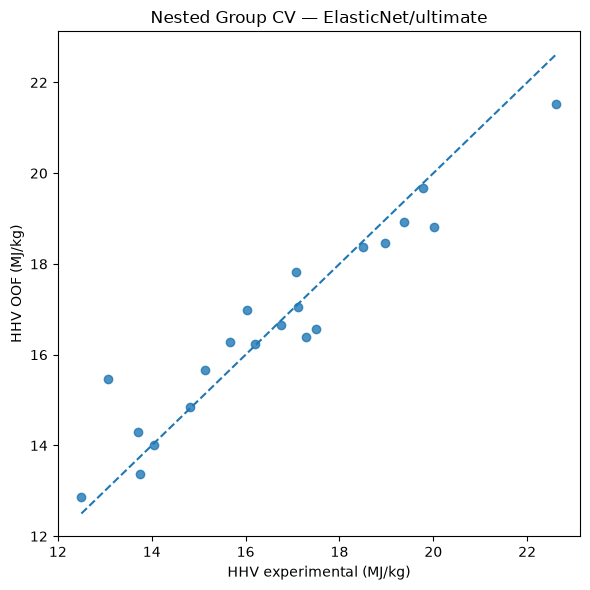

In [16]:
# ============================================================
# FASE 8A — ML HHV: NESTED GROUP CV, MÚLTIPLES MODELOS Y BOOTSTRAP
# ============================================================
display(Markdown("## FASE 8A · Modelos HHV con validación agrupada"))

hhv_model_results=pd.DataFrame(); hhv_oof=pd.DataFrame(); hhv_bootstrap=pd.DataFrame()
if not PACKAGE_STATUS["sklearn"]:
    raise RuntimeError("scikit-learn no instalado")
else:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, RobustScaler
    from sklearn.impute import SimpleImputer
    from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
    from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_score
    from sklearn.linear_model import Ridge, ElasticNet
    from sklearn.cross_decomposition import PLSRegression
    from sklearn.svm import SVR
    from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

    feature_blocks={
        "proximate":["ash_pct","volatile_matter_pct","fixed_carbon_pct"],
        "ultimate":["carbon_pct","hydrogen_pct","oxygen_pct","nitrogen_pct","sulfur_pct"],
        "lignocellulosic":["cellulose_pct","hemicellulose_pct","lignin_total_pct","extractives_pct","ash_pct"],
    }

    def model_library(n_features):
        models={
            "Ridge":(Ridge(),{"model__alpha":np.logspace(-3,3,13)}),
            "ElasticNet":(ElasticNet(max_iter=20000,random_state=SEED),{"model__alpha":np.logspace(-3,1,9),"model__l1_ratio":[.1,.3,.5,.7,.9]}),
            "SVR_RBF":(SVR(),{"model__C":[.3,1,3,10,30],"model__gamma":["scale",.01,.1,1],"model__epsilon":[.05,.1,.25]}),
            "RandomForest":(RandomForestRegressor(n_estimators=800,min_samples_leaf=2,random_state=SEED,n_jobs=-1),{"model__max_features":[.5,1.0],"model__max_depth":[None,3,5]}),
            "ExtraTrees":(ExtraTreesRegressor(n_estimators=800,min_samples_leaf=2,random_state=SEED,n_jobs=-1),{"model__max_features":[.5,1.0],"model__max_depth":[None,3,5]}),
            "GradientBoosting":(GradientBoostingRegressor(random_state=SEED),{"model__n_estimators":[100,300],"model__learning_rate":[.02,.05,.1],"model__max_depth":[1,2,3]}),
        }
        if PACKAGE_STATUS["xgboost"]:
            from xgboost import XGBRegressor
            models["XGBoost"]=(XGBRegressor(n_estimators=500,random_state=SEED,n_jobs=-1,objective="reg:squarederror"),{"model__max_depth":[2,3],"model__learning_rate":[.03,.08],"model__subsample":[.8,1.0],"model__colsample_bytree":[.8,1.0]})
        if PACKAGE_STATUS["catboost"]:
            from catboost import CatBoostRegressor
            models["CatBoost"]=(CatBoostRegressor(verbose=False,random_seed=SEED),{"model__depth":[3,5],"model__learning_rate":[.03,.08],"model__iterations":[300,600]})
        return models



    # Auditoría de la base de medida del HHV. El dataset actual puede mezclar
    # registros dry_basis y registros cuya base no está documentada. Por eso,
    # si no existe una base homogénea con n suficiente, el ML se etiqueta como exploratorio.
    hhv_basis_audit=(comp.loc[comp["hhv_value"].notna() & comp["hhv_unit"].eq("MJ/kg"),"measurement_basis"]
                     .fillna("missing").value_counts(dropna=False).rename_axis("measurement_basis").reset_index(name="n"))
    display(hhv_basis_audit)
    hhv_basis_audit.to_csv(TABLE_DIR/"08a_hhv_measurement_basis_audit.csv",index=False)
    all_results=[]; all_oof=[]
    for block,features in feature_blocks.items():
        hhv=comp.loc[comp["hhv_value"].notna() & comp["hhv_unit"].eq("MJ/kg"),["composition_id","biomass_id","common_name","measurement_basis","hhv_value",*features]].copy()
        # No se imputan valores experimentales: solo se modelan filas completas para el bloque.
        d=hhv.dropna(subset=features+["hhv_value"]).copy()
        n_groups=d["biomass_id"].nunique()
        print(f"Bloque {block}: n={len(d)}, biomasas únicas={n_groups}, features={features}")
        if len(d)<ML_MIN_EXPLORATORY_N or n_groups<5: continue
        X=d[features].astype(float).to_numpy(); y=d["hhv_value"].astype(float).to_numpy(); groups=d["biomass_id"].to_numpy()
        outer=GroupKFold(n_splits=min(5,n_groups)); oof=np.full(len(d),np.nan)
        for model_name,(estimator,param_grid) in model_library(len(features)).items():
            fold_meta=[]; pred=np.full(len(d),np.nan)
            for fold,(tr,te) in enumerate(outer.split(X,y,groups),start=1):
                inner_groups=groups[tr]; inner_n=len(np.unique(inner_groups)); inner=GroupKFold(n_splits=min(4,inner_n))
                pipe=Pipeline([("scale",StandardScaler()),("model",estimator)])
                search=GridSearchCV(pipe,param_grid,cv=inner,scoring="neg_root_mean_squared_error",n_jobs=-1,refit=True)
                search.fit(X[tr],y[tr],groups=inner_groups)
                pred[te]=search.predict(X[te]); fold_meta.append({"fold":fold,"best_params":search.best_params_})
            mae=mean_absolute_error(y,pred); rmse=mean_squared_error(y,pred)**.5; r2=r2_score(y,pred); medae=median_absolute_error(y,pred)
            bases=sorted(d["measurement_basis"].fillna("missing").astype(str).unique().tolist())
            basis_homogeneous=(len(bases)==1 and bases[0]!="unknown" and bases[0]!="missing")
            level="standard" if (len(d)>=ML_MIN_STANDARD_N and basis_homogeneous) else "exploratory"
            all_results.append({"feature_block":block,"model":model_name,"n":len(d),"n_groups":n_groups,
                                "measurement_bases":" | ".join(bases),"analysis_level":level,
                                "mae_oof":mae,"rmse_oof":rmse,"r2_oof":r2,"median_ae_oof":medae,
                                "fold_params":json.dumps(fold_meta,default=str)})
            for ii,pv in enumerate(pred): all_oof.append({"feature_block":block,"model":model_name,"composition_id":int(d.iloc[ii].composition_id),"biomass_id":int(d.iloc[ii].biomass_id),"common_name":d.iloc[ii].common_name,"y_true":y[ii],"y_pred":pv,"residual":y[ii]-pv})
    hhv_model_results=pd.DataFrame(all_results).sort_values("rmse_oof") if all_results else pd.DataFrame(); hhv_oof=pd.DataFrame(all_oof)
    if len(hhv_model_results):
        display(hhv_model_results.drop(columns="fold_params").head(20)); hhv_model_results.to_csv(TABLE_DIR/"08a_hhv_nested_group_cv.csv",index=False); hhv_oof.to_csv(TABLE_DIR/"08a_hhv_oof_predictions.csv",index=False)
        best=hhv_model_results.iloc[0]; best_oof=hhv_oof[(hhv_oof.feature_block==best.feature_block)&(hhv_oof.model==best.model)].copy()
        # Bootstrap por biomasa para IC 95% de métricas.
        groups_unique=best_oof.biomass_id.unique(); boots=[]
        for b in range(ML_BOOTSTRAPS):
            chosen=RNG.choice(groups_unique,size=len(groups_unique),replace=True); sample=pd.concat([best_oof[best_oof.biomass_id==g] for g in chosen],ignore_index=True)
            boots.append({"mae":mean_absolute_error(sample.y_true,sample.y_pred),"rmse":mean_squared_error(sample.y_true,sample.y_pred)**.5,"r2":r2_score(sample.y_true,sample.y_pred) if sample.y_true.nunique()>1 else np.nan})
        hhv_bootstrap=pd.DataFrame(boots)
        ci=pd.DataFrame({"metric":["mae","rmse","r2"],"p2_5":[hhv_bootstrap[c].quantile(.025) for c in ["mae","rmse","r2"]],"median":[hhv_bootstrap[c].median() for c in ["mae","rmse","r2"]],"p97_5":[hhv_bootstrap[c].quantile(.975) for c in ["mae","rmse","r2"]]})
        display(ci); ci.to_csv(TABLE_DIR/"08a_hhv_bootstrap_ci.csv",index=False)
        if PACKAGE_STATUS["matplotlib"]:
            import matplotlib.pyplot as plt
            fig,ax=plt.subplots(figsize=(6,6)); ax.scatter(best_oof.y_true,best_oof.y_pred,alpha=.8); lo=min(best_oof.y_true.min(),best_oof.y_pred.min()); hi=max(best_oof.y_true.max(),best_oof.y_pred.max()); ax.plot([lo,hi],[lo,hi],linestyle="--"); ax.set_xlabel("HHV experimental (MJ/kg)"); ax.set_ylabel("HHV OOF (MJ/kg)"); ax.set_title(f"Nested Group CV — {best.model}/{best.feature_block}"); fig.tight_layout(); fig.savefig(FIG_DIR/"08a_hhv_oof.png",dpi=180,bbox_inches="tight"); plt.show()


In [17]:
# ============================================================
# FASE 8A2 — EXPLICABILIDAD OOF + BASELINE PARA EL MEJOR MODELO HHV
# ============================================================
display(Markdown("## FASE 8A2 · Baseline, importancia de variables y estabilidad"))

hhv_baseline=pd.DataFrame(); hhv_feature_importance=pd.DataFrame()
if len(hhv_model_results):
    from sklearn.inspection import permutation_importance
    best=hhv_model_results.iloc[0]
    features=feature_blocks[str(best.feature_block)]
    d=(comp.loc[comp["hhv_value"].notna() & comp["hhv_unit"].eq("MJ/kg"),["composition_id","biomass_id","common_name","hhv_value",*features]]
       .dropna(subset=features+["hhv_value"]).copy())
    X=d[features].astype(float).to_numpy(); y=d.hhv_value.astype(float).to_numpy(); groups=d.biomass_id.to_numpy()
    outer=GroupKFold(n_splits=min(5,len(np.unique(groups))))
    # Baseline honesta: media del target del TRAIN de cada fold.
    bp=np.full(len(d),np.nan)
    for tr,te in outer.split(X,y,groups): bp[te]=float(np.mean(y[tr]))
    hhv_baseline=pd.DataFrame([{"feature_block":best.feature_block,"n":len(d),"mae":mean_absolute_error(y,bp),"rmse":mean_squared_error(y,bp)**.5,"r2":r2_score(y,bp)}])
    display(hhv_baseline); hhv_baseline.to_csv(TABLE_DIR/"08a2_hhv_baseline.csv",index=False)
    print(f"Mejora RMSE del mejor modelo frente a baseline: {100*(hhv_baseline.rmse.iloc[0]-best.rmse_oof)/hhv_baseline.rmse.iloc[0]:.1f}%")

    # Permutation importance calculada SOLO en los folds externos no vistos.
    estimator,param_grid=model_library(len(features))[str(best.model)]
    imp=[]
    for fold,(tr,te) in enumerate(outer.split(X,y,groups),start=1):
        inner_groups=groups[tr]; inner=GroupKFold(n_splits=min(4,len(np.unique(inner_groups))))
        pipe=Pipeline([("scale",StandardScaler()),("model",estimator)])
        search=GridSearchCV(pipe,param_grid,cv=inner,scoring="neg_root_mean_squared_error",n_jobs=-1,refit=True)
        search.fit(X[tr],y[tr],groups=inner_groups)
        if len(te)>=2:
            pi=permutation_importance(search.best_estimator_,X[te],y[te],scoring="neg_root_mean_squared_error",n_repeats=40,random_state=SEED+fold,n_jobs=-1)
            for f,m,s in zip(features,pi.importances_mean,pi.importances_std): imp.append({"fold":fold,"feature":f,"importance_rmse_degradation":float(m),"sd":float(s)})
    if imp:
        raw=pd.DataFrame(imp); hhv_feature_importance=(raw.groupby("feature").agg(mean_importance=("importance_rmse_degradation","mean"),sd_across_folds=("importance_rmse_degradation","std"),n_folds=("fold","nunique")).reset_index().sort_values("mean_importance",ascending=False))
        hhv_feature_importance.to_csv(TABLE_DIR/"08a2_hhv_permutation_importance_oof.csv",index=False); display(hhv_feature_importance)


## FASE 8A2 · Baseline, importancia de variables y estabilidad

,feature_block,n,mae,rmse,r2
0,ultimate,21,2.33314,2.76358,-0.18030


Mejora RMSE del mejor modelo frente a baseline: 71.1%


,feature,mean_importance,sd_across_folds,n_folds
0,carbon_pct,1.48067,0.71647,5
1,hydrogen_pct,0.14857,0.13968,5
2,nitrogen_pct,0.00090,0.00201,5
3,oxygen_pct,0.00000,0.00000,5
4,sulfur_pct,-0.00922,0.02062,5


## FASE 8B · Y-scrambling con reentrenamiento y diagnóstico de residuos

,test_model,feature_block,observed_rmse,permutations,p_value_one_sided,null_rmse_mean,null_rmse_sd,interpretation
0,Ridge nested GroupCV,ultimate,1.61091,200,0.00498,3.00939,0.93564,Prueba independiente de señal con Ridge; no es...


,n,mean_residual,sd_residual,median_abs_residual,shapiro_p,dagostino_p,spearman_absresid_vs_pred,spearman_heteroscedasticity_p
0,21,-0.01716,0.81764,0.49168,0.10689,0.01881,0.24675,0.28090


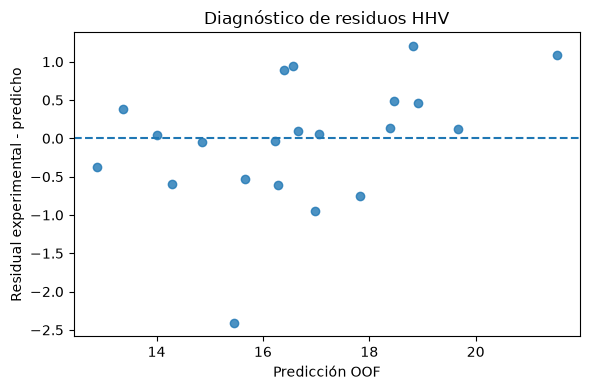

In [18]:
# ============================================================
# FASE 8B — Y-SCRAMBLING CON REENTRENAMIENTO + DIAGNÓSTICO DE RESIDUOS
# ============================================================
display(Markdown("## FASE 8B · Y-scrambling con reentrenamiento y diagnóstico de residuos"))

permutation_result=pd.DataFrame(); residual_stats=pd.DataFrame(); permutation_null=pd.DataFrame()
if len(hhv_model_results):
    best=hhv_model_results.iloc[0]
    features=feature_blocks[str(best.feature_block)]
    d=(comp.loc[comp["hhv_value"].notna() & comp["hhv_unit"].eq("MJ/kg"),["composition_id","biomass_id","hhv_value",*features]]
       .dropna(subset=features+["hhv_value"]).copy())
    X=d[features].astype(float).to_numpy(); y=d.hhv_value.astype(float).to_numpy(); groups=d.biomass_id.to_numpy()
    outer=GroupKFold(n_splits=min(5,len(np.unique(groups))))
    splits=list(outer.split(X,y,groups))

    # Test de señal estable con Ridge. Para cada permutación se vuelve a ajustar el modelo;
    # no se comparan simplemente targets permutados contra predicciones fijas.
    def nested_ridge_rmse(yvec):
        pred=np.full(len(yvec),np.nan)
        for tr,te in splits:
            ig=groups[tr]; inner=GroupKFold(n_splits=min(4,len(np.unique(ig))))
            pipe=Pipeline([("scale",StandardScaler()),("model",Ridge())])
            grid=GridSearchCV(pipe,{"model__alpha":np.logspace(-3,3,13)},cv=inner,scoring="neg_root_mean_squared_error",n_jobs=-1,refit=True)
            grid.fit(X[tr],yvec[tr],groups=ig); pred[te]=grid.predict(X[te])
        return float(mean_squared_error(yvec,pred)**.5),pred

    obs_rmse,ridge_pred=nested_ridge_rmse(y)
    perm=[]
    for b in range(ML_PERMUTATIONS):
        yp=RNG.permutation(y)
        score,_=nested_ridge_rmse(yp); perm.append(score)
    p_perm=(1+sum(v<=obs_rmse for v in perm))/(1+len(perm))
    permutation_result=pd.DataFrame([{
        "test_model":"Ridge nested GroupCV",
        "feature_block":best.feature_block,
        "observed_rmse":obs_rmse,
        "permutations":len(perm),
        "p_value_one_sided":p_perm,
        "null_rmse_mean":np.mean(perm),
        "null_rmse_sd":np.std(perm,ddof=1),
        "interpretation":"Prueba independiente de señal con Ridge; no es el p-valor del modelo seleccionado por mínimo RMSE."
    }])
    permutation_null=pd.DataFrame({"permuted_rmse":perm}); permutation_result.to_csv(TABLE_DIR/"08b_y_scrambling_refit.csv",index=False); permutation_null.to_csv(TABLE_DIR/"08b_y_scrambling_null.csv",index=False)
    display(permutation_result)

    # Residuales del mejor modelo global según OOF de 8A.
    bo=hhv_oof[(hhv_oof.feature_block==best.feature_block)&(hhv_oof.model==best.model)].copy(); resid=bo.y_true-bo.y_pred
    if PACKAGE_STATUS["scipy"]:
        from scipy.stats import shapiro, spearmanr, normaltest
        sh_p=shapiro(resid).pvalue if 3<=len(resid)<=5000 else np.nan
        dag_p=normaltest(resid).pvalue if len(resid)>=8 else np.nan
        rho,phet=spearmanr(np.abs(resid),bo.y_pred) if len(resid)>=8 else (np.nan,np.nan)
    else: sh_p=dag_p=rho=phet=np.nan
    residual_stats=pd.DataFrame([{"n":len(resid),"mean_residual":resid.mean(),"sd_residual":resid.std(ddof=1),"median_abs_residual":np.median(np.abs(resid)),"shapiro_p":sh_p,"dagostino_p":dag_p,"spearman_absresid_vs_pred":rho,"spearman_heteroscedasticity_p":phet}])
    display(residual_stats); residual_stats.to_csv(TABLE_DIR/"08b_residual_diagnostics.csv",index=False)
    if PACKAGE_STATUS["matplotlib"]:
        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(figsize=(6,4)); ax.scatter(bo.y_pred,resid,alpha=.8); ax.axhline(0,linestyle="--"); ax.set_xlabel("Predicción OOF"); ax.set_ylabel("Residual experimental - predicho"); ax.set_title("Diagnóstico de residuos HHV"); fig.tight_layout(); fig.savefig(FIG_DIR/"08b_hhv_residuals.png",dpi=180,bbox_inches="tight"); plt.show()


In [19]:
# ============================================================
# FASE 8C — DATASET MOLECULAR INTEGRADO + ML TARGET-ESPECÍFICO
# ============================================================
display(Markdown("## FASE 8C · ML molecular: combustible + descriptores + cuántica"))

# Descriptores calculados en esta ejecución (2D+3D), evitando duplicados del DB.
desc_current=pd.concat([rdkit_2d_long,rdkit_3d_long],ignore_index=True) if len(rdkit_3d_long) else rdkit_2d_long.copy()
desc_wide=desc_current.pivot_table(index="molecule_id",columns="descriptor_name",values="descriptor_value",aggfunc="last") if len(desc_current) else pd.DataFrame()

# Propiedades cuánticas desde MySQL en formato ancho, separadas por software/método para no mezclar niveles.
qcalc=DB["quantum_calculation"].copy(); qprop=DB["quantum_property"].copy(); quantum_wide=pd.DataFrame()
if len(qcalc) and len(qprop):
    qlong=qprop.merge(qcalc[["calculation_id","molecule_id","software","method","status"]],on="calculation_id",how="left",validate="many_to_one")
    qlong=qlong[qlong.status.isin(["completed","completed_nonminimum"])]
    qlong["feature"]=qlong.software.astype(str)+"|"+qlong.method.astype(str)+"|"+qlong.property_name.astype(str)+" ["+qlong.unit.fillna("unitless").astype(str)+"]"
    quantum_wide=qlong.pivot_table(index="molecule_id",columns="feature",values="value",aggfunc="last")
    quantum_wide.to_csv(TABLE_DIR/"08c_quantum_feature_matrix.csv")

molecular_features=desc_wide.join(quantum_wide,how="outer") if len(quantum_wide) else desc_wide.copy()
molecular_features.to_csv(TABLE_DIR/"08c_molecular_feature_matrix.csv")
print("Matriz molecular:",molecular_features.shape)

# Targets de combustible por propiedad/unidad; se usa mediana por molécula para evitar pseudorreplicación.
target_long=(fuel.groupby(["molecule_id","property_name","unit_std"],dropna=False)["value_std"].median().reset_index())
readiness=[]; molecular_ml_results=[]; molecular_ml_oof=[]
for (prop,unit),tg in target_long.groupby(["property_name","unit_std"],dropna=False):
    ids=set(tg.molecule_id.astype(int)) & set(molecular_features.index.astype(int))
    n=len(ids); level="standard" if n>=ML_MIN_STANDARD_N else ("exploratory" if n>=ML_MIN_EXPLORATORY_N else "insufficient")
    readiness.append({"target":prop,"unit":unit,"n_molecules":n,"ml_level":level})
    if n<ML_MIN_EXPLORATORY_N: continue
    d=tg[tg.molecule_id.isin(ids)].set_index("molecule_id").join(molecular_features,how="inner")
    y=d["value_std"].astype(float); X=d.drop(columns=["property_name","unit_std","value_std"],errors="ignore").replace([np.inf,-np.inf],np.nan)
    # No se imputan features: se conservan solo columnas completas en estas moléculas.
    X=X.loc[:,X.notna().all(axis=0)]; X=X.loc[:,X.nunique()>1]
    if X.shape[1]<2: continue
    k=min(12,max(2,n//2),X.shape[1])
    from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict
    from sklearn.feature_selection import SelectKBest, f_regression
    models={
        "Ridge":Pipeline([("scale",StandardScaler()),("select",SelectKBest(f_regression,k=k)),("model",Ridge(alpha=1.0))]),
        "PLS":Pipeline([("scale",StandardScaler()),("model",PLSRegression(n_components=min(3,k,n-2)))]),
        "SVR":Pipeline([("scale",StandardScaler()),("select",SelectKBest(f_regression,k=k)),("model",SVR(C=3,gamma="scale",epsilon=.1))]),
        "ExtraTrees":Pipeline([("select",SelectKBest(f_regression,k=k)),("model",ExtraTreesRegressor(n_estimators=800,min_samples_leaf=2,random_state=SEED,n_jobs=-1))]),
    }
    cv=LeaveOneOut() if n<30 else KFold(n_splits=5,shuffle=True,random_state=SEED)
    for name,model in models.items():
        try:
            pred=np.asarray(cross_val_predict(model,X,y,cv=cv,n_jobs=-1)).ravel()
            molecular_ml_results.append({"target":prop,"unit":unit,"n":n,"level":level,"model":name,"n_features_available":X.shape[1],"selected_k":k,"mae":mean_absolute_error(y,pred),"rmse":mean_squared_error(y,pred)**.5,"r2":r2_score(y,pred)})
            for mid,yt,yp in zip(X.index,y,pred): molecular_ml_oof.append({"target":prop,"unit":unit,"model":name,"molecule_id":int(mid),"y_true":yt,"y_pred":yp,"residual":yt-yp,"level":level})
        except Exception as e:
            molecular_ml_results.append({"target":prop,"unit":unit,"n":n,"level":level,"model":name,"n_features_available":X.shape[1],"selected_k":k,"mae":np.nan,"rmse":np.nan,"r2":np.nan,"error":repr(e)})

readiness=pd.DataFrame(readiness).sort_values("n_molecules",ascending=False); molecular_ml_results=pd.DataFrame(molecular_ml_results); molecular_ml_oof=pd.DataFrame(molecular_ml_oof)
display(readiness)
if len(molecular_ml_results):
    display(molecular_ml_results.sort_values(["target","rmse"])); molecular_ml_results.to_csv(TABLE_DIR/"08c_molecular_ml_metrics.csv",index=False); molecular_ml_oof.to_csv(TABLE_DIR/"08c_molecular_ml_oof.csv",index=False)
readiness.to_csv(TABLE_DIR/"08c_molecular_ml_readiness.csv",index=False)


## FASE 8C · ML molecular: combustible + descriptores + cuántica

Matriz molecular: (18, 264)


,target,unit,n_molecules,ml_level
0,boiling_point,°C,6,insufficient
7,specific_energy,MJ/kg,3,insufficient
4,lower_heating_value,MJ/kg,2,insufficient
1,density,kg/m3,2,insufficient
6,octane_number,NaN,2,insufficient
2,energy_density,MJ/L,1,insufficient
3,flash_point,°C,0,insufficient
5,melting_point,°C,0,insufficient


In [21]:
# ============================================================
# FASE 8D — SURROGATE ML CUÁNTICO: RDKit -> PROPIEDADES ORCA/xTB
# ============================================================
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
display(Markdown("## FASE 8D · Modelos surrogate de propiedades cuánticas"))

quantum_surrogate_metrics=[]
if len(qcalc) and len(qprop) and len(desc_wide):
    qlong=qprop.merge(qcalc[["calculation_id","molecule_id","software","method","status"]],on="calculation_id",how="left")
    targets=qlong[qlong.property_name.isin(["homo_lumo_gap","dipole_moment"]) & qlong.status.isin(["completed","completed_nonminimum"])].copy()
    for (software,method,pname,unit),tg in targets.groupby(["software","method","property_name","unit"],dropna=False):
        tg=tg.groupby("molecule_id")["value"].last(); ids=tg.index.intersection(desc_wide.index); n=len(ids)
        if n<ML_MIN_EXPLORATORY_N: continue
        X=desc_wide.loc[ids].replace([np.inf,-np.inf],np.nan); X=X.loc[:,X.notna().all(axis=0)]; X=X.loc[:,X.nunique()>1]; y=tg.loc[ids].astype(float)
        k=min(10,max(2,n//2),X.shape[1]); cv=LeaveOneOut() if n<30 else KFold(n_splits=5,shuffle=True,random_state=SEED)
        model=Pipeline([("scale",StandardScaler()),("select",SelectKBest(f_regression,k=k)),("model",Ridge(alpha=1.0))])
        pred=np.asarray(cross_val_predict(model,X,y,cv=cv,n_jobs=-1)).ravel()
        quantum_surrogate_metrics.append({"software":software,"method":method,"target":pname,"unit":unit,"n":n,"mae":mean_absolute_error(y,pred),"rmse":mean_squared_error(y,pred)**.5,"r2":r2_score(y,pred),"interpretation":"exploratory" if n<ML_MIN_STANDARD_N else "standard"})
quantum_surrogate_metrics=pd.DataFrame(quantum_surrogate_metrics)
if len(quantum_surrogate_metrics): display(quantum_surrogate_metrics); quantum_surrogate_metrics.to_csv(TABLE_DIR/"08d_quantum_surrogate_metrics.csv",index=False)
else: print("No hay todavía un target cuántico con suficiente n para surrogate ML; el cuaderno no fabrica un modelo.")


## FASE 8D · Modelos surrogate de propiedades cuánticas

,software,method,target,unit,n,mae,rmse,r2,interpretation
0,ORCA,R2SCAN-3C,dipole_moment,Debye,18,0.73688,1.03475,0.43415,exploratory
1,ORCA,wB97X-3c,dipole_moment,Debye,18,0.73331,1.04176,0.46370,exploratory
2,ORCA,wB97X-3c,homo_lumo_gap,eV,18,0.35725,0.44929,0.87428,exploratory
3,xTB,GFN2-xTB,dipole_moment,Debye,18,2.70401,3.78461,-0.31104,exploratory
4,xTB,GFN2-xTB,homo_lumo_gap,eV,18,0.66184,0.85553,0.95064,exploratory


In [22]:
# ============================================================
# FASE 8E — ML DE RENDIMIENTO DE REACCIÓN SIN VARIABLES DE FUGA
# ============================================================
display(Markdown("## FASE 8E · Predicción exploratoria de yield de reacción"))

reaction_ml_results=pd.DataFrame(); reaction_ml_oof=pd.DataFrame()
rx=DB["reaction"].copy()
# Deliberadamente NO se usan conversion_pct ni selectivity_pct como features: podrían codificar directamente el yield.
num_features=["temperature_c","pressure_bar","reaction_time_h","trl"]
cat_features=["reaction_class","reactor_type"]
d=rx.dropna(subset=["yield_pct",*num_features,*cat_features,"source_id"]).copy()
n_sources=d.source_id.nunique()
print("Reacciones completas para ML yield:",len(d),"| fuentes independientes:",n_sources)
if len(d)>=ML_MIN_EXPLORATORY_N and n_sources>=5:
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.base import clone
    X=d[num_features+cat_features].copy(); y=d.yield_pct.astype(float).to_numpy(); groups=d.source_id.to_numpy()
    pre=ColumnTransformer([("num",StandardScaler(),num_features),("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat_features)],remainder="drop")
    models={
        "Ridge":(Ridge(),{"model__alpha":np.logspace(-3,3,13)}),
        "RandomForest":(RandomForestRegressor(n_estimators=800,min_samples_leaf=2,random_state=SEED,n_jobs=-1),{"model__max_features":[.5,1.0],"model__max_depth":[None,3,5]}),
        "ExtraTrees":(ExtraTreesRegressor(n_estimators=800,min_samples_leaf=2,random_state=SEED,n_jobs=-1),{"model__max_features":[.5,1.0],"model__max_depth":[None,3,5]}),
        "GradientBoosting":(GradientBoostingRegressor(random_state=SEED),{"model__n_estimators":[100,300],"model__learning_rate":[.02,.05,.1],"model__max_depth":[1,2,3]}),
    }
    outer=GroupKFold(n_splits=min(5,n_sources)); rows=[]; preds=[]
    for name,(est,grid_params) in models.items():
        pred=np.full(len(d),np.nan); fold_params=[]
        for fold,(tr,te) in enumerate(outer.split(X,y,groups),start=1):
            inner_g=groups[tr]; inner=GroupKFold(n_splits=min(4,len(np.unique(inner_g))))
            pipe=Pipeline([("pre",pre),("model",est)])
            search=GridSearchCV(pipe,grid_params,cv=inner,scoring="neg_root_mean_squared_error",n_jobs=-1,refit=True)
            search.fit(X.iloc[tr],y[tr],groups=inner_g); pred[te]=search.predict(X.iloc[te]); fold_params.append(search.best_params_)
        rows.append({"model":name,"n":len(d),"n_sources":n_sources,"mae_oof":mean_absolute_error(y,pred),"rmse_oof":mean_squared_error(y,pred)**.5,"r2_oof":r2_score(y,pred),"level":"standard" if len(d)>=ML_MIN_STANDARD_N else "exploratory","fold_params":json.dumps(fold_params,default=str)})
        for j,pv in enumerate(pred): preds.append({"model":name,"reaction_id":int(d.iloc[j].reaction_id),"source_id":int(d.iloc[j].source_id),"y_true":y[j],"y_pred":pv,"residual":y[j]-pv})
    reaction_ml_results=pd.DataFrame(rows).sort_values("rmse_oof"); reaction_ml_oof=pd.DataFrame(preds)
    reaction_ml_results.to_csv(TABLE_DIR/"08e_reaction_yield_ml.csv",index=False); reaction_ml_oof.to_csv(TABLE_DIR/"08e_reaction_yield_oof.csv",index=False)
    display(reaction_ml_results.drop(columns="fold_params"))
else:
    print("No se ejecuta ML de yield: tamaño/fuentes insuficientes. Esto evita métricas poco defendibles.")


## FASE 8E · Predicción exploratoria de yield de reacción

Reacciones completas para ML yield: 0 | fuentes independientes: 0
No se ejecuta ML de yield: tamaño/fuentes insuficientes. Esto evita métricas poco defendibles.


## FASE 9 · Red de transformación química

,molecule_id,preferred_name,role,in_degree,out_degree,pagerank,betweenness
5,6,furfural,platform_molecule,1,2,0.01026,0.00007
2,3,5-hydroxymethylfurfural,platform_molecule,1,1,0.01026,0.00003
13,14,gamma-valerolactone,fuel_candidate,2,0,0.01497,0.00000
14,15,"2,5-dimethylfuran",fuel_candidate,1,0,0.01426,0.00000
12,13,cyclohexane,fuel_candidate,1,0,0.01026,0.00000
6,7,furfuryl alcohol,intermediate,1,0,0.00990,0.00000
7,8,2-methylfuran,fuel_candidate,1,0,0.00990,0.00000
0,1,D-glucose,platform_molecule,0,1,0.00554,0.00000
1,2,D-xylose,platform_molecule,0,1,0.00554,0.00000
3,4,levulinic acid,platform_molecule,0,1,0.00554,0.00000


Bipartito nodos/aristas: 255 164 | proyección molecular: 173 8 | componentes débiles: 165


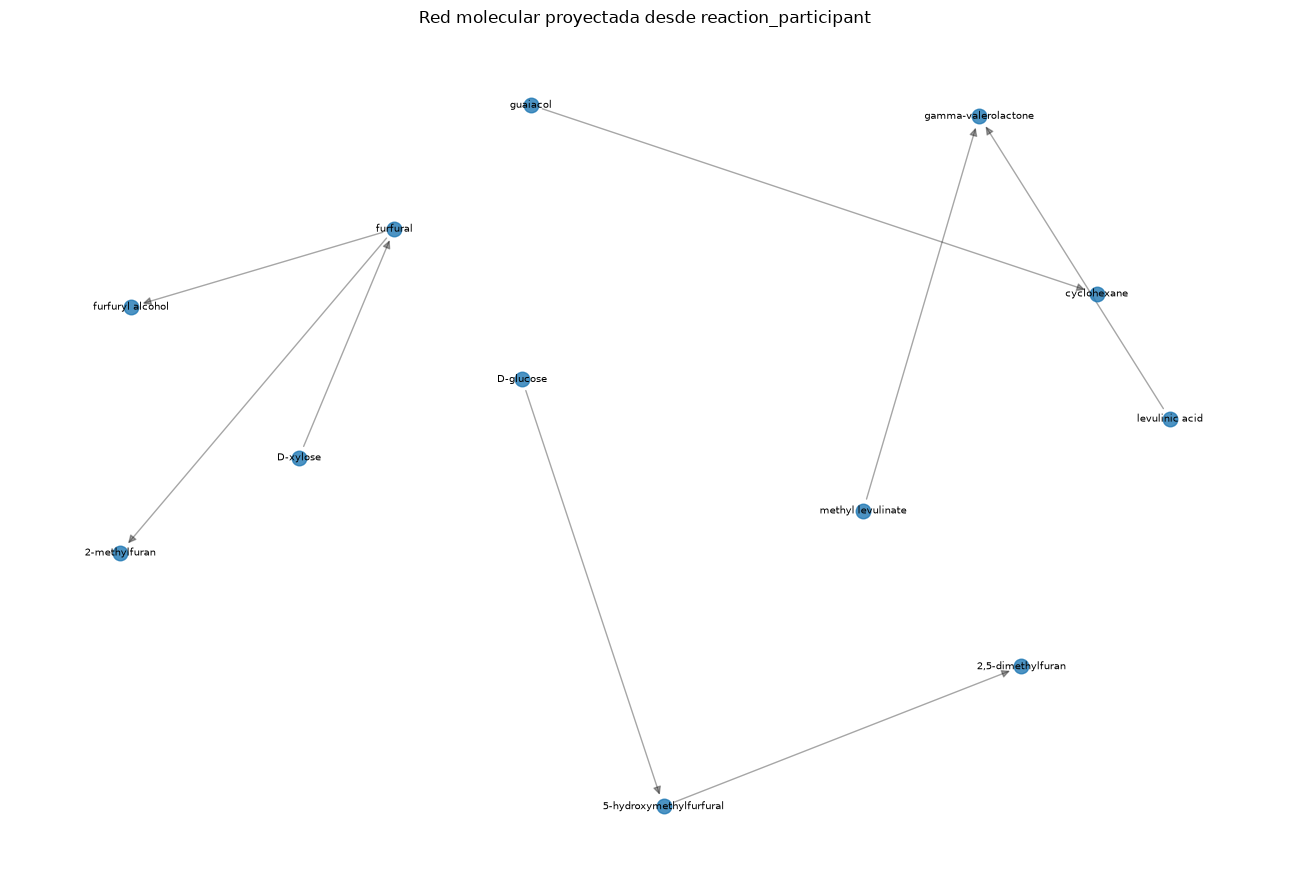

In [23]:
# ============================================================
# FASE 9 — NETWORKX AVANZADO: GRAFO BIPARTITO + PROYECCIÓN MOLECULAR
# ============================================================
display(Markdown("## FASE 9 · Red de transformación química"))

reaction_edges=pd.DataFrame(); network_metrics=pd.DataFrame(); G=None; B=None
if not PACKAGE_STATUS["networkx"]:
    raise RuntimeError("NetworkX no instalado")
else:
    import networkx as nx
    rp=DB["reaction_participant"].copy(); reactions=DB["reaction"].copy(); reaction_map=reactions.set_index("reaction_id").to_dict("index")
    # Grafo bipartito conserva explícitamente los nodos reacción y evita perder estequiometría.
    B=nx.DiGraph()
    for r in molecules.itertuples(index=False): B.add_node(f"M{int(r.molecule_id)}",kind="molecule",molecule_id=int(r.molecule_id),name=r.preferred_name,role=r.molecule_role)
    for r in reactions.itertuples(index=False): B.add_node(f"R{int(r.reaction_id)}",kind="reaction",reaction_id=int(r.reaction_id),name=r.reaction_name,reaction_class=r.reaction_class)
    for p in rp.itertuples(index=False):
        role=str(p.participant_role).lower(); mid=f"M{int(p.molecule_id)}"; rid=f"R{int(p.reaction_id)}"
        attrs={"participant_id":int(p.participant_id),"role":role,"stoich":p.stoichiometric_coefficient}
        if role=="reactant": B.add_edge(mid,rid,**attrs)
        elif role=="product": B.add_edge(rid,mid,**attrs)
        else: B.add_edge(mid,rid,**attrs)

    edge_rows=[]
    for rid,g in rp.groupby("reaction_id"):
        reactants=g[g.participant_role.astype(str).str.lower().eq("reactant")].molecule_id.astype(int).tolist(); products=g[g.participant_role.astype(str).str.lower().eq("product")].molecule_id.astype(int).tolist()
        rr=reaction_map[int(rid)]
        for a in reactants:
            for b in products:
                edge_rows.append({"reactant_id":a,"product_id":b,"reaction_id":int(rid),"reaction_name":rr["reaction_name"],"reaction_class":rr["reaction_class"],"temperature_c":rr["temperature_c"],"pressure_bar":rr["pressure_bar"],"reaction_time_h":rr["reaction_time_h"],"yield_pct":rr["yield_pct"],"conversion_pct":rr["conversion_pct"],"selectivity_pct":rr["selectivity_pct"],"trl":rr["trl"],"source_id":rr["source_id"]})
    reaction_edges=pd.DataFrame(edge_rows); reaction_edges.to_csv(TABLE_DIR/"09_reaction_edges.csv",index=False)
    G=nx.DiGraph();
    for r in molecules.itertuples(index=False): G.add_node(int(r.molecule_id),name=r.preferred_name,role=r.molecule_role)
    for e in reaction_edges.itertuples(index=False): G.add_edge(int(e.reactant_id),int(e.product_id))
    pr=nx.pagerank(G) if G.number_of_edges() else {}; btw=nx.betweenness_centrality(G) if G.number_of_edges() else {}
    network_metrics=pd.DataFrame([{"molecule_id":n,"preferred_name":G.nodes[n].get("name"),"role":G.nodes[n].get("role"),"in_degree":G.in_degree(n),"out_degree":G.out_degree(n),"pagerank":pr.get(n,0),"betweenness":btw.get(n,0)} for n in G.nodes]).sort_values(["betweenness","pagerank"],ascending=False)
    network_metrics.to_csv(TABLE_DIR/"09_network_metrics.csv",index=False); display(network_metrics.head(25))
    print("Bipartito nodos/aristas:",B.number_of_nodes(),B.number_of_edges(),"| proyección molecular:",G.number_of_nodes(),G.number_of_edges(),"| componentes débiles:",nx.number_weakly_connected_components(G))
    if PACKAGE_STATUS["matplotlib"] and G.number_of_edges():
        import matplotlib.pyplot as plt
        active=set(reaction_edges.reactant_id)|set(reaction_edges.product_id); H=G.subgraph(active).copy(); pos=nx.spring_layout(H,seed=SEED,k=1.2)
        fig,ax=plt.subplots(figsize=(13,9)); nx.draw_networkx_edges(H,pos,ax=ax,alpha=.35,arrows=True,arrowsize=12); nx.draw_networkx_nodes(H,pos,ax=ax,node_size=110,alpha=.8); labels={n:H.nodes[n]["name"] for n in H.nodes}; nx.draw_networkx_labels(H,pos,labels=labels,font_size=7,ax=ax); ax.axis("off"); ax.set_title("Red molecular proyectada desde reaction_participant"); fig.tight_layout(); fig.savefig(FIG_DIR/"09_reaction_network.png",dpi=180,bbox_inches="tight"); plt.show()


In [24]:
# ============================================================
# FASE 10 — RUTAS BIOMASA→COMBUSTIBLE + NON-DOMINATED SORTING + CROWDING
# ============================================================
display(Markdown("## FASE 10 · Optimización multiobjetivo de rutas: Pareto rank y crowding distance"))

route_table=pd.DataFrame(); route_candidates=pd.DataFrame(); route_pareto=pd.DataFrame(); route_pareto_quantum=pd.DataFrame()

def nondominated_sort(df, maximize, minimize):
    if df.empty: return pd.Series(dtype=int,index=df.index)
    cols=maximize+minimize; X=np.column_stack([*(-df[c].to_numpy(float) for c in maximize),*(df[c].to_numpy(float) for c in minimize)])
    n=len(X); domination_count=np.zeros(n,int); dominates=[[] for _ in range(n)]; fronts=[[]]
    for p in range(n):
        for q in range(n):
            if p==q: continue
            pdom=np.all(X[p]<=X[q]) and np.any(X[p]<X[q]); qdom=np.all(X[q]<=X[p]) and np.any(X[q]<X[p])
            if pdom: dominates[p].append(q)
            elif qdom: domination_count[p]+=1
        if domination_count[p]==0: fronts[0].append(p)
    rank=np.zeros(n,int); current=0
    while current<len(fronts) and fronts[current]:
        nxt=[]
        for p in fronts[current]:
            rank[p]=current+1
            for q in dominates[p]:
                domination_count[q]-=1
                if domination_count[q]==0: nxt.append(q)
        if nxt: fronts.append(nxt)
        current+=1
    return pd.Series(rank,index=df.index)

def crowding_distance(df, maximize, minimize, rank_col="pareto_rank"):
    dist=pd.Series(0.0,index=df.index)
    for rank,g in df.groupby(rank_col):
        if len(g)<=2:
            dist.loc[g.index]=np.inf; continue
        for c in maximize+minimize:
            order=g[c].sort_values().index; lo=float(g.loc[order[0],c]); hi=float(g.loc[order[-1],c])
            dist.loc[order[0]]=np.inf; dist.loc[order[-1]]=np.inf
            if hi==lo: continue
            for j in range(1,len(order)-1):
                if np.isfinite(dist.loc[order[j]]): dist.loc[order[j]] += (float(g.loc[order[j+1],c])-float(g.loc[order[j-1],c]))/(hi-lo)
    return dist

if reaction_edges.empty:
    print("No hay aristas de reacción suficientes.")
else:
    # Añadir energética cuántica por reacción si está disponible.
    rqmap={}
    if isinstance(reaction_quantum_energetics,pd.DataFrame) and len(reaction_quantum_energetics):
        rqmap=reaction_quantum_energetics.set_index("reaction_id")[["delta_E_wB97X3c_kJ_mol","delta_G_r2SCAN3c_298K_kJ_mol"]].to_dict("index")
    adj={}
    for r in reaction_edges.itertuples(index=False): adj.setdefault(int(r.reactant_id),[]).append(r)
    fuel_ids=set(molecules.loc[molecules.molecule_role.eq("fuel_candidate"),"molecule_id"].astype(int)); mol_name=molecules.set_index("molecule_id").preferred_name.to_dict(); MAX_STEPS=6
    def enumerate_routes(start,max_steps=MAX_STEPS):
        routes=[]
        def dfs(node,path,edges):
            if edges and node in fuel_ids: routes.append((path.copy(),edges.copy()))
            if len(edges)>=max_steps:return
            for e in adj.get(node,[]):
                nxt=int(e.product_id)
                if nxt not in path: dfs(nxt,path+[nxt],edges+[e])
        dfs(int(start),[int(start)],[]); return routes
    links=(DB["biomass_molecule"].merge(biomass[["biomass_id","common_name"]],on="biomass_id",how="left").merge(molecules[["molecule_id","preferred_name"]],on="molecule_id",how="left"))
    rows=[]
    for link in links.itertuples(index=False):
        for path,edges in enumerate_routes(int(link.molecule_id)):
            y=[e.yield_pct for e in edges]; y_complete=all(pd.notna(v) for v in y); route_y=100*np.prod([float(v)/100 for v in y]) if y_complete else np.nan
            temp=[e.temperature_c for e in edges if pd.notna(e.temperature_c)]; press=[e.pressure_bar for e in edges if pd.notna(e.pressure_bar)]; times=[e.reaction_time_h for e in edges if pd.notna(e.reaction_time_h)]; trls=[e.trl for e in edges if pd.notna(e.trl)]
            qrows=[rqmap.get(int(e.reaction_id),{}) for e in edges]
            dE=[q.get("delta_E_wB97X3c_kJ_mol",np.nan) for q in qrows]; dG=[q.get("delta_G_r2SCAN3c_298K_kJ_mol",np.nan) for q in qrows]
            rows.append({"biomass_molecule_id":int(link.biomass_molecule_id),"biomass_id":int(link.biomass_id),"biomass_name":link.common_name,"start_molecule_id":int(link.molecule_id),"start_molecule":link.preferred_name,"fuel_molecule_id":int(path[-1]),"fuel_molecule":mol_name.get(int(path[-1])),"steps":len(edges),"molecule_path_ids":" -> ".join(map(str,path)),"molecule_path":" -> ".join(mol_name.get(i,str(i)) for i in path),"reaction_ids":",".join(str(int(e.reaction_id)) for e in edges),"route_yield_pct":route_y,"yield_complete":y_complete,"max_temperature_c":max(temp) if temp else np.nan,"max_pressure_bar":max(press) if press else np.nan,"total_time_h":sum(times) if times else np.nan,"pressure_missing_steps":sum(pd.isna(e.pressure_bar) for e in edges),"time_missing_steps":sum(pd.isna(e.reaction_time_h) for e in edges),"min_trl_known":min(trls) if trls else np.nan,"n_reaction_sources":len(set(int(e.source_id) for e in edges)),"route_delta_E_wB97X3c_kJ_mol":sum(dE) if dE and all(pd.notna(v) for v in dE) else np.nan,"route_delta_G_r2SCAN3c_298K_kJ_mol":sum(dG) if dG and all(pd.notna(v) for v in dG) else np.nan})
    route_table=pd.DataFrame(rows)
    if len(route_table):
        group_cols=[c for c in route_table.columns if c not in ["biomass_molecule_id"]]
        route_candidates=route_table.groupby(group_cols,dropna=False).agg(n_biomass_evidences=("biomass_molecule_id","nunique")).reset_index(); route_candidates.insert(0,"route_id",range(1,len(route_candidates)+1))
        eligible_routes=route_candidates[route_candidates.yield_complete & route_candidates.max_temperature_c.notna()].copy()
        if len(eligible_routes):
            max_obj=["route_yield_pct","n_reaction_sources","n_biomass_evidences"]
            min_obj=["steps","max_temperature_c","pressure_missing_steps","time_missing_steps"]
            eligible_routes["pareto_rank"]=nondominated_sort(eligible_routes,max_obj,min_obj)
            eligible_routes["crowding_distance"]=crowding_distance(eligible_routes,max_obj,min_obj)
            route_candidates=route_candidates.merge(eligible_routes[["route_id","pareto_rank","crowding_distance"]],on="route_id",how="left")
            route_pareto=eligible_routes[eligible_routes.pareto_rank.eq(1)].sort_values(["crowding_distance","route_yield_pct"],ascending=[False,False])
            # Subanálisis con termodinámica DFT: solo rutas con ΔG completo.
            qelig=eligible_routes.dropna(subset=["route_delta_G_r2SCAN3c_298K_kJ_mol"]).copy()
            if len(qelig)>=2:
                qelig["pareto_rank_quantum"]=nondominated_sort(qelig,max_obj,min_obj+["route_delta_G_r2SCAN3c_298K_kJ_mol"])
                qelig["crowding_quantum"]=crowding_distance(qelig,max_obj,min_obj+["route_delta_G_r2SCAN3c_298K_kJ_mol"],rank_col="pareto_rank_quantum")
                route_pareto_quantum=qelig[qelig.pareto_rank_quantum.eq(1)].sort_values("crowding_quantum",ascending=False)
        route_table.to_csv(TABLE_DIR/"10_route_evidence.csv",index=False); route_candidates.to_csv(TABLE_DIR/"10_route_candidates.csv",index=False); route_pareto.to_csv(TABLE_DIR/"10_route_pareto.csv",index=False); route_pareto_quantum.to_csv(TABLE_DIR/"10_route_pareto_quantum.csv",index=False)
        display(route_pareto.head(50))
        if len(route_pareto_quantum):
            display(Markdown("### Frente Pareto con ΔG DFT disponible")); display(route_pareto_quantum.head(50))
        print("Evidencias:",len(route_table),"| rutas únicas:",len(route_candidates),"| Pareto base:",len(route_pareto),"| Pareto cuántico:",len(route_pareto_quantum))


## FASE 10 · Optimización multiobjetivo de rutas: Pareto rank y crowding distance

,route_id,biomass_id,biomass_name,start_molecule_id,start_molecule,fuel_molecule_id,fuel_molecule,steps,molecule_path_ids,molecule_path,reaction_ids,route_yield_pct,yield_complete,max_temperature_c,max_pressure_bar,total_time_h,pressure_missing_steps,time_missing_steps,min_trl_known,n_reaction_sources,route_delta_E_wB97X3c_kJ_mol,route_delta_G_r2SCAN3c_298K_kJ_mol,n_biomass_evidences,pareto_rank,crowding_distance
18,19,4,corn stover,2,D-xylose,8,2-methylfuran,2,2 -> 6 -> 8,D-xylose -> furfural -> 2-methylfuran,"2,4",85.19280,True,180.00000,20.00000,0.25000,1,1,NaN,2,NaN,NaN,4,1,inf
13,14,4,corn stover,1,D-glucose,15,"2,5-dimethylfuran",2,1 -> 3 -> 15,"D-glucose -> 5-hydroxymethylfurfural -> 2,5-di...","1,78",71.00000,True,140.00000,10.00000,2.00833,1,0,NaN,2,NaN,NaN,4,1,inf


Evidencias: 109 | rutas únicas: 55 | Pareto base: 2 | Pareto cuántico: 0


In [25]:
# ============================================================
# FASE 11 — SÍNTESIS AUTOMÁTICA PARA MEMORIA / DEFENSA
# ============================================================
display(Markdown("## FASE 11 · Síntesis, tablas, figuras y texto reproducible"))

lines=[]
lines += ["# Resultados reproducibles — TFM SAF","",f"Fecha: {datetime.now().isoformat(timespec='seconds')}",f"Python {platform.python_version()} | MySQL {mysql_version} | config {CONFIG_HASH}",""]
lines += ["## 1. Integridad del dataset",f"- Fuentes: {len(DB['source'])}",f"- Biomasas residuales registradas: {len(DB['biomass'])}",f"- Mediciones de composición: {len(DB['biomass_composition'])}",f"- Moléculas: {len(DB['molecule'])}",f"- Reacciones: {len(DB['reaction'])}",f"- Participantes de reacción: {len(DB['reaction_participant'])}",f"- Propiedades de combustible: {len(DB['fuel_property'])}",f"- Fallos críticos de integridad: {len(critical_failures)}",""]
lines += ["## 2. Biomasa y estadística",f"- Registros de composición en dry_basis: {len(comp_dry)}",f"- Outliers robustos marcados (no eliminados): {len(outliers)}",f"- Alternativas del frente Pareto bioquímico: {len(bio_front)}",f"- Alternativas del frente Pareto termoquímico: {len(thermo_front)}",""]
lines += ["## 3. Química molecular",f"- Moléculas con SMILES: {len(rdkit_input)} / {len(molecules)}",f"- Descriptores RDKit 2D distintos: {rdkit_2d_long.descriptor_name.nunique() if len(rdkit_2d_long) else 0}",f"- Moléculas con conformero 3D válido: {int((conformer_summary.status=='ok').sum()) if len(conformer_summary) else 0}",""]
lines += ["## 4. Química cuántica",f"- Modo de ejecución: {QUANTUM_MODE}",f"- xTB terminados/minimos: {int(xtb_results.status.isin(['completed','completed_nonminimum']).sum()) if len(xtb_results) else 0} / {int((xtb_results.status=='completed').sum()) if len(xtb_results) else 0}",f"- ORCA terminados/mínimos: {int(orca_results.status.isin(['completed','completed_nonminimum']).sum()) if len(orca_results) else 0} / {int((orca_results.status=='completed').sum()) if len(orca_results) else 0}",f"- Registros quantum_calculation en MySQL: {len(DB['quantum_calculation'])}",f"- Registros quantum_property en MySQL: {len(DB['quantum_property'])}",""]
if len(orca_results) and (orca_results.status=="failed").any():
    lines += ["- ORCA presentó cálculos fallidos; revisar `07c_orca_results.csv` y los archivos `.stderr.txt` antes de interpretar DFT.",""]
lines += ["## 5. Machine Learning"]
if len(hhv_model_results):
    b=hhv_model_results.iloc[0]
    lines += [f"- Mejor combinación HHV por RMSE OOF: {b['model']} / {b['feature_block']}",
              f"- Nivel de interpretación: {b.get('analysis_level','exploratory')}. Bases de medida: {b.get('measurement_bases','no auditadas')}.",
              f"- n={int(b['n'])}, MAE={b['mae_oof']:.3f} MJ/kg, RMSE={b['rmse_oof']:.3f} MJ/kg, R²={b['r2_oof']:.3f}."]
    if len(permutation_result):
        pr=permutation_result.iloc[0]
        lines += [f"- Y-scrambling ({pr['test_model']}, prueba independiente de señal): p={pr['p_value_one_sided']:.4f}."]
else: lines += ["- No hubo un bloque HHV con tamaño mínimo suficiente en esta ejecución."]
lines += [f"- Targets moleculares con modelo ejecutado: {molecular_ml_results['target'].nunique() if len(molecular_ml_results) else 0}",""]
lines += ["## 6. Red y optimización",f"- Aristas moleculares: {len(reaction_edges)}",f"- Rutas biomasa→combustible: {len(route_candidates)}",f"- Soluciones Pareto: {len(route_pareto)}",""]
lines += ["## 7. Limitaciones que deben declararse", "- Las moléculas sin SMILES no pueden entrar en RDKit/xTB/ORCA hasta que su estructura se documente con una fuente fiable.", "- Muchos targets de combustible siguen teniendo pocas moléculas: los modelos de bajo n son exploratorios y no equivalen a validación externa.", "- HOMO/LUMO y energías dependen del nivel teórico; no son observables experimentales exactos.", "- Las frecuencias imaginarias se usan como control de mínimo; un cálculo `completed_nonminimum` no debe usarse como geometría de equilibrio definitiva.", "- No se multiplican rendimientos cuya unidad o base no sean comparables.", "- El modelo HHV es exploratorio si mezcla bases de medida desconocidas/no homogéneas o si el tamaño muestral es <30."]

summary_md="\n".join(lines); (REPORT_DIR/"RESULTADOS_TFM.md").write_text(summary_md,encoding="utf-8"); display(Markdown(summary_md))

# Métodos listos para adaptar a la memoria.
methods=f"""# Metodología computacional reproducible\n\nEl análisis se ejecutó con Python {platform.python_version()} y MySQL {mysql_version}. La integridad referencial se verificó antes de cualquier cálculo. Los descriptores moleculares se calcularon con RDKit a partir de SMILES documentados. Los conformeros se generaron con ETKDGv3 y se optimizaron con MMFF94 cuando existían parámetros, o UFF en caso contrario. Se generó un ensemble conformacional y se seleccionó la geometría de menor energía del campo de fuerza para la etapa cuántica.\n\nLas geometrías se preoptimizaron con GFN2-xTB, optimización `{XTB_OPT_LEVEL}`, seguida de Hessiano para control vibracional y termoquímica. Las geometrías xTB se emplearon como entrada de ORCA. La optimización DFT se realizó con {ORCA_GEOM_METHOD}, seguida de frecuencias a {THERMO_TEMPERATURE_K} K; cuando estaba activado, se calculó un single point adicional con {ORCA_REFINEMENT_METHOD}. Los resultados se consideraron mínimos cuando no presentaban frecuencias imaginarias significativas por debajo de {IMAG_FREQ_THRESHOLD_CM1} cm-1.\n\nLos modelos de HHV utilizaron validación cruzada anidada agrupada por biomass_id para reducir fuga de información entre mediciones de una misma biomasa. Se compararon modelos lineales regularizados, kernel y ensembles; las predicciones reportadas son out-of-fold. La incertidumbre de las métricas se estimó mediante bootstrap por grupos y se realizó Y-scrambling como control frente a asociaciones espurias. Los modelos moleculares solo se ejecutaron cuando el tamaño muestral superó el umbral mínimo predefinido.\n"""
(REPORT_DIR/"METODOLOGIA_TFM.md").write_text(methods,encoding="utf-8")

files=sorted(p for p in OUTPUT_DIR.rglob("*") if p.is_file()); artifact_index=pd.DataFrame({"file":[str(p.relative_to(PROJECT_ROOT)) for p in files],"size_kb":[p.stat().st_size/1024 for p in files]}); artifact_index.to_csv(OUTPUT_DIR/"artifact_index.csv",index=False)
display(artifact_index.tail(40))
print("FIN DEL PIPELINE COMPLETO ->",OUTPUT_DIR)
# Suplemento de resultados estadísticos y computacionales para la memoria.
supp=[]
supp += ["# Anexo de interpretación estadística y computacional",""]
if len(hhv_model_results):
    b=hhv_model_results.iloc[0]
    supp += ["## Validación del modelo HHV",f"- El modelo seleccionado se evaluó mediante predicciones out-of-fold con separación por biomass_id.",f"- RMSE OOF: {b.rmse_oof:.4f} MJ/kg; MAE OOF: {b.mae_oof:.4f} MJ/kg; R² OOF: {b.r2_oof:.4f}."]
    if len(hhv_baseline): supp += [f"- Baseline de media por fold: RMSE {hhv_baseline.rmse.iloc[0]:.4f} MJ/kg."]
    if len(permutation_result): supp += [f"- Y-scrambling con reentrenamiento Ridge: p={permutation_result.p_value_one_sided.iloc[0]:.4g} (n={int(permutation_result.permutations.iloc[0])} permutaciones)."]
    if len(hhv_feature_importance): supp += ["- Variables con mayor importancia por permutación en folds externos: "+", ".join(hhv_feature_importance.head(5).feature.astype(str).tolist())+"."]
if len(reaction_ml_results):
    r=reaction_ml_results.iloc[0]; supp += ["## Modelo de rendimiento de reacción",f"- Mejor modelo: {r.model}; RMSE OOF={r.rmse_oof:.3f} puntos porcentuales; n={int(r.n)} reacciones, {int(r.n_sources)} fuentes.","- conversion_pct y selectivity_pct se excluyeron de los predictores para reducir fuga de información hacia yield_pct."]
if len(reaction_quantum_energetics):
    supp += ["## Energética de reacción",f"- Reacciones con ΔE electrónico completo: {int(reaction_quantum_energetics.delta_E_wB97X3c_kJ_mol.notna().sum())}.",f"- Reacciones con ΔG(298 K) completo: {int(reaction_quantum_energetics.delta_G_r2SCAN3c_298K_kJ_mol.notna().sum())}."]
supp += ["## Criterios de interpretación", "- Un p-valor no mide magnitud del efecto; se interpreta junto con tamaños de efecto e intervalos de incertidumbre.", "- Un R² negativo en validación significa que el modelo generaliza peor que una predicción constante en esas particiones.", "- Las propiedades cuánticas son dependientes del nivel teórico y deben compararse dentro del mismo método.", "- El frente de Pareto no implica una única solución óptima; identifica alternativas no dominadas bajo los objetivos declarados."]
(REPORT_DIR/"ANEXO_INTERPRETACION_TFM.md").write_text("\n".join(supp),encoding="utf-8")
display(Markdown("\n".join(supp)))


## FASE 11 · Síntesis, tablas, figuras y texto reproducible

# Resultados reproducibles — TFM SAF

Fecha: 2026-09-17T08:35:40
Python 3.11.9 | MySQL 8.0.43 | config 2cfdcecdf3323eae

## 1. Integridad del dataset
- Fuentes: 96
- Biomasas residuales registradas: 183
- Mediciones de composición: 306
- Moléculas: 173
- Reacciones: 82
- Participantes de reacción: 164
- Propiedades de combustible: 64
- Fallos críticos de integridad: 0

## 2. Biomasa y estadística
- Registros de composición en dry_basis: 73
- Outliers robustos marcados (no eliminados): 1
- Alternativas del frente Pareto bioquímico: 9
- Alternativas del frente Pareto termoquímico: 1

## 3. Química molecular
- Moléculas con SMILES: 18 / 173
- Descriptores RDKit 2D distintos: 217
- Moléculas con conformero 3D válido: 18

## 4. Química cuántica
- Modo de ejecución: full
- xTB terminados/minimos: 18 / 18
- ORCA terminados/mínimos: 18 / 18
- Registros quantum_calculation en MySQL: 54
- Registros quantum_property en MySQL: 666

## 5. Machine Learning
- Mejor combinación HHV por RMSE OOF: ElasticNet / ultimate
- Nivel de interpretación: exploratory. Bases de medida: dry_basis | unknown.
- n=21, MAE=0.582 MJ/kg, RMSE=0.798 MJ/kg, R²=0.902.
- Y-scrambling (Ridge nested GroupCV, prueba independiente de señal): p=0.0050.
- Targets moleculares con modelo ejecutado: 0

## 6. Red y optimización
- Aristas moleculares: 82
- Rutas biomasa→combustible: 55
- Soluciones Pareto: 2

## 7. Limitaciones que deben declararse
- Las moléculas sin SMILES no pueden entrar en RDKit/xTB/ORCA hasta que su estructura se documente con una fuente fiable.
- Muchos targets de combustible siguen teniendo pocas moléculas: los modelos de bajo n son exploratorios y no equivalen a validación externa.
- HOMO/LUMO y energías dependen del nivel teórico; no son observables experimentales exactos.
- Las frecuencias imaginarias se usan como control de mínimo; un cálculo `completed_nonminimum` no debe usarse como geometría de equilibrio definitiva.
- No se multiplican rendimientos cuya unidad o base no sean comparables.
- El modelo HHV es exploratorio si mezcla bases de medida desconocidas/no homogéneas o si el tamaño muestral es <30.

,file,size_kb
1078,outputs\notebook_complete\tables\05_fuel_prope...,0.57227
1079,outputs\notebook_complete\tables\06a_morgan_r2...,1.07129
1080,outputs\notebook_complete\tables\06a_rdkit_2d_...,432.63281
1081,outputs\notebook_complete\tables\06a_rdkit_2d_...,33.83008
1082,outputs\notebook_complete\tables\06a_smiles_qc...,0.81738
1083,outputs\notebook_complete\tables\06b_conformer...,10.23633
1084,outputs\notebook_complete\tables\06b_conformer...,3.23730
1085,outputs\notebook_complete\tables\06b_rdkit_3d_...,26.95996
1086,outputs\notebook_complete\tables\06c_chemical_...,2.34180
1087,outputs\notebook_complete\tables\06c_pca_varia...,0.13867


FIN DEL PIPELINE COMPLETO -> C:\Users\angel\OneDrive\Escritorio\Master datos\outputs\notebook_complete


# Anexo de interpretación estadística y computacional

## Validación del modelo HHV
- El modelo seleccionado se evaluó mediante predicciones out-of-fold con separación por biomass_id.
- RMSE OOF: 0.7981 MJ/kg; MAE OOF: 0.5821 MJ/kg; R² OOF: 0.9016.
- Baseline de media por fold: RMSE 2.7636 MJ/kg.
- Y-scrambling con reentrenamiento Ridge: p=0.004975 (n=200 permutaciones).
- Variables con mayor importancia por permutación en folds externos: carbon_pct, hydrogen_pct, nitrogen_pct, oxygen_pct, sulfur_pct.
## Energética de reacción
- Reacciones con ΔE electrónico completo: 0.
- Reacciones con ΔG(298 K) completo: 0.
## Criterios de interpretación
- Un p-valor no mide magnitud del efecto; se interpreta junto con tamaños de efecto e intervalos de incertidumbre.
- Un R² negativo en validación significa que el modelo generaliza peor que una predicción constante en esas particiones.
- Las propiedades cuánticas son dependientes del nivel teórico y deben compararse dentro del mismo método.
- El frente de Pareto no implica una única solución óptima; identifica alternativas no dominadas bajo los objetivos declarados.

# Interpretación para la entrega del TFM

Al redactar resultados, distingue siempre entre:

- **Datos experimentales/bibliográficos:** proceden de `biomass_composition`, `fuel_property`, `reaction` y sus `source_id`.
- **Resultados derivados:** medianas, PCA, Pareto, correlaciones, modelos estadísticos.
- **Descriptores computados:** RDKit.
- **Resultados semiempíricos:** GFN2-xTB.
- **Resultados DFT:** ORCA/r²SCAN-3c y, si se activa, ωB97X-3c.

No presentes un buen ajuste de entrenamiento como capacidad predictiva. Para ML se deben citar preferentemente las métricas **out-of-fold**, sus intervalos de confianza y el resultado del Y-scrambling. En el bloque molecular, cualquier modelo con menos de 30 moléculas queda explícitamente etiquetado como exploratorio.

## Referencias técnicas recomendadas en la memoria

1. Bannwarth, C.; Ehlert, S.; Grimme, S. *J. Chem. Theory Comput.* (2019). DOI 10.1021/acs.jctc.8b01176 — GFN2-xTB.
2. Grimme, S.; Hansen, A.; Ehlert, S.; Mewes, J.-M. *J. Chem. Phys.* **154**, 064103 (2021). DOI 10.1063/5.0040021 — r²SCAN-3c.
3. Müller, M.; Hansen, A.; Grimme, S. *J. Chem. Phys.* **158**, 014103 (2023). DOI 10.1063/5.0133026 — ωB97X-3c.
4. Riniker, S.; Landrum, G. A. *J. Chem. Inf. Model.* **55**, 2562–2574 (2015). DOI 10.1021/acs.jcim.5b00654 — ETKDG.
5. Pedregosa, F. et al. *JMLR* **12**, 2825–2830 (2011) — scikit-learn.
6. Breiman, L. *Machine Learning* **45**, 5–32 (2001) — Random Forest.
7. Geurts, P.; Ernst, D.; Wehenkel, L. *Machine Learning* **63**, 3–42 (2006) — Extra Trees.

Documentación consultable para reproducibilidad: manual de ORCA 6.1 y documentación oficial de xTB, especialmente optimización, Hessiano/termoquímica y salida machine-readable.
## Lectura estadística recomendada

- **MAE** expresa el error absoluto medio en las unidades originales del target y suele ser más intuitivo que el error cuadrático.
- **RMSE** penaliza más los errores grandes; se usa como criterio principal de selección pero se reporta junto con MAE y R².
- **R² out-of-fold** se interpreta como capacidad explicativa fuera de muestra dentro del esquema de validación utilizado; no debe confundirse con el R² de entrenamiento.
- **Bootstrap por biomasa** cuantifica la variabilidad de las métricas debida al muestreo de biomasa, manteniendo la unidad de agrupación.
- **Y-scrambling con reentrenamiento** contrasta si un modelo regularizado conserva un rendimiento anormalmente bueno frente a targets aleatorizados.
- **FDR de Benjamini–Hochberg** controla el problema de comparaciones múltiples en las matrices de correlación y en los contrastes por grupos.

## Lectura química recomendada

La cadena RDKit → GFN2-xTB → r²SCAN-3c → ωB97X-3c constituye una jerarquía de coste/precisión. RDKit explora el espacio conformacional; xTB preoptimiza y caracteriza a bajo coste; r²SCAN-3c refina geometría y termoquímica; ωB97X-3c aporta un single point híbrido de mayor coste sobre la geometría DFT. La ausencia de frecuencias imaginarias significativas se utiliza como control de mínimo. Las magnitudes derivadas de HOMO/LUMO (dureza, electronegatividad y electrofilicidad) son proxies de DFT conceptual y deben describirse como tales.


## Registro de correcciones · versión 2.2

- `boxplot(labels=...)` sustituido por `tick_labels=...` para Matplotlib moderno.
- `subprocess` captura bytes y decodifica explícitamente para evitar `UnicodeDecodeError` de Windows/cp1252 en xTB.
- La caché xTB/ORCA se invalida cuando cambia la versión del pipeline o el input.
- ORCA ejecuta un smoke test serie antes del lote; en Windows cae a 1 proceso si MS-MPI no está disponible.
- ORCA informa del final de stdout/stderr cuando falla y reintenta en serie una vez si falla el modo paralelo.
- El hash ORCA incorpora input y geometría, no solo el fichero `.inp`.
- Multiplicidad cerrada ausente puede derivarse de RDKit únicamente cuando no hay electrones radicalarios; su origen se registra en el manifiesto y no modifica el dato bibliográfico.
- El ML de HHV audita `measurement_basis` y se etiqueta como exploratorio cuando la base es mixta/desconocida o `n<30`.
- El p-valor de Y-scrambling se identifica explícitamente como prueba independiente de señal con Ridge.
